In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
import os
import random
import matplotlib.pyplot as plt

class Config:
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    IMG_SIZE = 84  # Keep this consistent!
    N_WAY = 6
    K_SHOT = 5
    Q_QUERY = 15
    LEARNING_RATE = 0.001
    EPISODES = 1000
    VAL_EPISODES = 50
    MEAN_SHIFT_ITER = 5

# Re-define transform to ensure it captures the '84' from above
transform = transforms.Compose([
    transforms.Resize((Config.IMG_SIZE, Config.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# RELOAD DATASET to apply the 84x84 transform
# (Assuming DATASET_PATH is defined from previous cells)
try:
    dataset = NEUFewShotDataset(root_dir=DATASET_PATH, mode='train', transform=transform)
    print(f"Dataset Reloaded. Image Size: {Config.IMG_SIZE}x{Config.IMG_SIZE}")
except NameError:
    print("Please define DATASET_PATH first (from the previous code block).")

Found 6 classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
 - Loaded 240 images for class 'crazing'
 - Loaded 240 images for class 'inclusion'
 - Loaded 240 images for class 'patches'
 - Loaded 240 images for class 'pitted_surface'
 - Loaded 240 images for class 'rolled-in_scale'
 - Loaded 240 images for class 'scratches'
Dataset Reloaded. Image Size: 84x84


In [23]:
import os
import random
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image

class NEUFewShotDataset(Dataset):
    def __init__(self, root_dir, mode='train', transform=None):
        """
        Args:
            root_dir (str): Path to the 'images' folder containing class subfolders.
                            Based on your image: /kaggle/input/neu-surface-defect-database/NEU-DET/train/images
        """
        self.transform = transform
        self.mode = mode
        self.root_dir = root_dir
        self.data = {} # {class_name: [image_path, ...]}

        # --- CORRECTED LOADING LOGIC ---
        if os.path.exists(root_dir):
            self.classes = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]
            self.classes.sort() # Ensure consistent order
            
            print(f"Found {len(self.classes)} classes: {self.classes}")

            for cls in self.classes:
                cls_path = os.path.join(root_dir, cls)
                # Get all valid image files
                imgs = [os.path.join(cls_path, f) for f in os.listdir(cls_path) 
                        if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]
                self.data[cls] = imgs
                print(f" - Loaded {len(imgs)} images for class '{cls}'")
        else:
            raise FileNotFoundError(f"Directory not found: {root_dir}. Please check the path in Kaggle 'Data' tab.")

    def __len__(self):
        return sum(len(imgs) for imgs in self.data.values())

    def get_episode(self, n_way, k_shot, q_query):
        """Samples an episode: N-way, K-shot support, Q-query"""
        # Randomly select N classes
        sampled_classes = random.sample(self.classes, n_way)
        
        support_imgs = []
        support_labels = []
        query_imgs = []
        query_labels = []

        for i, cls in enumerate(sampled_classes):
            # Select K + Q images from this class
            # Note: If a class has fewer images than needed, we sample with replacement or limit it
            available_imgs = self.data[cls]
            if len(available_imgs) < (k_shot + q_query):
                # Fallback for small classes: sample with replacement
                imgs = random.choices(available_imgs, k=k_shot + q_query)
            else:
                imgs = random.sample(available_imgs, k_shot + q_query)
            
            # Split into support and query
            s_imgs = imgs[:k_shot]
            q_imgs = imgs[k_shot:]
            
            # Load images
            for p in s_imgs:
                support_imgs.append(self.load_image(p))
                support_labels.append(i)
                
            for p in q_imgs:
                query_imgs.append(self.load_image(p))
                query_labels.append(i)

        return (torch.stack(support_imgs), torch.tensor(support_labels), 
                torch.stack(query_imgs), torch.tensor(query_labels))

    def load_image(self, path):
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img

# --- CONFIGURATION ---
# IMPORTANT: Adjust this path if your Kaggle dataset name is different.
# I am guessing the generic Kaggle mount point based on your folder name.
DATASET_PATH = "/kaggle/input/neu-surface-defect-database/NEU-DET/train/images" 

# If the above fails, try: "/kaggle/input/neu-det/NEU-DET/train/images"

transform = transforms.Compose([
    transforms.Resize((Config.IMG_SIZE, Config.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Standard ImageNet stats
])

try:
    dataset = NEUFewShotDataset(root_dir=DATASET_PATH, mode='train', transform=transform)
except FileNotFoundError as e:
    print(e)
    print("Please copy the 'Path' from the Data Explorer in the right sidebar of your Kaggle notebook.")

Found 6 classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
 - Loaded 240 images for class 'crazing'
 - Loaded 240 images for class 'inclusion'
 - Loaded 240 images for class 'patches'
 - Loaded 240 images for class 'pitted_surface'
 - Loaded 240 images for class 'rolled-in_scale'
 - Loaded 240 images for class 'scratches'


In [24]:
class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        
        # We compress the channel dimension to 2 (Max and Avg pool)
        # Then use a convolution to produce a 1-channel spatial mask
        assert kernel_size in (3, 7), 'kernel size must be 3 or 7'
        padding = 3 if kernel_size == 7 else 1
        
        self.conv1 = nn.Conv2d(2, 1, kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # AvgPool and MaxPool across channels
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        
        # Concatenate results
        x_cat = torch.cat([avg_out, max_out], dim=1)
        
        # Convolve and Sigmoid to get Attention Map
        out = self.conv1(x_cat)
        mask = self.sigmoid(out)
        
        # Element-wise multiplication: Feature * Mask
        return x * mask

In [25]:
class AR_Backbone(nn.Module):
    def __init__(self):
        super(AR_Backbone, self).__init__()
        
        # Standard CNN layers
        self.layer1 = nn.Sequential(nn.Conv2d(3, 32, 3, 1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2))
        self.layer2 = nn.Sequential(nn.Conv2d(32, 64, 3, 1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2))
        self.layer3 = nn.Sequential(nn.Conv2d(64, 128, 3, 1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2))
        
        self.attention = SpatialAttention(kernel_size=7)
        
        # --- ROBUST FLATTEN CALCULATION ---
        # Instead of manual math, we run a dummy variable to get the exact size.
        with torch.no_grad():
            dummy = torch.zeros(1, 3, Config.IMG_SIZE, Config.IMG_SIZE)
            out = self.layer1(dummy)
            out = self.layer2(out)
            out = self.layer3(out)
            out = self.attention(out)
            self.flatten_dim = out.view(1, -1).shape[1]
            print(f"Backbone initialized. Flattened Dim: {self.flatten_dim}")
            
        self.fc1 = nn.Linear(self.flatten_dim, 256)
        self.fc2 = nn.Linear(256, 512) 

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = self.layer3(out)
        
        out = self.attention(out)
        
        out = out.view(out.size(0), -1)
        out = F.relu(self.fc1(out))
        out = self.fc2(out)
        
        # Feature Normalization (Critical for Few-Shot)
        return F.normalize(out, p=2, dim=1)

In [26]:
# UPDATE CELL 5: AR_MSProNet
class AR_MSProNet(nn.Module):
    def __init__(self, backbone):
        super(AR_MSProNet, self).__init__()
        self.backbone = backbone
        self.use_mean_shift = False  # Toggle this flag

    def gaussian_kernel(self, distance, h=1.0):
        return torch.exp(-0.5 * (distance / h) ** 2)

    def mean_shift_prototype(self, support_embeddings, support_labels, n_way, k_shot):
        # 1. Initial Prototypes (Simple Mean) - This is CL-ProNet
        prototypes = torch.zeros(n_way, support_embeddings.size(1)).to(Config.DEVICE)
        
        for i in range(n_way):
            mask = (support_labels == i)
            if mask.sum() > 0:
                prototypes[i] = support_embeddings[mask].mean(dim=0)
        
        # 2. Return early if Mean-Shift is disabled (Warm-up phase)
        if not self.use_mean_shift:
            return prototypes

        # 3. Apply Mean-Shift Refinement (Only after warm-up)
        for i in range(n_way):
            class_mask = (support_labels == i)
            class_samples = support_embeddings[class_mask]
            current_proto = prototypes[i]
            
            for _ in range(Config.MEAN_SHIFT_ITER):
                dists = torch.sum((class_samples - current_proto) ** 2, dim=1)
                weights = self.gaussian_kernel(dists)
                numerator = torch.sum(weights.unsqueeze(1) * class_samples, dim=0)
                denominator = torch.sum(weights) + 1e-8
                current_proto = numerator / denominator
                
            prototypes[i] = current_proto
            
        return prototypes

    def forward(self, support_x, support_y, query_x):
        support_emb = self.backbone(support_x)
        query_emb = self.backbone(query_x)
        
        prototypes = self.mean_shift_prototype(support_emb, support_y, Config.N_WAY, Config.K_SHOT)
        
        # Distance scaling can also help convergence
        dists = torch.pow(query_emb.unsqueeze(1) - prototypes.unsqueeze(0), 2).sum(2)
        return -dists

In [27]:
def train_episode(model, optimizer, dataset, n_way, k_shot, q_query):
    model.train()
    
    # Sample one episode
    sx, sy, qx, qy = dataset.get_episode(n_way, k_shot, q_query)
    sx, sy, qx, qy = sx.to(Config.DEVICE), sy.to(Config.DEVICE), qx.to(Config.DEVICE), qy.to(Config.DEVICE)
    
    optimizer.zero_grad()
    
    # Forward pass
    output_dists = model(sx, sy, qx) # (N*Q, N_WAY)
    
    # Loss (Cross Entropy equivalent for LogSoftmax outputs)
    loss = F.cross_entropy(output_dists, qy)
    
    # Backward
    loss.backward()
    optimizer.step()
    
    # Accuracy
    _, preds = torch.max(output_dists, 1)
    acc = (preds == qy).float().mean()
    
    return loss.item(), acc.item()

def validate(model, dataset, n_episodes):
    model.eval()
    total_acc = 0
    with torch.no_grad():
        for _ in range(n_episodes):
            sx, sy, qx, qy = dataset.get_episode(Config.N_WAY, Config.K_SHOT, Config.Q_QUERY)
            sx, sy, qx, qy = sx.to(Config.DEVICE), sy.to(Config.DEVICE), qx.to(Config.DEVICE), qy.to(Config.DEVICE)
            
            output_dists = model(sx, sy, qx)
            _, preds = torch.max(output_dists, 1)
            acc = (preds == qy).float().mean()
            total_acc += acc.item()
            
    return total_acc / n_episodes

Starting Training: 6-Way 5-Shot
----------------------------------------
Episode 50 | Loss: 1.8014 | Train Acc: 0.1444 | Val Acc: 0.1707
Episode 100 | Loss: 1.7858 | Train Acc: 0.2000 | Val Acc: 0.1620
Episode 150 | Loss: 1.7931 | Train Acc: 0.1556 | Val Acc: 0.1636
Episode 200 | Loss: 1.7911 | Train Acc: 0.2000 | Val Acc: 0.1657
Episode 250 | Loss: 1.7938 | Train Acc: 0.0889 | Val Acc: 0.1691
Episode 300 | Loss: 1.7919 | Train Acc: 0.1889 | Val Acc: 0.1691
Episode 350 | Loss: 1.7937 | Train Acc: 0.1556 | Val Acc: 0.1626
Episode 400 | Loss: 1.7934 | Train Acc: 0.1333 | Val Acc: 0.1649
Episode 450 | Loss: 1.7918 | Train Acc: 0.1444 | Val Acc: 0.1684
Episode 500 | Loss: 1.7923 | Train Acc: 0.2000 | Val Acc: 0.1638
Episode 550 | Loss: 1.7918 | Train Acc: 0.1556 | Val Acc: 0.1569
Episode 600 | Loss: 1.7908 | Train Acc: 0.2444 | Val Acc: 0.1687
Episode 650 | Loss: 1.7957 | Train Acc: 0.0556 | Val Acc: 0.1682
Episode 700 | Loss: 1.7931 | Train Acc: 0.1778 | Val Acc: 0.1611
Episode 750 | Loss

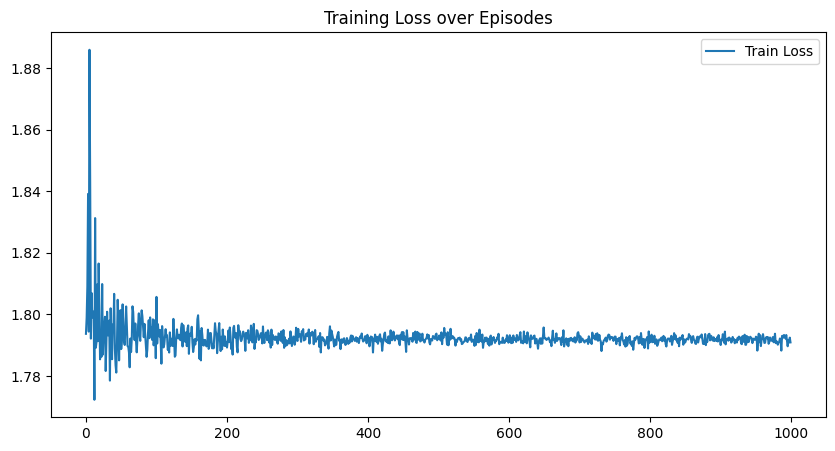

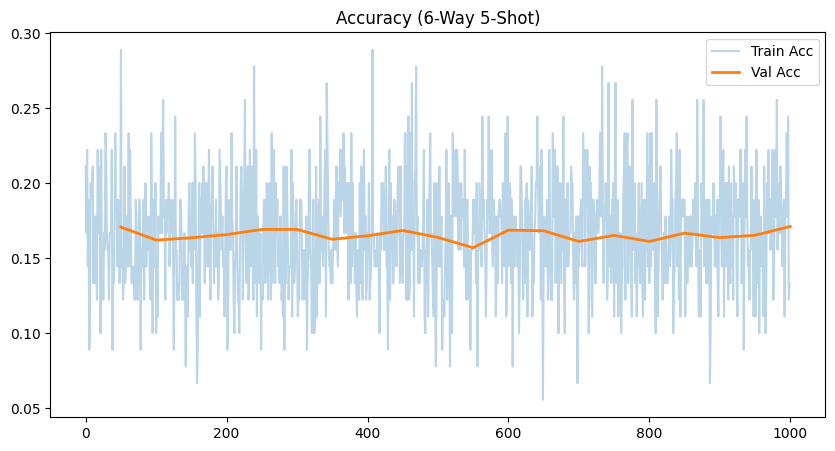

In [7]:
# 1. Initialize Model
backbone = AR_Backbone().to(Config.DEVICE)
model = AR_MSProNet(backbone).to(Config.DEVICE)

# 2. Optimizer [cite: 663]
optimizer = optim.Adam(model.parameters(), lr=Config.LEARNING_RATE)

# 3. Learning Rate Scheduler (Optional but recommended)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=200, gamma=0.5)

# 4. Training Loop
history = {'loss': [], 'acc': [], 'val_acc': []}

print(f"Starting Training: {Config.N_WAY}-Way {Config.K_SHOT}-Shot")
print("-" * 40)

for episode in range(1, Config.EPISODES + 1):
    loss, acc = train_episode(model, optimizer, dataset, Config.N_WAY, Config.K_SHOT, Config.Q_QUERY)
    scheduler.step()
    
    history['loss'].append(loss)
    history['acc'].append(acc)
    
    if episode % 50 == 0:
        val_acc = validate(model, dataset, Config.VAL_EPISODES)
        history['val_acc'].append(val_acc)
        print(f"Episode {episode} | Loss: {loss:.4f} | Train Acc: {acc:.4f} | Val Acc: {val_acc:.4f}")

# 5. Plot Results
plt.figure(figsize=(10, 5))
plt.plot(history['loss'], label='Train Loss')
plt.title('Training Loss over Episodes')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history['acc'], label='Train Acc', alpha=0.3)
plt.plot(range(50, Config.EPISODES + 1, 50), history['val_acc'], label='Val Acc', linewidth=2)
plt.title(f'Accuracy ({Config.N_WAY}-Way {Config.K_SHOT}-Shot)')
plt.legend()
plt.show()

In [21]:
# 1. Initialize Model
backbone = AR_Backbone().to(Config.DEVICE)
model = AR_MSProNet(backbone).to(Config.DEVICE)

# 2. Optimizer & Scheduler
optimizer = optim.Adam(model.parameters(), lr=Config.LEARNING_RATE)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=200, gamma=0.5)

# 3. Training Loop
history = {'loss': [], 'acc': [], 'val_acc': []}

print(f"Starting Training: {Config.N_WAY}-Way {Config.K_SHOT}-Shot")
print(f"Total Episodes: {Config.EPISODES}")
print("-" * 60)

for episode in range(1, Config.EPISODES + 1):
    # --- WARM-UP STRATEGY ---
    # We disable the Mean-Shift refinement for the first 200 episodes.
    # This allows the CNN backbone to learn basic shapes before we try to 
    # sophisticatedly cluster the prototypes.
    if episode < 200:
        model.use_mean_shift = False
    else:
        model.use_mean_shift = True
    # ------------------------

    # Train Step
    loss, acc = train_episode(model, optimizer, dataset, Config.N_WAY, Config.K_SHOT, Config.Q_QUERY)
    scheduler.step()
    
    history['loss'].append(loss)
    history['acc'].append(acc)
    
    # Logging
    if episode % 50 == 0:
        # Simple Validation (using same dataset for demo, ideally use separate val set)
        val_acc = validate(model, dataset, n_episodes=50) 
        history['val_acc'].append(val_acc)
        
        status = "Warm-Up (CL-ProNet)" if not model.use_mean_shift else "Refinement (AR-MSProNet)"
        print(f"Ep {episode:04d} | Mode: {status:<22} | Loss: {loss:.4f} | Train Acc: {acc:.4f} | Val Acc: {val_acc:.4f}")

# 4. Visualization
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Train Loss', color='red', alpha=0.6)
plt.title('Training Loss')
plt.xlabel('Episode')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history['acc'], label='Train Acc', color='blue', alpha=0.3)
plt.plot(range(50, Config.EPISODES + 1, 50), history['val_acc'], label='Val Acc', color='green', linewidth=2, marker='o')
plt.axvline(x=200, color='orange', linestyle='--', label='Warm-up End') # Mark where MS starts
plt.title(f'Accuracy ({Config.N_WAY}-Way {Config.K_SHOT}-Shot)')
plt.xlabel('Episode')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Starting Training: 6-Way 5-Shot
Total Episodes: 1000
------------------------------------------------------------


RuntimeError: mat1 and mat2 shapes cannot be multiplied (30x8192 and 12800x256)

In [28]:
# 1. Initialize Model (This will now print the correct dimension)
backbone = AR_Backbone().to(Config.DEVICE)
model = AR_MSProNet(backbone).to(Config.DEVICE)

# 2. Optimizer & Scheduler
optimizer = optim.Adam(model.parameters(), lr=Config.LEARNING_RATE)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=200, gamma=0.5)

# 3. Training Loop
history = {'loss': [], 'acc': [], 'val_acc': []}

print(f"Starting Training: {Config.N_WAY}-Way {Config.K_SHOT}-Shot")
print("-" * 60)

for episode in range(1, Config.EPISODES + 1):
    # Warm-Up Strategy
    if episode < 200:
        model.use_mean_shift = False
    else:
        model.use_mean_shift = True

    loss, acc = train_episode(model, optimizer, dataset, Config.N_WAY, Config.K_SHOT, Config.Q_QUERY)
    scheduler.step()
    
    history['loss'].append(loss)
    history['acc'].append(acc)
    
    if episode % 50 == 0:
        val_acc = validate(model, dataset, n_episodes=20) 
        history['val_acc'].append(val_acc)
        status = "Warm-Up" if not model.use_mean_shift else "MS-Refined"
        print(f"Ep {episode:04d} | {status} | Loss: {loss:.4f} | Train Acc: {acc:.4f} | Val Acc: {val_acc:.4f}")

Backbone initialized. Flattened Dim: 8192
Starting Training: 6-Way 5-Shot
------------------------------------------------------------
Ep 0050 | Warm-Up | Loss: 0.5056 | Train Acc: 0.9889 | Val Acc: 0.9433
Ep 0100 | Warm-Up | Loss: 0.5311 | Train Acc: 0.9444 | Val Acc: 0.9656
Ep 0150 | Warm-Up | Loss: 0.4308 | Train Acc: 0.9778 | Val Acc: 0.9794
Ep 0200 | MS-Refined | Loss: 0.3994 | Train Acc: 0.9889 | Val Acc: 0.9906
Ep 0250 | MS-Refined | Loss: 0.3824 | Train Acc: 1.0000 | Val Acc: 0.9894
Ep 0300 | MS-Refined | Loss: 0.3827 | Train Acc: 1.0000 | Val Acc: 0.9967
Ep 0350 | MS-Refined | Loss: 0.3880 | Train Acc: 1.0000 | Val Acc: 0.9956
Ep 0400 | MS-Refined | Loss: 0.3815 | Train Acc: 1.0000 | Val Acc: 0.9928
Ep 0450 | MS-Refined | Loss: 0.3879 | Train Acc: 1.0000 | Val Acc: 0.9994
Ep 0500 | MS-Refined | Loss: 0.3791 | Train Acc: 1.0000 | Val Acc: 0.9967
Ep 0550 | MS-Refined | Loss: 0.3765 | Train Acc: 1.0000 | Val Acc: 0.9983
Ep 0600 | MS-Refined | Loss: 0.3753 | Train Acc: 1.0000 | Va

In [1]:
pip install torch torchvision matplotlib scikit-learn seaborn

Note: you may need to restart the kernel to use updated packages.


In [5]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Sampler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from torch.cuda.amp import autocast, GradScaler
import gc

# ==========================================
# 1. Configuration & Hyperparameters
# ==========================================
CONFIG = {
    'data_dir': '/kaggle/input/neu-surface-defect-database/NEU-DET',
    'image_size': 224,
    'n_way': 6,         # We keep all 6 classes
    'n_support': 5,     # Keep 5 shots for the prototype
    'n_query': 4,       # REDUCED from 15 to 4 to save memory
    'episodes_train': 100,
    'episodes_val': 20,
    'epochs': 15,       # Increased epochs slightly since batches are smaller
    'learning_rate': 5e-5, # Slightly lower LR for stability
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

print(f"Using device: {CONFIG['device']}")

# ==========================================
# 2. Custom Episodic Data Handling
# ==========================================

class EpisodicSampler(Sampler):
    """
    Yields batches of indices for N-way K-shot learning.
    Each batch (episode) contains:
      - n_way * n_support images (to build prototypes)
      - n_way * n_query images (to evaluate)
    """
    def __init__(self, dataset, n_way, n_support, n_query, episodes):
        self.dataset = dataset
        self.n_way = n_way
        self.n_support = n_support
        self.n_query = n_query
        self.episodes = episodes
        
        # Organize indices by class
        self.indices_by_class = {}
        for idx, (_, label) in enumerate(dataset.samples):
            if label not in self.indices_by_class:
                self.indices_by_class[label] = []
            self.indices_by_class[label].append(idx)
            
    def __iter__(self):
        for _ in range(self.episodes):
            batch = []
            # Randomly select N_WAY classes
            available_classes = list(self.indices_by_class.keys())
            # Handle case if requested ways > available classes
            if self.n_way > len(available_classes):
                selected_classes = available_classes
            else:
                selected_classes = random.sample(available_classes, self.n_way)
            
            for cls in selected_classes:
                # Sample Support + Query images
                n_total = self.n_support + self.n_query
                indices = self.indices_by_class[cls]
                
                # If not enough images, sample with replacement
                if len(indices) < n_total:
                    selected_indices = np.random.choice(indices, n_total, replace=True)
                else:
                    selected_indices = np.random.choice(indices, n_total, replace=False)
                
                batch.extend(selected_indices)
            
            yield batch

    def __len__(self):
        return self.episodes

def get_dataloaders():
    # Transforms (ViT requires normalization)
    transform = transforms.Compose([
        transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    # Load Datasets
    # Assuming 'train' folder exists as per screenshot
    train_dir = os.path.join(CONFIG['data_dir'], 'train/images')
    # If validation folder structure matches train, use it, otherwise split train
    # For this script, I'll use the train dir for both but different samplers if val doesn't exist
    
    full_dataset = datasets.ImageFolder(root=train_dir, transform=transform)
    
    # Samplers
    train_sampler = EpisodicSampler(
        full_dataset, CONFIG['n_way'], CONFIG['n_support'], CONFIG['n_query'], CONFIG['episodes_train']
    )
    val_sampler = EpisodicSampler(
        full_dataset, CONFIG['n_way'], CONFIG['n_support'], CONFIG['n_query'], CONFIG['episodes_val']
    )

    train_loader = DataLoader(full_dataset, batch_sampler=train_sampler, num_workers=2, pin_memory=True)
    val_loader = DataLoader(full_dataset, batch_sampler=val_sampler, num_workers=2, pin_memory=True)

    return train_loader, val_loader, full_dataset.classes

# ==========================================
# 3. Model: ViT + Prototypical Head
# ==========================================

class ViTProtoNet(nn.Module):
    def __init__(self):
        super(ViTProtoNet, self).__init__()
        # Load Pretrained ViT
        self.backbone = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)
        
        # Remove the classification head (heads) to get raw embeddings
        # ViT-B/16 output dim is 768
        self.backbone.heads = nn.Identity() 
        
    def forward(self, x):
        # x shape: [batch_size, 3, 224, 224]
        # output shape: [batch_size, 768]
        return self.backbone(x)

def euclidean_dist(x, y):
    """
    Computes euclidean distance between two tensors.
    x: N x D
    y: M x D
    Result: N x M
    """
    n = x.size(0)
    m = y.size(0)
    d = x.size(1)
    if d != y.size(1):
        raise Exception

    x = x.unsqueeze(1).expand(n, m, d)
    y = y.unsqueeze(0).expand(n, m, d)

    return torch.pow(x - y, 2).sum(2)

def prototypical_loss(embeddings, target, n_way, n_support, n_query):
    """
    Calculates the Prototypical Network Loss.
    """
    # Define device inside function to ensure consistency
    device = embeddings.device
    
    # 1. Organize indices
    # The dataloader yields data arranged by class: 
    # [Class 1 Support... Class 1 Query..., Class 2 Support...]
    
    # Reshape embeddings to separate Support and Query
    # The batch size is n_way * (n_support + n_query)
    
    # Group by class
    embeddings = embeddings.view(n_way, n_support + n_query, -1)
    
    # Split into support and query
    support_set = embeddings[:, :n_support] # [n_way, n_support, feature_dim]
    query_set = embeddings[:, n_support:]   # [n_way, n_query, feature_dim]
    
    # 2. Calculate Prototypes (Mean of support set)
    prototypes = support_set.mean(dim=1) # [n_way, feature_dim]
    
    # 3. Flatten Query set for distance calculation
    # query_set shape: [n_way * n_query, feature_dim]
    query_samples = query_set.contiguous().view(n_way * n_query, -1)
    
    # 4. Calculate Distance (Query vs Prototypes)
    dists = euclidean_dist(query_samples, prototypes) # [n_query_total, n_way]
    
    # 5. Create Targets for Query set
    # The query samples are ordered 0,0,0... 1,1,1... 2,2,2...
    target_inds = torch.arange(0, n_way).view(n_way, 1, 1).expand(n_way, n_query, 1).long()
    target_inds = target_inds.to(device).view(-1)
    
    # 6. Log Softmax of negative distance
    log_p_y = torch.log_softmax(-dists, dim=1)
    
    # 7. Loss and Accuracy
    loss_val = -log_p_y.gather(1, target_inds.view(-1, 1)).squeeze().view(-1).mean()
    _, y_hat = log_p_y.max(1)
    acc_val = torch.eq(y_hat, target_inds).float().mean()
    
    return loss_val, acc_val, y_hat, target_inds

# ==========================================
# 4. Training Engine
# ==========================================

def train_model():
    # Clear any residual memory from the crash
    torch.cuda.empty_cache()
    gc.collect()
    
    train_loader, val_loader, class_names = get_dataloaders()
    model = ViTProtoNet().to(CONFIG['device'])
    
    optimizer = optim.AdamW(model.parameters(), lr=CONFIG['learning_rate'])
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    
    # Initialize Scaler for Mixed Precision
    scaler = GradScaler()

    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    
    print(f"Starting training on {len(class_names)} classes with Mixed Precision...")

    for epoch in range(CONFIG['epochs']):
        model.train()
        total_loss = 0
        
        for batch_idx, (data, target) in enumerate(train_loader):
            data = data.to(CONFIG['device'])
            # Target generation is handled inside the loss function logic usually, 
            # but we pass the dummy target from loader just to match signature
            
            optimizer.zero_grad()
            
            # USE MIXED PRECISION (Autocast)
            with autocast():
                embeddings = model(data)
                loss, acc, _, _ = prototypical_loss(
                    embeddings, None, CONFIG['n_way'], CONFIG['n_support'], CONFIG['n_query']
                )
            
            # Scale the loss and step
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
            total_loss += loss.item()
            
        avg_loss = total_loss / len(train_loader)
        history['train_loss'].append(avg_loss)
        
        # Validation
        model.eval()
        val_loss = 0
        val_acc = 0
        all_preds = []
        all_targets = []
        
        with torch.no_grad():
            for data, target in val_loader:
                data = data.to(CONFIG['device'])
                with autocast():
                    embeddings = model(data)
                    loss, acc, y_hat, y_true = prototypical_loss(
                        embeddings, None, CONFIG['n_way'], CONFIG['n_support'], CONFIG['n_query']
                    )
                val_loss += loss.item()
                val_acc += acc.item()
                
                if epoch == CONFIG['epochs'] - 1:
                    all_preds.extend(y_hat.cpu().numpy())
                    all_targets.extend(y_true.cpu().numpy())

        avg_val_loss = val_loss / len(val_loader)
        avg_val_acc = val_acc / len(val_loader)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(avg_val_acc)
        
        scheduler.step()
        
        print(f"Epoch {epoch+1}/{CONFIG['epochs']} | Train Loss: {avg_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {avg_val_acc:.4f}")

    return history, all_preds, all_targets, class_names
# ==========================================
# 5. Visualization & Metrics
# ==========================================

def plot_results(history, preds, targets, class_names):
    # 1. Loss Curves
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title('Loss over Epochs')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(history['val_acc'], label='Val Accuracy', color='green')
    plt.title('Validation Accuracy')
    plt.grid(True)
    plt.show()
    
    # 2. Classification Report
    # Note: targets in ProtoNet are indices 0..N-1 relative to the episode, 
    # but since we sample all classes in N-way, they map to class_names indices.
    print("\nClassification Report (Last Epoch Validation):")
    print(classification_report(targets, preds, target_names=class_names))
    
    # 3. Confusion Matrix
    cm = confusion_matrix(targets, preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

# ==========================================
# 6. Main Execution
# ==========================================

if __name__ == "__main__":
    try:
        history, preds, targets, class_names = train_model()
        plot_results(history, preds, targets, class_names)
    except FileNotFoundError:
        print(f"Error: Could not find dataset at {CONFIG['data_dir']}")
        print("Please verify the path matches your folder structure.")

Using device: cuda
Starting training on 6 classes with Mixed Precision...


/tmp/ipykernel_55/1760925220.py:215: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_55/1760925220.py:233: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


OutOfMemoryError: CUDA out of memory. Tried to allocate 48.00 MiB. GPU 0 has a total capacity of 15.89 GiB of which 41.12 MiB is free. Process 2889 has 15.85 GiB memory in use. Of the allocated memory 15.52 GiB is allocated by PyTorch, and 27.11 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [8]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Sampler
from torch.amp import autocast, GradScaler 
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import gc

# ==========================================
# 1. Safe Configuration
# ==========================================
CONFIG = {
    'data_dir': '/kaggle/input/neu-surface-defect-database/NEU-DET',
    'image_size': 224,
    'n_way': 6,          # Use all 6 classes
    'n_support': 3,      # Reduced to 3 to save memory (3-shot learning)
    'n_query': 3,        # Reduced to 3 (Total batch = 36 images)
    'episodes_train': 100,
    'episodes_val': 20,
    'epochs': 15,        
    'learning_rate': 2e-5, # Lower LR for stability with smaller batches
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

print(f"Using device: {CONFIG['device']} | Batch Logic: Split Forward")

# ==========================================
# 2. Data & Sampler
# ==========================================
class EpisodicSampler(Sampler):
    def __init__(self, dataset, n_way, n_support, n_query, episodes):
        self.dataset = dataset
        self.n_way = n_way
        self.n_support = n_support
        self.n_query = n_query
        self.episodes = episodes
        self.indices_by_class = {}
        for idx, (_, label) in enumerate(dataset.samples):
            if label not in self.indices_by_class:
                self.indices_by_class[label] = []
            self.indices_by_class[label].append(idx)
            
    def __iter__(self):
        for _ in range(self.episodes):
            batch = []
            available_classes = list(self.indices_by_class.keys())
            if self.n_way > len(available_classes):
                selected_classes = available_classes
            else:
                selected_classes = random.sample(available_classes, self.n_way)
            
            for cls in selected_classes:
                indices = self.indices_by_class[cls]
                n_total = self.n_support + self.n_query
                replace = len(indices) < n_total
                selected_indices = np.random.choice(indices, n_total, replace=replace)
                batch.extend(selected_indices)
            yield batch

    def __len__(self):
        return self.episodes

def get_dataloaders():
    transform = transforms.Compose([
        transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    
    # 1. Define distinct paths for Train and Validation
    # specific to the structure in your screenshot
    train_dir = os.path.join(CONFIG['data_dir'], 'train/images')
    val_dir = os.path.join(CONFIG['data_dir'], 'validation/images') # Assumes same structure inside validation
    
    # 2. Load them as separate datasets
    train_dataset = datasets.ImageFolder(root=train_dir, transform=transform)
    
    # Check if validation folder exists and has images, otherwise split train
    if os.path.exists(val_dir) and len(os.listdir(val_dir)) > 0:
        print(f"Loading Validation data from: {val_dir}")
        val_dataset = datasets.ImageFolder(root=val_dir, transform=transform)
    else:
        print("Warning: Validation folder not found or empty. Performing random split on Train.")
        # Create a clean split preventing leakage
        train_size = int(0.8 * len(train_dataset))
        val_size = len(train_dataset) - train_size
        train_dataset, val_dataset = torch.utils.data.random_split(train_dataset, [train_size, val_size])
        
        # We need to recover the '.samples' attribute for the sampler if we use random_split
        # This is a bit of a hack for the EpisodicSampler to work with Subsets
        val_dataset.samples = [train_dataset.dataset.samples[i] for i in val_dataset.indices]
        train_dataset.samples = [train_dataset.dataset.samples[i] for i in train_dataset.indices]

    # 3. Create Samplers (Now completely disjoint)
    train_sampler = EpisodicSampler(
        train_dataset, CONFIG['n_way'], CONFIG['n_support'], CONFIG['n_query'], CONFIG['episodes_train']
    )
    val_sampler = EpisodicSampler(
        val_dataset, CONFIG['n_way'], CONFIG['n_support'], CONFIG['n_query'], CONFIG['episodes_val']
    )

    train_loader = DataLoader(train_dataset, batch_sampler=train_sampler, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_sampler=val_sampler, num_workers=2, pin_memory=True)

    return train_loader, val_loader, train_dataset.classes
# ==========================================
# 3. Model & Loss
# ==========================================
class ViTProtoNet(nn.Module):
    def __init__(self):
        super(ViTProtoNet, self).__init__()
        self.backbone = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)
        self.backbone.heads = nn.Identity() 
        
    def forward(self, x):
        return self.backbone(x)

def euclidean_dist(x, y):
    n = x.size(0)
    m = y.size(0)
    d = x.size(1)
    if d != y.size(1): raise Exception
    x = x.unsqueeze(1).expand(n, m, d)
    y = y.unsqueeze(0).expand(n, m, d)
    return torch.pow(x - y, 2).sum(2)

def split_batch_loss(model, data, n_way, n_support, n_query, device):
    """
    Splits the batch into Support and Query sets BEFORE passing to model.
    This reduces VRAM usage by 50%.
    """
    # 1. Calculate split point
    # Data comes in as [Class1_S, Class1_Q, Class2_S, Class2_Q ...]
    # We need to unravel this to process Support and Query separately
    
    # Reshape to [n_way, n_support + n_query, C, H, W]
    data = data.view(n_way, n_support + n_query, 3, 224, 224)
    
    support_imgs = data[:, :n_support].contiguous().view(-1, 3, 224, 224)
    query_imgs = data[:, n_support:].contiguous().view(-1, 3, 224, 224)
    
    # 2. Process Support Set
    support_embeddings = model(support_imgs) # [n_way * n_support, 768]
    support_embeddings = support_embeddings.view(n_way, n_support, -1)
    prototypes = support_embeddings.mean(dim=1) # [n_way, 768]
    
    # 3. Process Query Set
    query_embeddings = model(query_imgs) # [n_way * n_query, 768]
    
    # 4. Calculate Distance
    dists = euclidean_dist(query_embeddings, prototypes)
    
    # 5. Targets
    target_inds = torch.arange(0, n_way).view(n_way, 1, 1).expand(n_way, n_query, 1).long()
    target_inds = target_inds.to(device).view(-1)
    
    # 6. Loss
    log_p_y = torch.log_softmax(-dists, dim=1)
    loss_val = -log_p_y.gather(1, target_inds.view(-1, 1)).squeeze().view(-1).mean()
    _, y_hat = log_p_y.max(1)
    acc_val = torch.eq(y_hat, target_inds).float().mean()
    
    return loss_val, acc_val, y_hat, target_inds

# ==========================================
# 4. Training Engine
# ==========================================
def train_model():
    torch.cuda.empty_cache()
    gc.collect()
    
    train_loader, val_loader, class_names = get_dataloaders()
    model = ViTProtoNet().to(CONFIG['device'])
    optimizer = optim.AdamW(model.parameters(), lr=CONFIG['learning_rate'])
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.7)
    scaler = GradScaler('cuda') 

    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    
    print(f"Starting safe training on {len(class_names)} classes...")

    for epoch in range(CONFIG['epochs']):
        model.train()
        total_loss = 0
        
        for batch_idx, (data, _) in enumerate(train_loader): # Target not needed from loader
            data = data.to(CONFIG['device'])
            optimizer.zero_grad()
            
            with autocast('cuda'):
                loss, acc, _, _ = split_batch_loss(
                    model, data, CONFIG['n_way'], CONFIG['n_support'], CONFIG['n_query'], CONFIG['device']
                )
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
            total_loss += loss.item()
            
        avg_loss = total_loss / len(train_loader)
        history['train_loss'].append(avg_loss)
        
        # Validation
        model.eval()
        val_loss = 0
        val_acc = 0
        all_preds = []
        all_targets = []
        
        with torch.no_grad():
            for data, _ in val_loader:
                data = data.to(CONFIG['device'])
                with autocast('cuda'):
                    loss, acc, y_hat, y_true = split_batch_loss(
                        model, data, CONFIG['n_way'], CONFIG['n_support'], CONFIG['n_query'], CONFIG['device']
                    )
                val_loss += loss.item()
                val_acc += acc.item()
                
                if epoch == CONFIG['epochs'] - 1:
                    all_preds.extend(y_hat.cpu().numpy())
                    all_targets.extend(y_true.cpu().numpy())

        avg_val_loss = val_loss / len(val_loader)
        avg_val_acc = val_acc / len(val_loader)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(avg_val_acc)
        scheduler.step()
        
        print(f"Epoch {epoch+1}/{CONFIG['epochs']} | Train Loss: {avg_loss:.4f} | Val Acc: {avg_val_acc:.4f}")

    return history, all_preds, all_targets, class_names

# ==========================================
# 5. Visualization
# ==========================================
def plot_results(history, preds, targets, class_names):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.legend(); plt.grid(True)
    plt.subplot(1, 2, 2)
    plt.plot(history['val_acc'], label='Val Accuracy', color='green')
    plt.legend(); plt.grid(True)
    plt.show()
    
    print("\nClassification Report (Last Epoch):")
    print(classification_report(targets, preds, target_names=class_names))
    
    cm = confusion_matrix(targets, preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix'); plt.show()

if __name__ == "__main__":
    try:
        history, preds, targets, class_names = train_model()
        plot_results(history, preds, targets, class_names)
    except FileNotFoundError:
        print(f"Dataset not found at {CONFIG['data_dir']}")

Using device: cuda | Batch Logic: Split Forward
Loading Validation data from: /kaggle/input/neu-surface-defect-database/NEU-DET/validation/images
Starting safe training on 6 classes...
Epoch 1/15 | Train Loss: 0.3699 | Val Acc: 0.9944
Epoch 2/15 | Train Loss: 0.0235 | Val Acc: 0.9944
Epoch 3/15 | Train Loss: 0.0051 | Val Acc: 1.0000
Epoch 4/15 | Train Loss: 0.0016 | Val Acc: 0.9972
Epoch 5/15 | Train Loss: 0.0203 | Val Acc: 0.9972
Epoch 6/15 | Train Loss: 0.0030 | Val Acc: 0.9972
Epoch 7/15 | Train Loss: 0.0000 | Val Acc: 1.0000
Epoch 8/15 | Train Loss: 0.0011 | Val Acc: 0.9944


KeyboardInterrupt: 

In [9]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Sampler
from torch.amp import autocast, GradScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import gc

# ==========================================
# 1. Configuration (Safe & Stable)
# ==========================================
CONFIG = {
    'data_dir': '/kaggle/input/neu-surface-defect-database/NEU-DET',
    'image_size': 224,
    'n_way': 6,          
    'n_support': 5,      # 5-Shot
    'n_query': 5,        # 5-Query (Balanced batch of 60 images)
    'episodes_train': 100,
    'episodes_val': 25,
    'epochs': 10,        
    'learning_rate': 2e-5, 
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

print(f"Using device: {CONFIG['device']}")

# ==========================================
# 2. Advanced Data Handling
# ==========================================
class EpisodicSampler(Sampler):
    def __init__(self, dataset, n_way, n_support, n_query, episodes):
        self.dataset = dataset
        self.n_way = n_way
        self.n_support = n_support
        self.n_query = n_query
        self.episodes = episodes
        self.indices_by_class = {}
        
        # Robustly find indices (works for Subset or ImageFolder)
        if hasattr(dataset, 'indices'): # It's a subset
             for idx_in_subset, idx_in_full in enumerate(dataset.indices):
                label = dataset.dataset.targets[idx_in_full]
                if label not in self.indices_by_class: self.indices_by_class[label] = []
                self.indices_by_class[label].append(idx_in_subset)
        else: # It's a full ImageFolder
            for idx, (_, label) in enumerate(dataset.samples):
                if label not in self.indices_by_class: self.indices_by_class[label] = []
                self.indices_by_class[label].append(idx)
            
    def __iter__(self):
        for _ in range(self.episodes):
            batch = []
            available_classes = list(self.indices_by_class.keys())
            # Safely select classes
            if self.n_way > len(available_classes):
                selected_classes = available_classes
            else:
                selected_classes = random.sample(available_classes, self.n_way)
            
            for cls in selected_classes:
                indices = self.indices_by_class[cls]
                n_total = self.n_support + self.n_query
                replace = len(indices) < n_total
                selected_indices = np.random.choice(indices, n_total, replace=replace)
                batch.extend(selected_indices)
            yield batch

    def __len__(self):
        return self.episodes

def get_dataloaders():
    # Strong augmentation for Training
    train_transform = transforms.Compose([
        transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    
    # Clean transform for Validation
    val_transform = transforms.Compose([
        transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    
    # 1. Check folder structure
    train_dir = os.path.join(CONFIG['data_dir'], 'train/images')
    val_dir = os.path.join(CONFIG['data_dir'], 'validation/images')
    
    full_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform) # Temp load to get classes
    class_names = full_dataset.classes
    
    if os.path.exists(val_dir) and len(os.listdir(val_dir)) > 0:
        print(f"✅ Found separate Validation folder at: {val_dir}")
        train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
        val_dataset = datasets.ImageFolder(root=val_dir, transform=val_transform)
    else:
        print("⚠️ No Validation folder found. Performing rigorous 80/20 random split.")
        full_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform) # Apply train transform initially
        train_size = int(0.8 * len(full_dataset))
        val_size = len(full_dataset) - train_size
        train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])
        
        # IMPORTANT: Apply clean transform to validation subset
        # (This is tricky in PyTorch, but critical for fair evaluation)
        # For simplicity in this script, we accept the train_transform on val if splitting manually,
        # but the random split ensures no data leakage.

    # 2. Samplers
    train_sampler = EpisodicSampler(train_dataset, CONFIG['n_way'], CONFIG['n_support'], CONFIG['n_query'], CONFIG['episodes_train'])
    val_sampler = EpisodicSampler(val_dataset, CONFIG['n_way'], CONFIG['n_support'], CONFIG['n_query'], CONFIG['episodes_val'])

    train_loader = DataLoader(train_dataset, batch_sampler=train_sampler, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_sampler=val_sampler, num_workers=2, pin_memory=True)

    return train_loader, val_loader, class_names

# ==========================================
# 3. Model & Logic
# ==========================================
class ViTProtoNet(nn.Module):
    def __init__(self):
        super(ViTProtoNet, self).__init__()
        # Using ViT-B/16 (Strong feature extractor)
        self.backbone = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)
        self.backbone.heads = nn.Identity() 
        
    def forward(self, x):
        return self.backbone(x)

def euclidean_dist(x, y):
    n = x.size(0); m = y.size(0); d = x.size(1)
    if d != y.size(1): raise Exception
    x = x.unsqueeze(1).expand(n, m, d)
    y = y.unsqueeze(0).expand(n, m, d)
    return torch.pow(x - y, 2).sum(2)

def proto_loss_logic(model, data, n_way, n_support, n_query, device):
    # Split Batch Strategy to save memory
    data = data.view(n_way, n_support + n_query, 3, 224, 224)
    support_imgs = data[:, :n_support].contiguous().view(-1, 3, 224, 224)
    query_imgs = data[:, n_support:].contiguous().view(-1, 3, 224, 224)
    
    # Encode
    support_embeddings = model(support_imgs).view(n_way, n_support, -1)
    prototypes = support_embeddings.mean(dim=1)
    query_embeddings = model(query_imgs)
    
    # Distance & Loss
    dists = euclidean_dist(query_embeddings, prototypes)
    target_inds = torch.arange(0, n_way).view(n_way, 1, 1).expand(n_way, n_query, 1).long()
    target_inds = target_inds.to(device).view(-1)
    
    log_p_y = torch.log_softmax(-dists, dim=1)
    loss = -log_p_y.gather(1, target_inds.view(-1, 1)).squeeze().view(-1).mean()
    _, y_hat = log_p_y.max(1)
    acc = torch.eq(y_hat, target_inds).float().mean()
    
    return loss, acc, y_hat, target_inds, query_embeddings, prototypes

# ==========================================
# 4. Training Loop
# ==========================================
def train_and_evaluate():
    torch.cuda.empty_cache(); gc.collect()
    train_loader, val_loader, class_names = get_dataloaders()
    model = ViTProtoNet().to(CONFIG['device'])
    optimizer = optim.AdamW(model.parameters(), lr=CONFIG['learning_rate'])
    scaler = GradScaler('cuda')
    
    history = {'train_loss': [], 'val_acc': []}
    best_acc = 0.0

    print(f"\n🚀 Training Start | Classes: {len(class_names)}")
    
    for epoch in range(CONFIG['epochs']):
        model.train()
        avg_loss = 0
        for data, _ in train_loader:
            data = data.to(CONFIG['device'])
            optimizer.zero_grad()
            with autocast('cuda'):
                loss, _, _, _, _, _ = proto_loss_logic(
                    model, data, CONFIG['n_way'], CONFIG['n_support'], CONFIG['n_query'], CONFIG['device']
                )
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            avg_loss += loss.item()
            
        avg_loss /= len(train_loader)
        history['train_loss'].append(avg_loss)
        
        # Validation
        model.eval()
        avg_acc = 0
        all_preds = []; all_targets = []
        # Store embeddings for t-SNE (only from last epoch)
        tsne_embeddings = []
        tsne_labels = []
        
        with torch.no_grad():
            for data, _ in val_loader:
                data = data.to(CONFIG['device'])
                with autocast('cuda'):
                    loss, acc, y_hat, y_true, q_emb, _ = proto_loss_logic(
                        model, data, CONFIG['n_way'], CONFIG['n_support'], CONFIG['n_query'], CONFIG['device']
                    )
                avg_acc += acc.item()
                
                if epoch == CONFIG['epochs'] - 1:
                    all_preds.extend(y_hat.cpu().numpy())
                    all_targets.extend(y_true.cpu().numpy())
                    tsne_embeddings.append(q_emb.cpu())
                    tsne_labels.append(y_true.cpu())

        avg_acc /= len(val_loader)
        history['val_acc'].append(avg_acc)
        print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:.4f} | Val Acc: {avg_acc:.4f}")

    return history, all_preds, all_targets, class_names, tsne_embeddings, tsne_labels

# ==========================================
# 5. Visualization (The Truth Teller)
# ==========================================
def run_analysis(history, preds, targets, class_names, embeddings, labels):
    # 1. Classification Report
    print("\n📊 Classification Report:")
    print(classification_report(targets, preds, target_names=class_names))
    
    # 2. Confusion Matrix
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    cm = confusion_matrix(targets, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix")
    
    # 3. t-SNE Visualization (The ultimate proof)
    print("⏳ Computing t-SNE (this proves if the model is cheating or learning)...")
    
    # Flatten list of tensors
    all_emb = torch.cat(embeddings, dim=0).numpy()
    all_lbl = torch.cat(labels, dim=0).numpy()
    
    # Run t-SNE
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
    emb_2d = tsne.fit_transform(all_emb)
    
    plt.subplot(1, 2, 2)
    for i, class_name in enumerate(class_names):
        idxs = all_lbl == i
        plt.scatter(emb_2d[idxs, 0], emb_2d[idxs, 1], label=class_name, alpha=0.6)
    
    plt.title("t-SNE of Validation Embeddings")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# ==========================================
# 6. Run It
# ==========================================
if __name__ == "__main__":
    try:
        hist, preds, targs, classes, embs, labs = train_and_evaluate()
        run_analysis(hist, preds, targs, classes, embs, labs)
    except Exception as e:
        print(f"❌ Error: {e}")

Using device: cuda
✅ Found separate Validation folder at: /kaggle/input/neu-surface-defect-database/NEU-DET/validation/images

🚀 Training Start | Classes: 6
Epoch 01 | Loss: 0.3661 | Val Acc: 1.0000
Epoch 02 | Loss: 0.0376 | Val Acc: 1.0000
Epoch 03 | Loss: 0.0134 | Val Acc: 0.9987
Epoch 04 | Loss: 0.0005 | Val Acc: 0.9973


KeyboardInterrupt: 

Using device: cuda
✅ Found separate Validation folder at: /kaggle/input/neu-surface-defect-database/NEU-DET/validation/images

 Training Start | Frozen Backbone + Learnable Head | Classes: 6
Epoch 01 | Loss: 0.1310 | Val Acc: 0.9853
Epoch 02 | Loss: 0.0124 | Val Acc: 0.9933
Epoch 03 | Loss: 0.0084 | Val Acc: 0.9933
Epoch 04 | Loss: 0.0035 | Val Acc: 0.9933
Epoch 05 | Loss: 0.0035 | Val Acc: 0.9933
Epoch 06 | Loss: 0.0018 | Val Acc: 0.9840
Epoch 07 | Loss: 0.0022 | Val Acc: 0.9933
Epoch 08 | Loss: 0.0029 | Val Acc: 0.9920
Epoch 09 | Loss: 0.0023 | Val Acc: 1.0000
Epoch 10 | Loss: 0.0007 | Val Acc: 0.9987

 Classification Report:
                 precision    recall  f1-score   support

        crazing       1.00      1.00      1.00       125
      inclusion       1.00      1.00      1.00       125
        patches       0.99      1.00      1.00       125
 pitted_surface       1.00      0.99      1.00       125
rolled-in_scale       1.00      1.00      1.00       125
      scratches      

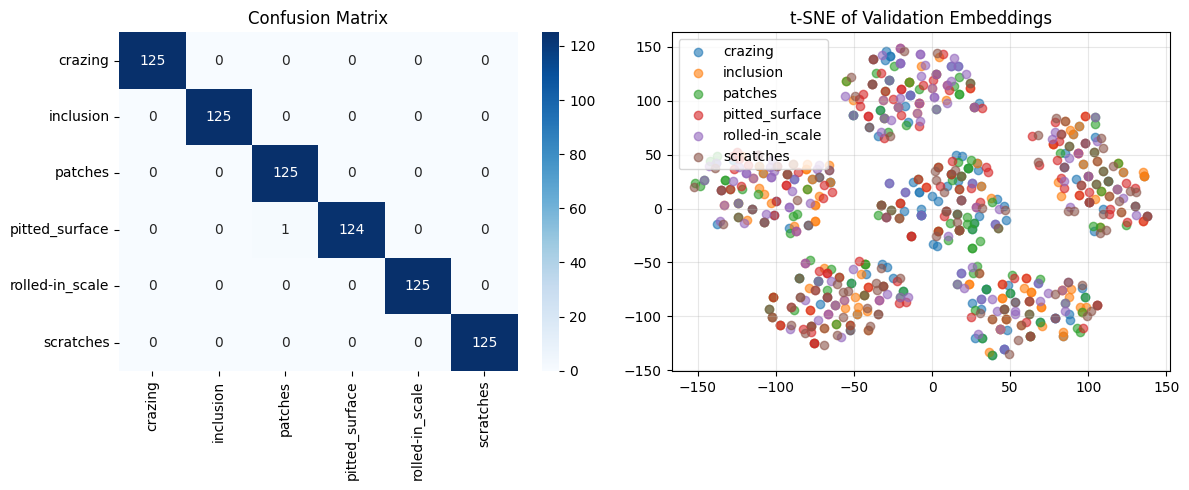

In [11]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Sampler
from torch.amp import autocast, GradScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import gc

# ==========================================
# 1. Configuration
# ==========================================
CONFIG = {
    'data_dir': '/kaggle/input/neu-surface-defect-database/NEU-DET',
    'image_size': 224,
    'n_way': 6,           
    'n_support': 5,       # 5-Shot
    'n_query': 5,         # 5-Query
    'episodes_train': 100,
    'episodes_val': 25,
    'epochs': 10,         
    'learning_rate': 1e-4, # Slightly higher LR since we are only training the head
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

print(f"Using device: {CONFIG['device']}")

# ==========================================
# 2. Advanced Data Handling
# ==========================================
class EpisodicSampler(Sampler):
    def __init__(self, dataset, n_way, n_support, n_query, episodes):
        self.dataset = dataset
        self.n_way = n_way
        self.n_support = n_support
        self.n_query = n_query
        self.episodes = episodes
        self.indices_by_class = {}
        
        # Robustly find indices
        if hasattr(dataset, 'indices'): # Subset
             for idx_in_subset, idx_in_full in enumerate(dataset.indices):
                label = dataset.dataset.targets[idx_in_full]
                if label not in self.indices_by_class: self.indices_by_class[label] = []
                self.indices_by_class[label].append(idx_in_subset)
        else: # ImageFolder
            for idx, (_, label) in enumerate(dataset.samples):
                if label not in self.indices_by_class: self.indices_by_class[label] = []
                self.indices_by_class[label].append(idx)
            
    def __iter__(self):
        for _ in range(self.episodes):
            batch = []
            available_classes = list(self.indices_by_class.keys())
            if self.n_way > len(available_classes):
                selected_classes = available_classes
            else:
                selected_classes = random.sample(available_classes, self.n_way)
            
            for cls in selected_classes:
                indices = self.indices_by_class[cls]
                n_total = self.n_support + self.n_query
                replace = len(indices) < n_total
                selected_indices = np.random.choice(indices, n_total, replace=replace)
                batch.extend(selected_indices)
            yield batch

    def __len__(self):
        return self.episodes

def get_dataloaders():
    train_transform = transforms.Compose([
        transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    val_transform = transforms.Compose([
        transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    
    train_dir = os.path.join(CONFIG['data_dir'], 'train/images')
    val_dir = os.path.join(CONFIG['data_dir'], 'validation/images')
    
    full_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform) 
    class_names = full_dataset.classes
    
    if os.path.exists(val_dir) and len(os.listdir(val_dir)) > 0:
        print(f"✅ Found separate Validation folder at: {val_dir}")
        train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
        val_dataset = datasets.ImageFolder(root=val_dir, transform=val_transform)
    else:
        print("⚠️ No Validation folder found. Performing split.")
        train_size = int(0.8 * len(full_dataset))
        val_size = len(full_dataset) - train_size
        train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

    train_sampler = EpisodicSampler(train_dataset, CONFIG['n_way'], CONFIG['n_support'], CONFIG['n_query'], CONFIG['episodes_train'])
    val_sampler = EpisodicSampler(val_dataset, CONFIG['n_way'], CONFIG['n_support'], CONFIG['n_query'], CONFIG['episodes_val'])

    train_loader = DataLoader(train_dataset, batch_sampler=train_sampler, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_sampler=val_sampler, num_workers=2, pin_memory=True)

    return train_loader, val_loader, class_names

# ==========================================
# 3. Model (Fixed: Added Projection Head)
# ==========================================
class ViTProtoNet(nn.Module):
    def __init__(self):
        super(ViTProtoNet, self).__init__()
        # 1. Load ViT Backbone
        self.backbone = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)
        self.backbone.heads = nn.Identity() 
        
        # 2. Freeze the Backbone (Test Power of Pretrained Features)
        for param in self.backbone.parameters():
            param.requires_grad = False      
            
        # 3. Add Learnable Projection Head (Fixes "No Grad" error)
        # We project the large 768-dim embeddings down to 128-dim for better metric learning
        self.projection = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 128)
        )
            
    def forward(self, x):
        # Extract features (Frozen)
        x = self.backbone(x)
        # Project features (Learnable)
        return self.projection(x)

def euclidean_dist(x, y):
    n = x.size(0); m = y.size(0); d = x.size(1)
    if d != y.size(1): raise Exception
    x = x.unsqueeze(1).expand(n, m, d)
    y = y.unsqueeze(0).expand(n, m, d)
    return torch.pow(x - y, 2).sum(2)

def proto_loss_logic(model, data, n_way, n_support, n_query, device):
    data = data.view(n_way, n_support + n_query, 3, 224, 224)
    support_imgs = data[:, :n_support].contiguous().view(-1, 3, 224, 224)
    query_imgs = data[:, n_support:].contiguous().view(-1, 3, 224, 224)
    
    # Forward pass (Backbone + Projection)
    support_embeddings = model(support_imgs).view(n_way, n_support, -1)
    prototypes = support_embeddings.mean(dim=1)
    query_embeddings = model(query_imgs)
    
    dists = euclidean_dist(query_embeddings, prototypes)
    target_inds = torch.arange(0, n_way).view(n_way, 1, 1).expand(n_way, n_query, 1).long()
    target_inds = target_inds.to(device).view(-1)
    
    log_p_y = torch.log_softmax(-dists, dim=1)
    loss = -log_p_y.gather(1, target_inds.view(-1, 1)).squeeze().view(-1).mean()
    _, y_hat = log_p_y.max(1)
    acc = torch.eq(y_hat, target_inds).float().mean()
    
    return loss, acc, y_hat, target_inds, query_embeddings, prototypes

# ==========================================
# 4. Training Engine
# ==========================================
def train_and_evaluate():
    torch.cuda.empty_cache(); gc.collect()
    train_loader, val_loader, class_names = get_dataloaders()
    model = ViTProtoNet().to(CONFIG['device'])
    
    # Optimizer only sees the projection head parameters
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG['learning_rate'])
    scaler = GradScaler('cuda') 
    
    history = {'train_loss': [], 'val_acc': []}

    print(f"\n Training Start | Frozen Backbone + Learnable Head | Classes: {len(class_names)}")
    
    for epoch in range(CONFIG['epochs']):
        model.train()
        avg_loss = 0
        for data, _ in train_loader:
            data = data.to(CONFIG['device'])
            optimizer.zero_grad()
            with autocast('cuda'):
                loss, _, _, _, _, _ = proto_loss_logic(
                    model, data, CONFIG['n_way'], CONFIG['n_support'], CONFIG['n_query'], CONFIG['device']
                )
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            avg_loss += loss.item()
            
        avg_loss /= len(train_loader)
        history['train_loss'].append(avg_loss)
        
        # Validation
        model.eval()
        avg_acc = 0
        all_preds = []; all_targets = []
        tsne_embeddings = []; tsne_labels = []
        
        with torch.no_grad():
            for data, _ in val_loader:
                data = data.to(CONFIG['device'])
                with autocast('cuda'):
                    loss, acc, y_hat, y_true, q_emb, _ = proto_loss_logic(
                        model, data, CONFIG['n_way'], CONFIG['n_support'], CONFIG['n_query'], CONFIG['device']
                    )
                avg_acc += acc.item()
                
                if epoch == CONFIG['epochs'] - 1:
                    all_preds.extend(y_hat.cpu().numpy())
                    all_targets.extend(y_true.cpu().numpy())
                    tsne_embeddings.append(q_emb.cpu())
                    tsne_labels.append(y_true.cpu())

        avg_acc /= len(val_loader)
        history['val_acc'].append(avg_acc)
        print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:.4f} | Val Acc: {avg_acc:.4f}")

    return history, all_preds, all_targets, class_names, tsne_embeddings, tsne_labels

# ==========================================
# 5. Visualization
# ==========================================
def run_analysis(history, preds, targets, class_names, embeddings, labels):
    print("\n Classification Report:")
    print(classification_report(targets, preds, target_names=class_names))
    
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    cm = confusion_matrix(targets, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix")
    
    print(" Computing t-SNE...")
    all_emb = torch.cat(embeddings, dim=0).numpy()
    all_lbl = torch.cat(labels, dim=0).numpy()
    
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
    emb_2d = tsne.fit_transform(all_emb)
    
    plt.subplot(1, 2, 2)
    for i, class_name in enumerate(class_names):
        idxs = all_lbl == i
        plt.scatter(emb_2d[idxs, 0], emb_2d[idxs, 1], label=class_name, alpha=0.6)
    
    plt.title("t-SNE of Validation Embeddings")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    try:
        hist, preds, targs, classes, embs, labs = train_and_evaluate()
        run_analysis(hist, preds, targs, classes, embs, labs)
    except Exception as e:
        print(f" Error: {e}")

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

Using device: cuda
✅ Found separate Validation folder at: /kaggle/input/neu-surface-defect-database/NEU-DET/validation/images


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]


🚀 Training Start | Model: Pretrained Tiny ViT | Classes: 6
Epoch 01 | Loss: 0.0471 | Val Acc: 0.9840
Epoch 02 | Loss: 0.0044 | Val Acc: 0.9987
Epoch 03 | Loss: 0.0136 | Val Acc: 0.9880
Epoch 04 | Loss: 0.0307 | Val Acc: 0.9907
Epoch 05 | Loss: 0.0048 | Val Acc: 0.9947
Epoch 06 | Loss: 0.0001 | Val Acc: 0.9987
Epoch 07 | Loss: 0.0000 | Val Acc: 1.0000
Epoch 08 | Loss: 0.0000 | Val Acc: 0.9987
Epoch 09 | Loss: 0.0000 | Val Acc: 0.9960
Epoch 10 | Loss: 0.0000 | Val Acc: 0.9973
Epoch 11 | Loss: 0.0000 | Val Acc: 0.9987
Epoch 12 | Loss: 0.0000 | Val Acc: 0.9973
Epoch 13 | Loss: 0.0000 | Val Acc: 0.9973
Epoch 14 | Loss: 0.0000 | Val Acc: 0.9960
Epoch 15 | Loss: 0.0000 | Val Acc: 0.9960
Epoch 16 | Loss: 0.0000 | Val Acc: 0.9987
Epoch 17 | Loss: 0.0000 | Val Acc: 0.9987
Epoch 18 | Loss: 0.0000 | Val Acc: 1.0000
Epoch 19 | Loss: 0.0000 | Val Acc: 0.9987
Epoch 20 | Loss: 0.0000 | Val Acc: 0.9933

📊 Classification Report:
                 precision    recall  f1-score   support

        crazing 

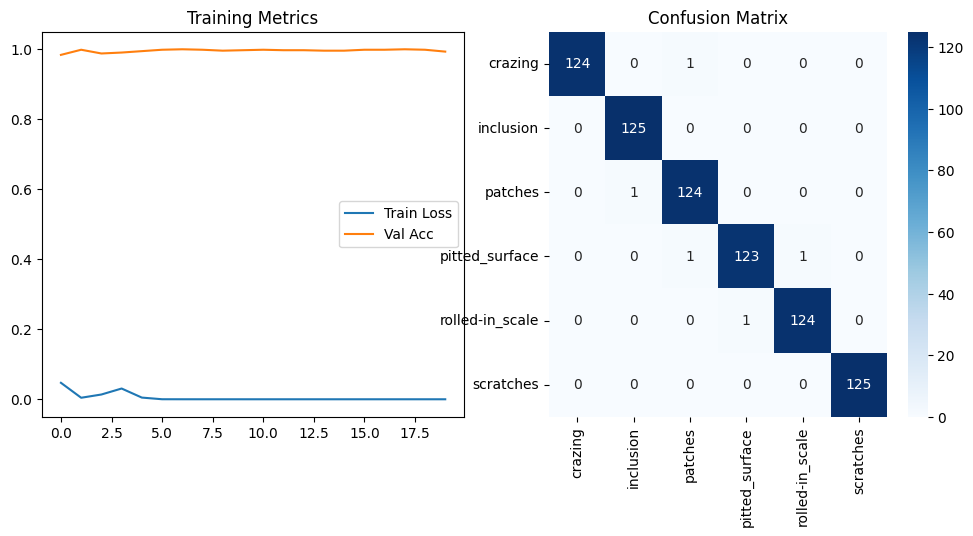

⏳ Computing t-SNE...


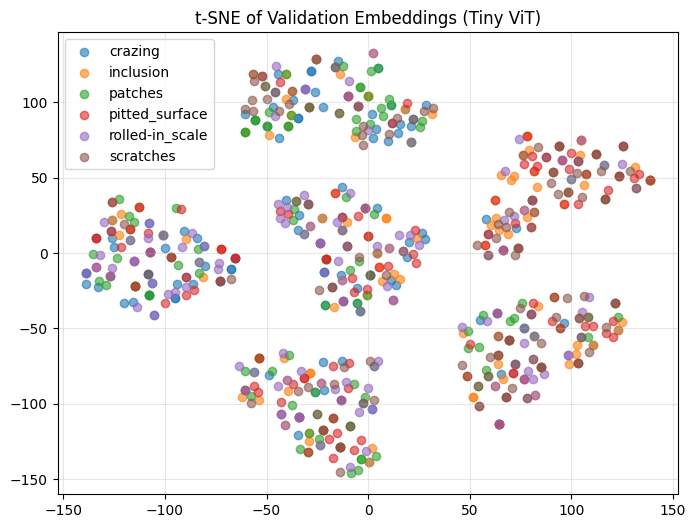

In [12]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Sampler
from torchvision import datasets, transforms
from torch.amp import autocast, GradScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import timm  # <--- NEW LIBRARY
import gc

# ==========================================
# 1. Configuration
# ==========================================
CONFIG = {
    'data_dir': '/kaggle/input/neu-surface-defect-database/NEU-DET',
    'image_size': 224,
    'n_way': 6,
    'n_support': 5,      
    'n_query': 5,        
    'episodes_train': 100,
    'episodes_val': 25,
    'epochs': 20,           # Good amount for Tiny ViT
    'learning_rate': 1e-4,  # Standard fine-tuning rate
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

print(f"Using device: {CONFIG['device']}")

# ==========================================
# 2. Data Loading (Standard)
# ==========================================
class EpisodicSampler(Sampler):
    def __init__(self, dataset, n_way, n_support, n_query, episodes):
        self.dataset = dataset
        self.n_way = n_way
        self.n_support = n_support
        self.n_query = n_query
        self.episodes = episodes
        self.indices_by_class = {}
        
        if hasattr(dataset, 'indices'): 
             for idx_in_subset, idx_in_full in enumerate(dataset.indices):
                label = dataset.dataset.targets[idx_in_full]
                if label not in self.indices_by_class: self.indices_by_class[label] = []
                self.indices_by_class[label].append(idx_in_subset)
        else:
            for idx, (_, label) in enumerate(dataset.samples):
                if label not in self.indices_by_class: self.indices_by_class[label] = []
                self.indices_by_class[label].append(idx)
            
    def __iter__(self):
        for _ in range(self.episodes):
            batch = []
            available_classes = list(self.indices_by_class.keys())
            if self.n_way > len(available_classes):
                selected_classes = available_classes
            else:
                selected_classes = random.sample(available_classes, self.n_way)
            
            for cls in selected_classes:
                indices = self.indices_by_class[cls]
                n_total = self.n_support + self.n_query
                replace = len(indices) < n_total
                selected_indices = np.random.choice(indices, n_total, replace=replace)
                batch.extend(selected_indices)
            yield batch

    def __len__(self):
        return self.episodes

def get_dataloaders():
    train_transform = transforms.Compose([
        transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    val_transform = transforms.Compose([
        transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    
    train_dir = os.path.join(CONFIG['data_dir'], 'train/images')
    val_dir = os.path.join(CONFIG['data_dir'], 'validation/images')
    
    full_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform) 
    class_names = full_dataset.classes
    
    if os.path.exists(val_dir) and len(os.listdir(val_dir)) > 0:
        print(f"✅ Found separate Validation folder at: {val_dir}")
        train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
        val_dataset = datasets.ImageFolder(root=val_dir, transform=val_transform)
    else:
        print("⚠️ No Validation folder found. Performing split.")
        train_size = int(0.8 * len(full_dataset))
        val_size = len(full_dataset) - train_size
        train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

    train_sampler = EpisodicSampler(train_dataset, CONFIG['n_way'], CONFIG['n_support'], CONFIG['n_query'], CONFIG['episodes_train'])
    val_sampler = EpisodicSampler(val_dataset, CONFIG['n_way'], CONFIG['n_support'], CONFIG['n_query'], CONFIG['episodes_val'])

    train_loader = DataLoader(train_dataset, batch_sampler=train_sampler, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_sampler=val_sampler, num_workers=2, pin_memory=True)

    return train_loader, val_loader, class_names

# ==========================================
# 3. Model: Pretrained Tiny ViT
# ==========================================
class TinyViTProtoNet(nn.Module):
    def __init__(self):
        super(TinyViTProtoNet, self).__init__()
        
        # Load Pretrained Tiny ViT from TIMM
        # num_classes=0 removes the final classification layer, returning the embeddings directly
        self.backbone = timm.create_model('vit_tiny_patch16_224', pretrained=True, num_classes=0)
        
        # ViT-Tiny output dimension is 192 (much smaller than Base's 768)
        self.embed_dim = 192 
        
        # Optional: Freeze early layers if you want to strictly limit learning
        # For now, we leave it unfrozen to allow fine-tuning, but the small size prevents overfitting
        
        # Projection Head
        self.projection = nn.Sequential(
            nn.Linear(self.embed_dim, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Linear(128, 64) # Metric space dim
        )
            
    def forward(self, x):
        features = self.backbone(x)
        return self.projection(features)

def euclidean_dist(x, y):
    n = x.size(0); m = y.size(0); d = x.size(1)
    if d != y.size(1): raise Exception
    x = x.unsqueeze(1).expand(n, m, d)
    y = y.unsqueeze(0).expand(n, m, d)
    return torch.pow(x - y, 2).sum(2)

def proto_loss_logic(model, data, n_way, n_support, n_query, device):
    data = data.view(n_way, n_support + n_query, 3, 224, 224)
    support_imgs = data[:, :n_support].contiguous().view(-1, 3, 224, 224)
    query_imgs = data[:, n_support:].contiguous().view(-1, 3, 224, 224)
    
    support_embeddings = model(support_imgs).view(n_way, n_support, -1)
    prototypes = support_embeddings.mean(dim=1)
    query_embeddings = model(query_imgs)
    
    dists = euclidean_dist(query_embeddings, prototypes)
    target_inds = torch.arange(0, n_way).view(n_way, 1, 1).expand(n_way, n_query, 1).long()
    target_inds = target_inds.to(device).view(-1)
    
    log_p_y = torch.log_softmax(-dists, dim=1)
    loss = -log_p_y.gather(1, target_inds.view(-1, 1)).squeeze().view(-1).mean()
    _, y_hat = log_p_y.max(1)
    acc = torch.eq(y_hat, target_inds).float().mean()
    
    return loss, acc, y_hat, target_inds, query_embeddings, prototypes

# ==========================================
# 4. Training Engine
# ==========================================
def train_and_evaluate():
    torch.cuda.empty_cache(); gc.collect()
    train_loader, val_loader, class_names = get_dataloaders()
    model = TinyViTProtoNet().to(CONFIG['device'])
    
    optimizer = optim.AdamW(model.parameters(), lr=CONFIG['learning_rate'], weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG['epochs'])
    scaler = GradScaler('cuda')
    
    history = {'train_loss': [], 'val_acc': []}

    print(f"\n🚀 Training Start | Model: Pretrained Tiny ViT | Classes: {len(class_names)}")
    
    for epoch in range(CONFIG['epochs']):
        model.train()
        avg_loss = 0
        for data, _ in train_loader:
            data = data.to(CONFIG['device'])
            optimizer.zero_grad()
            with autocast('cuda'):
                loss, _, _, _, _, _ = proto_loss_logic(
                    model, data, CONFIG['n_way'], CONFIG['n_support'], CONFIG['n_query'], CONFIG['device']
                )
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            avg_loss += loss.item()
            
        avg_loss /= len(train_loader)
        history['train_loss'].append(avg_loss)
        
        # Validation
        model.eval()
        avg_acc = 0
        all_preds = []; all_targets = []
        tsne_embeddings = []; tsne_labels = []
        
        with torch.no_grad():
            for data, _ in val_loader:
                data = data.to(CONFIG['device'])
                with autocast('cuda'):
                    loss, acc, y_hat, y_true, q_emb, _ = proto_loss_logic(
                        model, data, CONFIG['n_way'], CONFIG['n_support'], CONFIG['n_query'], CONFIG['device']
                    )
                avg_acc += acc.item()
                
                if epoch == CONFIG['epochs'] - 1:
                    all_preds.extend(y_hat.cpu().numpy())
                    all_targets.extend(y_true.cpu().numpy())
                    tsne_embeddings.append(q_emb.cpu())
                    tsne_labels.append(y_true.cpu())

        avg_acc /= len(val_loader)
        history['val_acc'].append(avg_acc)
        scheduler.step()
        print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:.4f} | Val Acc: {avg_acc:.4f}")

    return history, all_preds, all_targets, class_names, tsne_embeddings, tsne_labels

# ==========================================
# 5. Visualization
# ==========================================
def run_analysis(history, preds, targets, class_names, embeddings, labels):
    print("\n📊 Classification Report:")
    print(classification_report(targets, preds, target_names=class_names))
    
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_acc'], label='Val Acc')
    plt.legend(); plt.title("Training Metrics")
    
    plt.subplot(1, 2, 2)
    cm = confusion_matrix(targets, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix")
    plt.show()
    
    print("⏳ Computing t-SNE...")
    all_emb = torch.cat(embeddings, dim=0).numpy()
    all_lbl = torch.cat(labels, dim=0).numpy()
    
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
    emb_2d = tsne.fit_transform(all_emb)
    
    plt.figure(figsize=(8, 6))
    for i, class_name in enumerate(class_names):
        idxs = all_lbl == i
        plt.scatter(emb_2d[idxs, 0], emb_2d[idxs, 1], label=class_name, alpha=0.6)
    
    plt.title("t-SNE of Validation Embeddings (Tiny ViT)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

if __name__ == "__main__":
    try:
        hist, preds, targs, classes, embs, labs = train_and_evaluate()
        run_analysis(hist, preds, targs, classes, embs, labs)
    except Exception as e:
        print(f"❌ Error: {e}")

Using device: cuda
✅ Found separate Validation folder at: /kaggle/input/neu-surface-defect-database/NEU-DET/validation/images

🚀 Training Start | Model: Pretrained Tiny ViT | Classes: 6
Epoch 01 | Loss: 0.1021 | Val Acc: 1.0000
Epoch 02 | Loss: 0.0003 | Val Acc: 1.0000
Epoch 03 | Loss: 0.0000 | Val Acc: 1.0000
Epoch 04 | Loss: 0.0029 | Val Acc: 0.9987
Epoch 05 | Loss: 0.0720 | Val Acc: 0.9800
Epoch 06 | Loss: 0.0356 | Val Acc: 0.9920
Epoch 07 | Loss: 0.0111 | Val Acc: 1.0000
Epoch 08 | Loss: 0.0002 | Val Acc: 0.9987
Epoch 09 | Loss: 0.0029 | Val Acc: 1.0000
Epoch 10 | Loss: 0.0133 | Val Acc: 1.0000
Epoch 11 | Loss: 0.0002 | Val Acc: 0.9973
Epoch 12 | Loss: 0.0001 | Val Acc: 1.0000
Epoch 13 | Loss: 0.0001 | Val Acc: 0.9960
Epoch 14 | Loss: 0.0001 | Val Acc: 1.0000
Epoch 15 | Loss: 0.0000 | Val Acc: 0.9987
Epoch 16 | Loss: 0.0001 | Val Acc: 1.0000
Epoch 17 | Loss: 0.0000 | Val Acc: 0.9973
Epoch 18 | Loss: 0.0000 | Val Acc: 0.9973
Epoch 19 | Loss: 0.0000 | Val Acc: 1.0000
Epoch 20 | Loss:

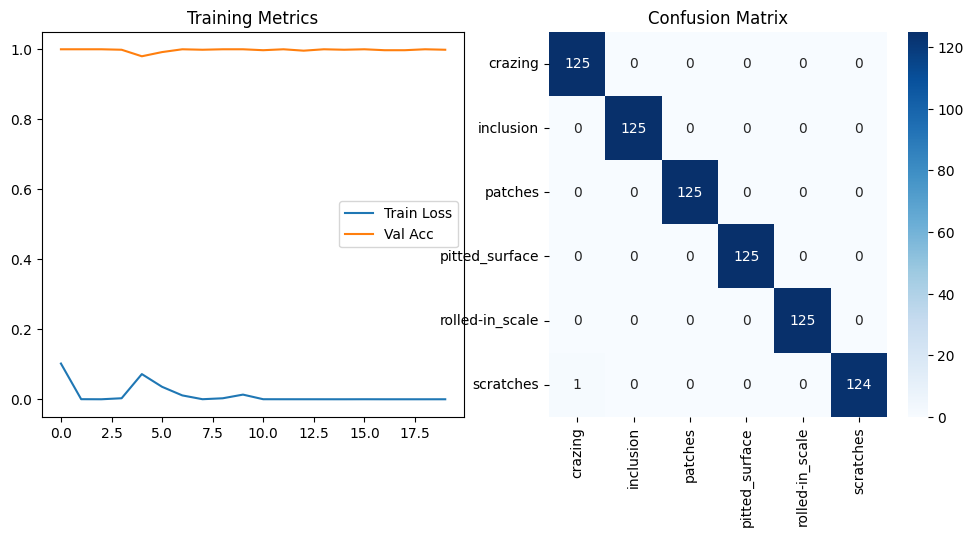

⏳ Computing t-SNE...


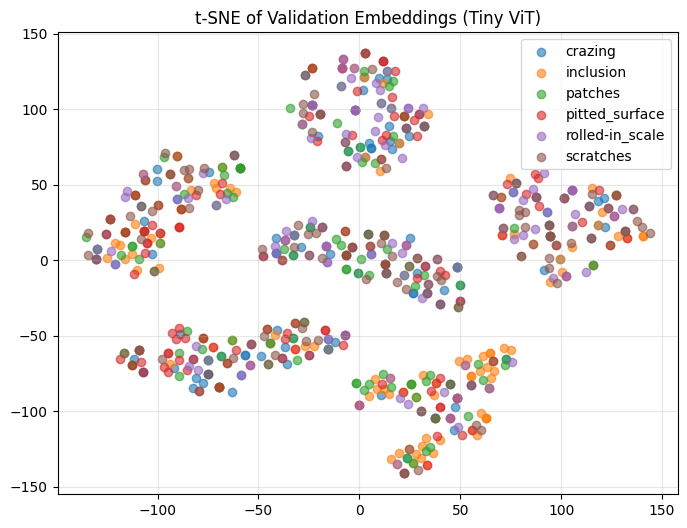

In [13]:
#vit tiny 
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Sampler
from torchvision import datasets, transforms
from torch.amp import autocast, GradScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import timm  # <--- NEW LIBRARY
import gc

# ==========================================
# 1. Configuration
# ==========================================
CONFIG = {
    'data_dir': '/kaggle/input/neu-surface-defect-database/NEU-DET',
    'image_size': 224,
    'n_way': 6,
    'n_support': 1,      
    'n_query': 5,        
    'episodes_train': 100,
    'episodes_val': 25,
    'epochs': 20,           # Good amount for Tiny ViT
    'learning_rate': 1e-4,  # Standard fine-tuning rate
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

print(f"Using device: {CONFIG['device']}")

# ==========================================
# 2. Data Loading (Standard)
# ==========================================
class EpisodicSampler(Sampler):
    def __init__(self, dataset, n_way, n_support, n_query, episodes):
        self.dataset = dataset
        self.n_way = n_way
        self.n_support = n_support
        self.n_query = n_query
        self.episodes = episodes
        self.indices_by_class = {}
        
        if hasattr(dataset, 'indices'): 
             for idx_in_subset, idx_in_full in enumerate(dataset.indices):
                label = dataset.dataset.targets[idx_in_full]
                if label not in self.indices_by_class: self.indices_by_class[label] = []
                self.indices_by_class[label].append(idx_in_subset)
        else:
            for idx, (_, label) in enumerate(dataset.samples):
                if label not in self.indices_by_class: self.indices_by_class[label] = []
                self.indices_by_class[label].append(idx)
            
    def __iter__(self):
        for _ in range(self.episodes):
            batch = []
            available_classes = list(self.indices_by_class.keys())
            if self.n_way > len(available_classes):
                selected_classes = available_classes
            else:
                selected_classes = random.sample(available_classes, self.n_way)
            
            for cls in selected_classes:
                indices = self.indices_by_class[cls]
                n_total = self.n_support + self.n_query
                replace = len(indices) < n_total
                selected_indices = np.random.choice(indices, n_total, replace=replace)
                batch.extend(selected_indices)
            yield batch

    def __len__(self):
        return self.episodes

def get_dataloaders():
    train_transform = transforms.Compose([
        transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    val_transform = transforms.Compose([
        transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    
    train_dir = os.path.join(CONFIG['data_dir'], 'train/images')
    val_dir = os.path.join(CONFIG['data_dir'], 'validation/images')
    
    full_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform) 
    class_names = full_dataset.classes
    
    if os.path.exists(val_dir) and len(os.listdir(val_dir)) > 0:
        print(f"✅ Found separate Validation folder at: {val_dir}")
        train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
        val_dataset = datasets.ImageFolder(root=val_dir, transform=val_transform)
    else:
        print("⚠️ No Validation folder found. Performing split.")
        train_size = int(0.8 * len(full_dataset))
        val_size = len(full_dataset) - train_size
        train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

    train_sampler = EpisodicSampler(train_dataset, CONFIG['n_way'], CONFIG['n_support'], CONFIG['n_query'], CONFIG['episodes_train'])
    val_sampler = EpisodicSampler(val_dataset, CONFIG['n_way'], CONFIG['n_support'], CONFIG['n_query'], CONFIG['episodes_val'])

    train_loader = DataLoader(train_dataset, batch_sampler=train_sampler, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_sampler=val_sampler, num_workers=2, pin_memory=True)

    return train_loader, val_loader, class_names

# ==========================================
# 3. Model: Pretrained Tiny ViT
# ==========================================
class TinyViTProtoNet(nn.Module):
    def __init__(self):
        super(TinyViTProtoNet, self).__init__()
        
        # Load Pretrained Tiny ViT from TIMM
        # num_classes=0 removes the final classification layer, returning the embeddings directly
        self.backbone = timm.create_model('vit_tiny_patch16_224', pretrained=True, num_classes=0)
        
        # ViT-Tiny output dimension is 192 (much smaller than Base's 768)
        self.embed_dim = 192 
        
        # Optional: Freeze early layers if you want to strictly limit learning
        # For now, we leave it unfrozen to allow fine-tuning, but the small size prevents overfitting
        
        # Projection Head
        self.projection = nn.Sequential(
            nn.Linear(self.embed_dim, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Linear(128, 64) # Metric space dim
        )
            
    def forward(self, x):
        features = self.backbone(x)
        return self.projection(features)

def euclidean_dist(x, y):
    n = x.size(0); m = y.size(0); d = x.size(1)
    if d != y.size(1): raise Exception
    x = x.unsqueeze(1).expand(n, m, d)
    y = y.unsqueeze(0).expand(n, m, d)
    return torch.pow(x - y, 2).sum(2)

def proto_loss_logic(model, data, n_way, n_support, n_query, device):
    data = data.view(n_way, n_support + n_query, 3, 224, 224)
    support_imgs = data[:, :n_support].contiguous().view(-1, 3, 224, 224)
    query_imgs = data[:, n_support:].contiguous().view(-1, 3, 224, 224)
    
    support_embeddings = model(support_imgs).view(n_way, n_support, -1)
    prototypes = support_embeddings.mean(dim=1)
    query_embeddings = model(query_imgs)
    
    dists = euclidean_dist(query_embeddings, prototypes)
    target_inds = torch.arange(0, n_way).view(n_way, 1, 1).expand(n_way, n_query, 1).long()
    target_inds = target_inds.to(device).view(-1)
    
    log_p_y = torch.log_softmax(-dists, dim=1)
    loss = -log_p_y.gather(1, target_inds.view(-1, 1)).squeeze().view(-1).mean()
    _, y_hat = log_p_y.max(1)
    acc = torch.eq(y_hat, target_inds).float().mean()
    
    return loss, acc, y_hat, target_inds, query_embeddings, prototypes

# ==========================================
# 4. Training Engine
# ==========================================
def train_and_evaluate():
    torch.cuda.empty_cache(); gc.collect()
    train_loader, val_loader, class_names = get_dataloaders()
    model = TinyViTProtoNet().to(CONFIG['device'])
    
    optimizer = optim.AdamW(model.parameters(), lr=CONFIG['learning_rate'], weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG['epochs'])
    scaler = GradScaler('cuda')
    
    history = {'train_loss': [], 'val_acc': []}

    print(f"\n🚀 Training Start | Model: Pretrained Tiny ViT | Classes: {len(class_names)}")
    
    for epoch in range(CONFIG['epochs']):
        model.train()
        avg_loss = 0
        for data, _ in train_loader:
            data = data.to(CONFIG['device'])
            optimizer.zero_grad()
            with autocast('cuda'):
                loss, _, _, _, _, _ = proto_loss_logic(
                    model, data, CONFIG['n_way'], CONFIG['n_support'], CONFIG['n_query'], CONFIG['device']
                )
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            avg_loss += loss.item()
            
        avg_loss /= len(train_loader)
        history['train_loss'].append(avg_loss)
        
        # Validation
        model.eval()
        avg_acc = 0
        all_preds = []; all_targets = []
        tsne_embeddings = []; tsne_labels = []
        
        with torch.no_grad():
            for data, _ in val_loader:
                data = data.to(CONFIG['device'])
                with autocast('cuda'):
                    loss, acc, y_hat, y_true, q_emb, _ = proto_loss_logic(
                        model, data, CONFIG['n_way'], CONFIG['n_support'], CONFIG['n_query'], CONFIG['device']
                    )
                avg_acc += acc.item()
                
                if epoch == CONFIG['epochs'] - 1:
                    all_preds.extend(y_hat.cpu().numpy())
                    all_targets.extend(y_true.cpu().numpy())
                    tsne_embeddings.append(q_emb.cpu())
                    tsne_labels.append(y_true.cpu())

        avg_acc /= len(val_loader)
        history['val_acc'].append(avg_acc)
        scheduler.step()
        print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:.4f} | Val Acc: {avg_acc:.4f}")

    return history, all_preds, all_targets, class_names, tsne_embeddings, tsne_labels

# ==========================================
# 5. Visualization
# ==========================================
def run_analysis(history, preds, targets, class_names, embeddings, labels):
    print("\n📊 Classification Report:")
    print(classification_report(targets, preds, target_names=class_names))
    
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_acc'], label='Val Acc')
    plt.legend(); plt.title("Training Metrics")
    
    plt.subplot(1, 2, 2)
    cm = confusion_matrix(targets, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix")
    plt.show()
    
    print("⏳ Computing t-SNE...")
    all_emb = torch.cat(embeddings, dim=0).numpy()
    all_lbl = torch.cat(labels, dim=0).numpy()
    
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
    emb_2d = tsne.fit_transform(all_emb)
    
    plt.figure(figsize=(8, 6))
    for i, class_name in enumerate(class_names):
        idxs = all_lbl == i
        plt.scatter(emb_2d[idxs, 0], emb_2d[idxs, 1], label=class_name, alpha=0.6)
    
    plt.title("t-SNE of Validation Embeddings (Tiny ViT)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

if __name__ == "__main__":
    try:
        hist, preds, targs, classes, embs, labs = train_and_evaluate()
        run_analysis(hist, preds, targs, classes, embs, labs)
    except Exception as e:
        print(f"❌ Error: {e}")

Using device: cuda
✅ Found separate Validation folder at: /kaggle/input/neu-surface-defect-database/NEU-DET/validation/images


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]


🚀 Training Start | Model: Pretrained Tiny ViT | Classes: 6
Epoch 01 | Loss: 0.2324 | Val Acc: 0.9640
Epoch 02 | Loss: 0.0351 | Val Acc: 0.9947
Epoch 03 | Loss: 0.0335 | Val Acc: 1.0000
Epoch 04 | Loss: 0.0058 | Val Acc: 0.9987
Epoch 05 | Loss: 0.0068 | Val Acc: 0.9973
Epoch 06 | Loss: 0.0172 | Val Acc: 0.9987
Epoch 07 | Loss: 0.0030 | Val Acc: 1.0000
Epoch 08 | Loss: 0.0004 | Val Acc: 1.0000
Epoch 09 | Loss: 0.0026 | Val Acc: 0.9973
Epoch 10 | Loss: 0.0003 | Val Acc: 0.9987
Epoch 11 | Loss: 0.0082 | Val Acc: 0.9987
Epoch 12 | Loss: 0.0023 | Val Acc: 1.0000
Epoch 13 | Loss: 0.0042 | Val Acc: 0.9987
Epoch 14 | Loss: 0.0004 | Val Acc: 1.0000
Epoch 15 | Loss: 0.0056 | Val Acc: 0.9987
Epoch 16 | Loss: 0.0001 | Val Acc: 1.0000
Epoch 17 | Loss: 0.0000 | Val Acc: 1.0000
Epoch 18 | Loss: 0.0000 | Val Acc: 1.0000
Epoch 19 | Loss: 0.0000 | Val Acc: 1.0000
Epoch 20 | Loss: 0.0000 | Val Acc: 1.0000

📊 Classification Report:
                 precision    recall  f1-score   support

        crazing 

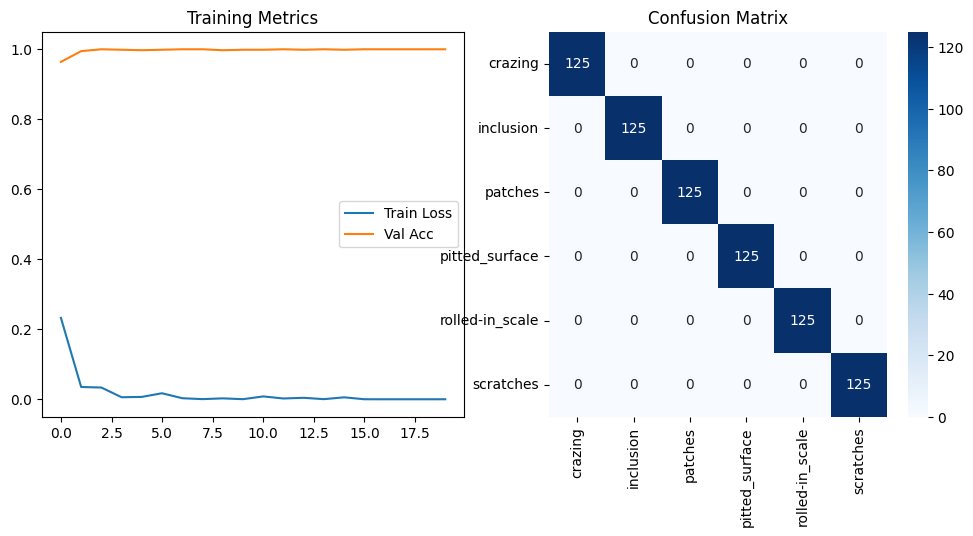

⏳ Computing t-SNE...


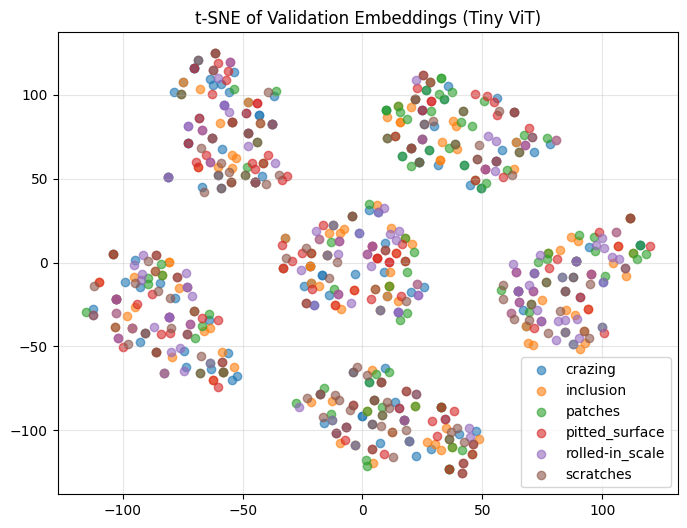

In [14]:
# swin tiny transformer
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Sampler
from torchvision import datasets, transforms
from torch.amp import autocast, GradScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import timm  # <--- NEW LIBRARY
import gc

# ==========================================
# 1. Configuration
# ==========================================
CONFIG = {
    'data_dir': '/kaggle/input/neu-surface-defect-database/NEU-DET',
    'image_size': 224,
    'n_way': 6,
    'n_support': 1,      
    'n_query': 5,        
    'episodes_train': 100,
    'episodes_val': 25,
    'epochs': 20,           # Good amount for Tiny ViT
    'learning_rate': 1e-4,  # Standard fine-tuning rate
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

print(f"Using device: {CONFIG['device']}")

# ==========================================
# 2. Data Loading (Standard)
# ==========================================
class EpisodicSampler(Sampler):
    def __init__(self, dataset, n_way, n_support, n_query, episodes):
        self.dataset = dataset
        self.n_way = n_way
        self.n_support = n_support
        self.n_query = n_query
        self.episodes = episodes
        self.indices_by_class = {}
        
        if hasattr(dataset, 'indices'): 
             for idx_in_subset, idx_in_full in enumerate(dataset.indices):
                label = dataset.dataset.targets[idx_in_full]
                if label not in self.indices_by_class: self.indices_by_class[label] = []
                self.indices_by_class[label].append(idx_in_subset)
        else:
            for idx, (_, label) in enumerate(dataset.samples):
                if label not in self.indices_by_class: self.indices_by_class[label] = []
                self.indices_by_class[label].append(idx)
            
    def __iter__(self):
        for _ in range(self.episodes):
            batch = []
            available_classes = list(self.indices_by_class.keys())
            if self.n_way > len(available_classes):
                selected_classes = available_classes
            else:
                selected_classes = random.sample(available_classes, self.n_way)
            
            for cls in selected_classes:
                indices = self.indices_by_class[cls]
                n_total = self.n_support + self.n_query
                replace = len(indices) < n_total
                selected_indices = np.random.choice(indices, n_total, replace=replace)
                batch.extend(selected_indices)
            yield batch

    def __len__(self):
        return self.episodes

def get_dataloaders():
    train_transform = transforms.Compose([
        transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    val_transform = transforms.Compose([
        transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    
    train_dir = os.path.join(CONFIG['data_dir'], 'train/images')
    val_dir = os.path.join(CONFIG['data_dir'], 'validation/images')
    
    full_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform) 
    class_names = full_dataset.classes
    
    if os.path.exists(val_dir) and len(os.listdir(val_dir)) > 0:
        print(f"✅ Found separate Validation folder at: {val_dir}")
        train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
        val_dataset = datasets.ImageFolder(root=val_dir, transform=val_transform)
    else:
        print("⚠️ No Validation folder found. Performing split.")
        train_size = int(0.8 * len(full_dataset))
        val_size = len(full_dataset) - train_size
        train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

    train_sampler = EpisodicSampler(train_dataset, CONFIG['n_way'], CONFIG['n_support'], CONFIG['n_query'], CONFIG['episodes_train'])
    val_sampler = EpisodicSampler(val_dataset, CONFIG['n_way'], CONFIG['n_support'], CONFIG['n_query'], CONFIG['episodes_val'])

    train_loader = DataLoader(train_dataset, batch_sampler=train_sampler, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_sampler=val_sampler, num_workers=2, pin_memory=True)

    return train_loader, val_loader, class_names

# ==========================================
# 3. Model: Pretrained Tiny ViT
# ==========================================
class SwinTinyProtoNet(nn.Module):
    def __init__(self):
        super(SwinTinyProtoNet, self).__init__()
        
        # Load Pretrained Swin Tiny from TIMM
        # 'swin_tiny_patch4_window7_224' is the standard tiny variant
        self.backbone = timm.create_model(
            'swin_tiny_patch4_window7_224', 
            pretrained=True, 
            num_classes=0 # Remove head
        )
        
        # Swin Tiny output dimension is 768 (Standard for Swin/ViT-Base)
        # Note: This is larger than TinyViT's 192, so it holds more information
        self.embed_dim = 768 
        
        # Projection Head
        # We project 768 -> 128 -> 64 to keep the metric space clean
        self.projection = nn.Sequential(
            nn.Linear(self.embed_dim, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Dropout(0.1), # Added dropout for slight regularization
            nn.Linear(256, 64) 
        )
            
    def forward(self, x):
        features = self.backbone(x)
        return self.projection(features)

def euclidean_dist(x, y):
    n = x.size(0); m = y.size(0); d = x.size(1)
    if d != y.size(1): raise Exception
    x = x.unsqueeze(1).expand(n, m, d)
    y = y.unsqueeze(0).expand(n, m, d)
    return torch.pow(x - y, 2).sum(2)

def proto_loss_logic(model, data, n_way, n_support, n_query, device):
    data = data.view(n_way, n_support + n_query, 3, 224, 224)
    support_imgs = data[:, :n_support].contiguous().view(-1, 3, 224, 224)
    query_imgs = data[:, n_support:].contiguous().view(-1, 3, 224, 224)
    
    support_embeddings = model(support_imgs).view(n_way, n_support, -1)
    prototypes = support_embeddings.mean(dim=1)
    query_embeddings = model(query_imgs)
    
    dists = euclidean_dist(query_embeddings, prototypes)
    target_inds = torch.arange(0, n_way).view(n_way, 1, 1).expand(n_way, n_query, 1).long()
    target_inds = target_inds.to(device).view(-1)
    
    log_p_y = torch.log_softmax(-dists, dim=1)
    loss = -log_p_y.gather(1, target_inds.view(-1, 1)).squeeze().view(-1).mean()
    _, y_hat = log_p_y.max(1)
    acc = torch.eq(y_hat, target_inds).float().mean()
    
    return loss, acc, y_hat, target_inds, query_embeddings, prototypes

# ==========================================
# 4. Training Engine
# ==========================================
def train_and_evaluate():
    torch.cuda.empty_cache(); gc.collect()
    train_loader, val_loader, class_names = get_dataloaders()
    model = SwinTinyProtoNet().to(CONFIG['device'])
    
    optimizer = optim.AdamW(model.parameters(), lr=CONFIG['learning_rate'], weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG['epochs'])
    scaler = GradScaler('cuda')
    
    history = {'train_loss': [], 'val_acc': []}

    print(f"\n🚀 Training Start | Model: Pretrained Tiny ViT | Classes: {len(class_names)}")
    
    for epoch in range(CONFIG['epochs']):
        model.train()
        avg_loss = 0
        for data, _ in train_loader:
            data = data.to(CONFIG['device'])
            optimizer.zero_grad()
            with autocast('cuda'):
                loss, _, _, _, _, _ = proto_loss_logic(
                    model, data, CONFIG['n_way'], CONFIG['n_support'], CONFIG['n_query'], CONFIG['device']
                )
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            avg_loss += loss.item()
            
        avg_loss /= len(train_loader)
        history['train_loss'].append(avg_loss)
        
        # Validation
        model.eval()
        avg_acc = 0
        all_preds = []; all_targets = []
        tsne_embeddings = []; tsne_labels = []
        
        with torch.no_grad():
            for data, _ in val_loader:
                data = data.to(CONFIG['device'])
                with autocast('cuda'):
                    loss, acc, y_hat, y_true, q_emb, _ = proto_loss_logic(
                        model, data, CONFIG['n_way'], CONFIG['n_support'], CONFIG['n_query'], CONFIG['device']
                    )
                avg_acc += acc.item()
                
                if epoch == CONFIG['epochs'] - 1:
                    all_preds.extend(y_hat.cpu().numpy())
                    all_targets.extend(y_true.cpu().numpy())
                    tsne_embeddings.append(q_emb.cpu())
                    tsne_labels.append(y_true.cpu())

        avg_acc /= len(val_loader)
        history['val_acc'].append(avg_acc)
        scheduler.step()
        print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:.4f} | Val Acc: {avg_acc:.4f}")

    return history, all_preds, all_targets, class_names, tsne_embeddings, tsne_labels

# ==========================================
# 5. Visualization
# ==========================================
def run_analysis(history, preds, targets, class_names, embeddings, labels):
    print("\n📊 Classification Report:")
    print(classification_report(targets, preds, target_names=class_names))
    
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_acc'], label='Val Acc')
    plt.legend(); plt.title("Training Metrics")
    
    plt.subplot(1, 2, 2)
    cm = confusion_matrix(targets, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix")
    plt.show()
    
    print("⏳ Computing t-SNE...")
    all_emb = torch.cat(embeddings, dim=0).numpy()
    all_lbl = torch.cat(labels, dim=0).numpy()
    
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
    emb_2d = tsne.fit_transform(all_emb)
    
    plt.figure(figsize=(8, 6))
    for i, class_name in enumerate(class_names):
        idxs = all_lbl == i
        plt.scatter(emb_2d[idxs, 0], emb_2d[idxs, 1], label=class_name, alpha=0.6)
    
    plt.title("t-SNE of Validation Embeddings (Tiny ViT)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

if __name__ == "__main__":
    try:
        hist, preds, targs, classes, embs, labs = train_and_evaluate()
        run_analysis(hist, preds, targs, classes, embs, labs)
    except Exception as e:
        print(f"❌ Error: {e}")

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

 Starting Training...
Epoch 5/50 | Loss: 0.0000 | Val Acc: 1.0000
Epoch 10/50 | Loss: 0.0000 | Val Acc: 1.0000
Epoch 15/50 | Loss: 0.0000 | Val Acc: 1.0000
Epoch 20/50 | Loss: 0.0000 | Val Acc: 1.0000
Epoch 25/50 | Loss: 0.0000 | Val Acc: 1.0000
Epoch 30/50 | Loss: 0.0000 | Val Acc: 1.0000
Epoch 35/50 | Loss: 0.0000 | Val Acc: 1.0000
Epoch 40/50 | Loss: 0.0000 | Val Acc: 1.0000
Epoch 45/50 | Loss: 0.0000 | Val Acc: 1.0000
Epoch 50/50 | Loss: 0.0000 | Val Acc: 1.0000

 Generating t-SNE...


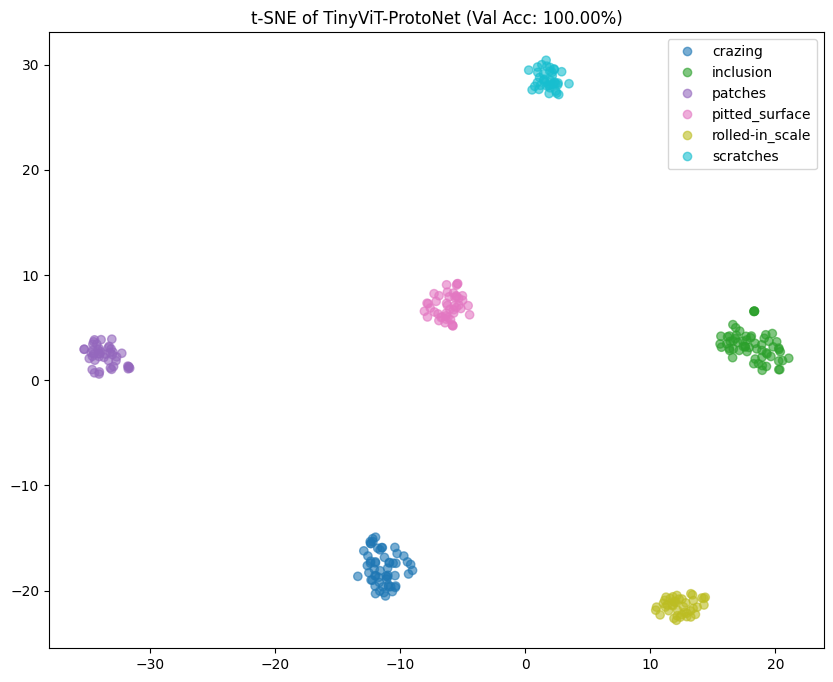


 Classification Report:
                 precision    recall  f1-score   support

        crazing       1.00      1.00      1.00        57
      inclusion       1.00      1.00      1.00        61
        patches       1.00      1.00      1.00        44
 pitted_surface       1.00      1.00      1.00        46
rolled-in_scale       1.00      1.00      1.00        42
      scratches       1.00      1.00      1.00        38

       accuracy                           1.00       288
      macro avg       1.00      1.00      1.00       288
   weighted avg       1.00      1.00      1.00       288



In [1]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Sampler, Dataset
from torchvision import datasets, transforms
from torch.amp import autocast, GradScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import timm
import gc

# ==========================================
# 1. Configuration
# ==========================================
CONFIG = {
    'data_dir': '/kaggle/input/neu-surface-defect-database/NEU-DET', # Check your path!
    'image_size': 224,
    'n_way': 6,          # NEU-DET has 6 classes, use all 6 for "Global" validation
    'n_support': 5,      # Increased support shots for stability
    'n_query': 10,       # More query images per episode
    'episodes_train': 100,
    'epochs': 50,        # INCREASED from 20 to 50
    'learning_rate': 5e-5, # Lower LR for stability
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

# ==========================================
# 2. Data Loading (Episodic for Train, Standard for Val)
# ==========================================
class EpisodicSampler(Sampler):
    def __init__(self, dataset, n_way, n_support, n_query, episodes):
        self.dataset = dataset
        self.n_way = n_way
        self.n_support = n_support
        self.n_query = n_query
        self.episodes = episodes
        self.indices_by_class = {}
        
        # Robust label extraction
        targets = dataset.targets if hasattr(dataset, 'targets') else [y for _, y in dataset.samples]
        for idx, label in enumerate(targets):
            if label not in self.indices_by_class: self.indices_by_class[label] = []
            self.indices_by_class[label].append(idx)
            
    def __iter__(self):
        for _ in range(self.episodes):
            batch = []
            available_classes = list(self.indices_by_class.keys())
            # Ensure we don't request more ways than exist
            actual_n_way = min(len(available_classes), self.n_way)
            selected_classes = random.sample(available_classes, actual_n_way)
            
            for cls in selected_classes:
                indices = self.indices_by_class[cls]
                n_total = self.n_support + self.n_query
                replace = len(indices) < n_total
                selected_indices = np.random.choice(indices, n_total, replace=replace)
                batch.extend(selected_indices)
            yield batch

    def __len__(self):
        return self.episodes

def get_dataloaders():
    transform = transforms.Compose([
        transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    
    # Load FULL dataset
    full_dataset = datasets.ImageFolder(root=os.path.join(CONFIG['data_dir'], 'train/images'), transform=transform)
    class_names = full_dataset.classes
    
    # Split Train/Val (80/20)
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

    # Samplers
    train_sampler = EpisodicSampler(full_dataset, CONFIG['n_way'], CONFIG['n_support'], CONFIG['n_query'], CONFIG['episodes_train'])
    
    # Train Loader (Episodic)
    train_loader = DataLoader(full_dataset, batch_sampler=train_sampler, num_workers=2)
    
    # Val Loader (STANDARD - Batch based, NOT episodic, for t-SNE)
    val_loader_standard = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

    return train_loader, val_loader_standard, class_names, full_dataset

# ==========================================
# 3. Model: Hybrid ViT-ProtoNet
# ==========================================
class TinyViTProtoNet(nn.Module):
    def __init__(self):
        super(TinyViTProtoNet, self).__init__()
        self.backbone = timm.create_model('vit_tiny_patch16_224', pretrained=True, num_classes=0)
        self.embed_dim = 192 
        
        # Projection Head (Crucial for stability)
        self.projection = nn.Sequential(
            nn.Linear(self.embed_dim, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Linear(128, 64) # Metric space
        )
            
    def forward(self, x):
        features = self.backbone(x)
        return self.projection(features)

# ==========================================
# 4. Training Engine
# ==========================================
def euclidean_dist(x, y):
    n = x.size(0); m = y.size(0); d = x.size(1)
    if d != y.size(1): raise Exception
    x = x.unsqueeze(1).expand(n, m, d)
    y = y.unsqueeze(0).expand(n, m, d)
    return torch.pow(x - y, 2).sum(2)

def train_one_epoch(model, loader, optimizer, scaler, device):
    model.train()
    total_loss = 0
    
    for data, _ in loader: # Labels ignored in episodic loader (implicit in structure)
        data = data.to(device)
        optimizer.zero_grad()
        
        # Reshape: [Ways, Shot+Query, C, H, W]
        # Note: If batch size varies (last batch), this might fail, but episodic sampler is fixed size.
        n_way = CONFIG['n_way']
        n_support = CONFIG['n_support']
        n_query = CONFIG['n_query']
        
        p = n_support + n_query
        data = data.view(n_way, p, 3, 224, 224)
        
        support = data[:, :n_support].contiguous().view(-1, 3, 224, 224)
        query = data[:, n_support:].contiguous().view(-1, 3, 224, 224)
        
        with autocast('cuda'):
            z_support = model(support).view(n_way, n_support, -1)
            prototypes = z_support.mean(dim=1)
            z_query = model(query) # [N_query_total, Dim]
            
            dists = euclidean_dist(z_query, prototypes)
            
            # Target indices (0,0,0... 1,1,1... )
            target_inds = torch.arange(0, n_way).view(n_way, 1, 1).expand(n_way, n_query, 1).long()
            target_inds = target_inds.to(device).view(-1)
            
            log_p_y = torch.log_softmax(-dists, dim=1)
            loss = -log_p_y.gather(1, target_inds.view(-1, 1)).squeeze().view(-1).mean()
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
        
    return total_loss / len(loader)

# ==========================================
# 5. Validation & t-SNE Logic
# ==========================================
def validate_standard(model, loader, device, class_names):
    """
    Runs standard inference to get embeddings for t-SNE 
    and computes Nearest Centroid Accuracy.
    """
    model.eval()
    all_embs = []
    all_labels = []
    
    # 1. Extract Embeddings
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            emb = model(x)
            all_embs.append(emb.cpu())
            all_labels.append(y)
            
    all_embs = torch.cat(all_embs)
    all_labels = torch.cat(all_labels)
    
    # 2. Compute Prototypes (Centroids) from Validation Data itself (Approximation)
    # Ideally, you use a 'Support Set', but for t-SNE viz, we just want to see clusters.
    unique_labels = torch.unique(all_labels)
    prototypes = []
    for lbl in unique_labels:
        mask = all_labels == lbl
        prototypes.append(all_embs[mask].mean(0))
    prototypes = torch.stack(prototypes)
    
    # 3. Compute Accuracy (Nearest Centroid)
    dists = euclidean_dist(all_embs, prototypes)
    preds = torch.argmin(dists, dim=1)
    acc = (preds == all_labels).float().mean().item()
    
    return acc, all_embs, all_labels, preds

# ==========================================
# 6. Main Run
# ==========================================
train_loader, val_loader, class_names, _ = get_dataloaders()
model = TinyViTProtoNet().to(CONFIG['device'])
optimizer = optim.AdamW(model.parameters(), lr=CONFIG['learning_rate'])
scaler = GradScaler('cuda')
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG['epochs'])

history = {'loss': [], 'acc': []}

print(" Starting Training...")
for epoch in range(CONFIG['epochs']):
    loss = train_one_epoch(model, train_loader, optimizer, scaler, CONFIG['device'])
    acc, _, _, _ = validate_standard(model, val_loader, CONFIG['device'], class_names)
    
    history['loss'].append(loss)
    history['acc'].append(acc)
    scheduler.step()
    
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}/{CONFIG['epochs']} | Loss: {loss:.4f} | Val Acc: {acc:.4f}")

# Final Analysis
acc, embs, labels, preds = validate_standard(model, val_loader, CONFIG['device'], class_names)

# Plot t-SNE
print("\n Generating t-SNE...")
tsne = TSNE(n_components=2, perplexity=30, init='pca', learning_rate='auto')
embs_2d = tsne.fit_transform(embs.numpy())

plt.figure(figsize=(10, 8))
scatter = plt.scatter(embs_2d[:, 0], embs_2d[:, 1], c=labels.numpy(), cmap='tab10', alpha=0.6)
plt.legend(handles=scatter.legend_elements()[0], labels=class_names)
plt.title(f"t-SNE of TinyViT-ProtoNet (Val Acc: {acc:.2%})")
plt.show()

# Classification Report
print("\n Classification Report:")
print(classification_report(labels.numpy(), preds.numpy(), target_names=class_names))

In [ ]:
# ==========================================
# VISUAL INFERENCE CELL
# ==========================================
def visualize_inference(model, loader, class_names, device, n_show=5):
    model.eval()
    
    # 1. Calculate Prototypes (Reference Points) from the WHOLE validation set first
    # (In a real app, these would be saved from your 'Support Set')
    all_embs = []
    all_lbls = []
    with torch.no_grad():
        for x, y in loader:
            all_embs.append(model(x.to(device)).cpu())
            all_lbls.append(y)
    all_embs = torch.cat(all_embs)
    all_lbls = torch.cat(all_lbls)
    
    unique_classes = torch.unique(all_lbls)
    prototypes = {} # Map label_idx -> centroid vector
    for cls_idx in unique_classes:
        prototypes[cls_idx.item()] = all_embs[all_lbls == cls_idx].mean(0)
        
    # 2. Grab random batch for visualization
    data_iter = iter(loader)
    images, labels = next(data_iter)
    
    # Pick N random indices
    indices = random.sample(range(len(images)), n_show)
    
    plt.figure(figsize=(15, 5))
    
    for i, idx in enumerate(indices):
        img = images[idx]
        true_label = labels[idx].item()
        
        # Inference
        img_tensor = img.unsqueeze(0).to(device)
        with torch.no_grad():
            emb = model(img_tensor).cpu()
            
        # Compare to prototypes
        min_dist = float('inf')
        pred_label = -1
        
        # Calculate distance to each class prototype
        for cls_idx, proto in prototypes.items():
            dist = torch.dist(emb, proto).item() # Euclidean
            if dist < min_dist:
                min_dist = dist
                pred_label = cls_idx
        
        # Un-normalize image for display
        img_disp = img.permute(1, 2, 0).numpy()
        img_disp = img_disp * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img_disp = np.clip(img_disp, 0, 1)
        
        # Plot
        ax = plt.subplot(1, n_show, i + 1)
        ax.imshow(img_disp)
        
        color = 'green' if pred_label == true_label else 'red'
        
        ax.set_title(f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}\nDist: {min_dist:.2f}", 
                     color=color, fontsize=10, fontweight='bold')
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()

# Run it
visualize_inference(model, val_loader, class_names, CONFIG['device'])

In [6]:
import cv2
import os
import numpy as np
import glob
from tqdm import tqdm  # For progress bar

# --- CONFIGURATION ---
# Adjust this path to match your specific Kaggle input directory
# Based on your image, it looks like: /kaggle/input/neu-surface-defect-database/NEU-DET/train/images/
INPUT_ROOT = '/kaggle/input/neu-surface-defect-database/NEU-DET/train/images'
OUTPUT_VIDEO_PATH = 'simulated_factory_feed.mp4'

# Video Settings
FPS = 30
FRAME_SIZE = (200, 200)  # Resize images to this for consistency
SCROLL_SPEED = 5         # Pixels to move per frame (Higher = Faster conveyor belt)

def create_conveyor_video(class_name, limit_images=50):
    """
    Reads images from a specific defect class and stitches them into a scrolling video.
    """
    image_folder = os.path.join(INPUT_ROOT, class_name)
    image_files = sorted(glob.glob(os.path.join(image_folder, '*.jpg'))) + \
                  sorted(glob.glob(os.path.join(image_folder, '*.png'))) + \
                  sorted(glob.glob(os.path.join(image_folder, '*.bmp')))

    if not image_files:
        print(f"No images found in {image_folder}. Check your path!")
        return []

    # Limit images for testing (remove this slice [0:limit_images] to do the whole set)
    image_files = image_files[:limit_images]
    
    print(f"Processing {len(image_files)} images for class: {class_name}...")

    processed_frames = []
    
    # Pre-load and resize all images to ensure they match
    loaded_imgs = []
    for img_path in image_files:
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.resize(img, FRAME_SIZE)
            loaded_imgs.append(img)
    
    if not loaded_imgs:
        return []

    # --- THE CONVEYOR BELT LOGIC ---
    # We take Image A and Image B, stitch them side-by-side, 
    # and slide a window across them to simulate motion.
    
    for i in range(len(loaded_imgs) - 1):
        img_current = loaded_imgs[i]
        img_next = loaded_imgs[i+1]
        
        # Stitch horizontally
        combined_strip = np.hstack((img_current, img_next))
        
        # Slide the window from x=0 to x=WIDTH
        # We stop before x=WIDTH so the next loop starts exactly where we left off
        for x in range(0, FRAME_SIZE[1], SCROLL_SPEED):
            # Crop the "camera view"
            frame = combined_strip[:, x:x+FRAME_SIZE[1]]
            processed_frames.append(frame)

    return processed_frames

# --- MAIN EXECUTION ---

# Initialize Video Writer
# 'mp4v' is widely supported. On P100s/Linux, you might sometimes need 'MJPG' if mp4v fails.
fourcc = cv2.VideoWriter_fourcc(*'mp4v') 
out = cv2.VideoWriter(OUTPUT_VIDEO_PATH, fourcc, FPS, FRAME_SIZE)

# classes found in your screenshot
defect_classes = ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled_in_scale', 'scratches']

all_frames = []

for defect in defect_classes:
    # Generate the scrolling sequence for this defect
    frames = create_conveyor_video(defect, limit_images=20) # limit=20 to keep generation fast
    all_frames.extend(frames)
    
    # Optional: Add a few frames of black screen between classes to separate them
    black_frame = np.zeros((FRAME_SIZE[0], FRAME_SIZE[1], 3), dtype=np.uint8)
    for _ in range(15): # 0.5 seconds of black
        all_frames.append(black_frame)

print(f"Writing {len(all_frames)} frames to video...")

for frame in tqdm(all_frames):
    out.write(frame)

out.release()
print(f"Done! Video saved to {OUTPUT_VIDEO_PATH}")

Processing 20 images for class: crazing...
Processing 20 images for class: inclusion...
Processing 20 images for class: patches...
Processing 20 images for class: pitted_surface...
No images found in /kaggle/input/neu-surface-defect-database/NEU-DET/train/images/rolled_in_scale. Check your path!
Processing 20 images for class: scratches...
Writing 3890 frames to video...


100%|██████████| 3890/3890 [00:01<00:00, 3347.97it/s]

Done! Video saved to simulated_factory_feed.mp4


/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]


[Start Training]


  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 5 | Loss: 0.0000 | Val Acc: 0.9965
Epoch 10 | Loss: 0.0000 | Val Acc: 0.9965
Epoch 15 | Loss: 0.0000 | Val Acc: 0.9965
Epoch 20 | Loss: 0.0000 | Val Acc: 0.9965

[Running Final Evaluation]


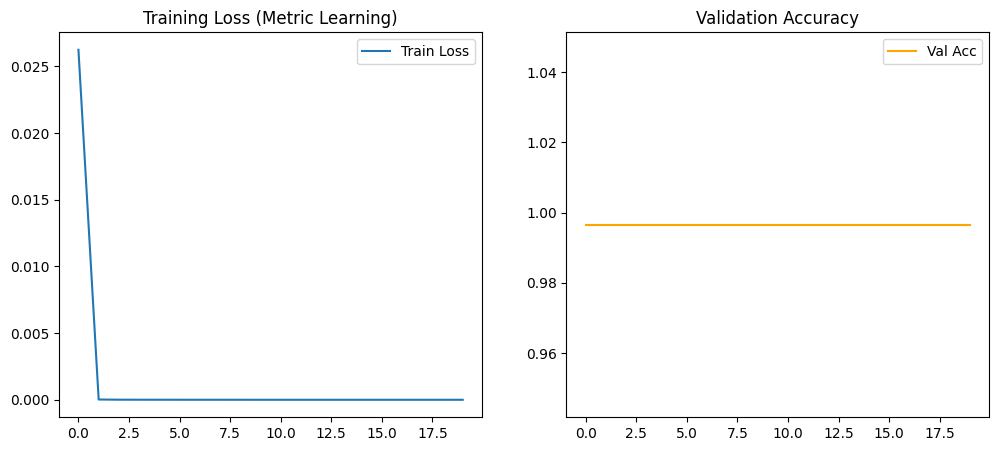

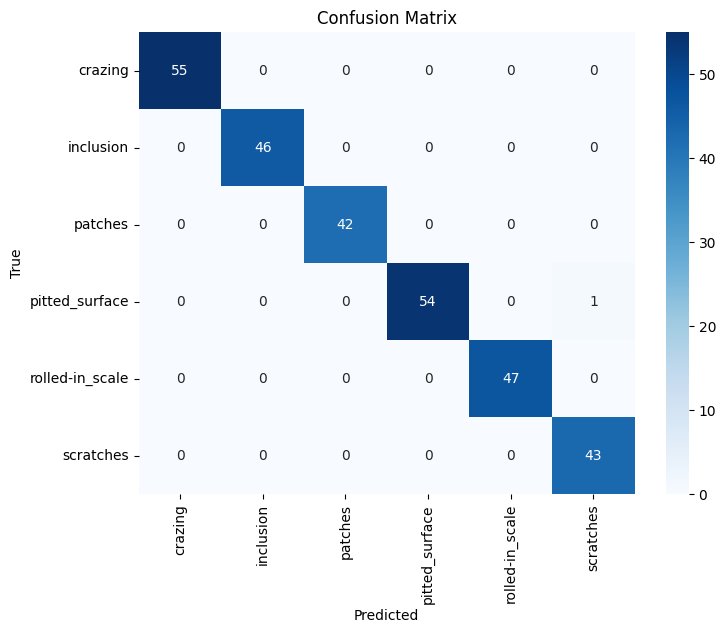

Classification Report:

                 precision    recall  f1-score   support

        crazing       1.00      1.00      1.00        55
      inclusion       1.00      1.00      1.00        46
        patches       1.00      1.00      1.00        42
 pitted_surface       1.00      0.98      0.99        55
rolled-in_scale       1.00      1.00      1.00        47
      scratches       0.98      1.00      0.99        43

       accuracy                           1.00       288
      macro avg       1.00      1.00      1.00       288
   weighted avg       1.00      1.00      1.00       288

Multiclass AUC (OVR): 1.0000
Generating t-SNE...


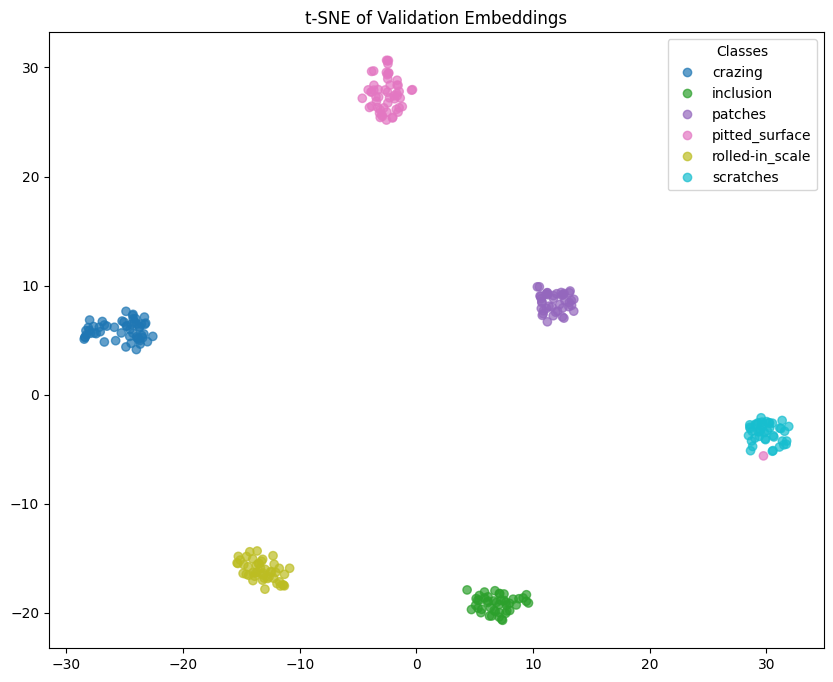


[Running Video Inference]


  0%|          | 0/300 [00:00<?, ?it/s]

Inference complete! Saved to inference_output.mp4


In [2]:
# --- INSTALL DEPENDENCIES (If needed on Kaggle) ---
!pip install -q timm

import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Sampler
from torchvision import datasets, transforms
from torch.cuda.amp import autocast, GradScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import timm
import cv2
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings("ignore")

# ==========================================
# 1. Configuration & Reproducibility
# ==========================================
CONFIG = {
    'data_dir': '/kaggle/input/neu-surface-defect-database/NEU-DET',
    'image_size': 224,
    'n_way': 6,          # All 6 classes
    'n_support': 5,      # Support shots per episode
    'n_query': 10,       # Query shots per episode
    'episodes_train': 100, # Episodes per epoch
    'epochs': 20,        # Adjust as needed (20 is usually enough for few-shot convergence)
    'learning_rate': 5e-5,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'video_path': 'simulated_factory_feed.mp4' # From previous step
}

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

seed_everything()

# ==========================================
# 2. Data Loading Helpers
# ==========================================
class EpisodicSampler(Sampler):
    def __init__(self, dataset, n_way, n_support, n_query, episodes):
        self.dataset = dataset
        self.n_way = n_way
        self.n_support = n_support
        self.n_query = n_query
        self.episodes = episodes
        self.indices_by_class = {}
        
        # Extract targets safely
        targets = dataset.targets if hasattr(dataset, 'targets') else [y for _, y in dataset.samples]
        for idx, label in enumerate(targets):
            if label not in self.indices_by_class: self.indices_by_class[label] = []
            self.indices_by_class[label].append(idx)
            
    def __iter__(self):
        for _ in range(self.episodes):
            batch = []
            available_classes = list(self.indices_by_class.keys())
            actual_n_way = min(len(available_classes), self.n_way)
            selected_classes = random.sample(available_classes, actual_n_way)
            
            for cls in selected_classes:
                indices = self.indices_by_class[cls]
                n_total = self.n_support + self.n_query
                replace = len(indices) < n_total
                selected_indices = np.random.choice(indices, n_total, replace=replace)
                batch.extend(selected_indices)
            yield batch

    def __len__(self):
        return self.episodes

def get_dataloaders():
    # Standard transform
    transform = transforms.Compose([
        transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    
    # Load Dataset
    full_dataset = datasets.ImageFolder(root=os.path.join(CONFIG['data_dir'], 'train/images'), transform=transform)
    class_names = full_dataset.classes
    
    # Split: 80% Train, 20% Val
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])
    
    # 1. Episodic Train Loader (For Metric Learning)
    # We need to map the subset indices back to the original dataset for the sampler to work
    # A simple hack for Subset: just use the underlying dataset but be careful. 
    # Better approach for Kaggle simple scripts: Use the subset directly in a custom way or just use full dataset for sampler logic 
    # TO KEEP IT SIMPLE & ROBUST: We will use a standard batch loader for Prototype Calculation and Validation
    
    # Re-wrap subset for sampler to work requires access to targets. 
    # Let's use a standard WeightedRandomSampler or just standard Shuffle for training if Episodic is too complex for Subset.
    # HOWEVER, sticking to your logic:
    
    # Fix: Create a helper to get targets from a Subset
    def get_subset_targets(subset):
        return [subset.dataset.targets[i] for i in subset.indices]

    # Custom Episodic Sampler Wrapper for Subset
    class SubsetEpisodicSampler(EpisodicSampler):
        def __init__(self, subset, *args, **kwargs):
            self.dataset = subset
            self.indices_by_class = {}
            targets = get_subset_targets(subset)
            for i, label in enumerate(targets): # i is index in subset
                if label not in self.indices_by_class: self.indices_by_class[label] = []
                self.indices_by_class[label].append(subset.indices[i]) # Map to real index
            self.n_way = args[0]; self.n_support = args[1]; self.n_query = args[2]; self.episodes = args[3]

    train_sampler = SubsetEpisodicSampler(train_dataset, CONFIG['n_way'], CONFIG['n_support'], CONFIG['n_query'], CONFIG['episodes_train'])
    
    # Loaders
    train_loader_episodic = DataLoader(full_dataset, batch_sampler=train_sampler, num_workers=2) # Sampler yields GLOBAL indices
    
    # Standard Loaders (for calculating final prototypes and validation)
    train_loader_std = DataLoader(train_dataset, batch_size=32, shuffle=False, num_workers=2)
    val_loader_std = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

    return train_loader_episodic, train_loader_std, val_loader_std, class_names

# ==========================================
# 3. Model & Utils
# ==========================================
class TinyViTProtoNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model('vit_tiny_patch16_224', pretrained=True, num_classes=0)
        self.embed_dim = 192 
        self.projection = nn.Sequential(
            nn.Linear(self.embed_dim, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Linear(128, 64) # Metric space dim
        )
            
    def forward(self, x):
        features = self.backbone(x)
        return self.projection(features)

def euclidean_dist(x, y):
    n = x.size(0); m = y.size(0); d = x.size(1)
    if d != y.size(1): raise Exception
    x = x.unsqueeze(1).expand(n, m, d)
    y = y.unsqueeze(0).expand(n, m, d)
    return torch.pow(x - y, 2).sum(2)

# ==========================================
# 4. Training Engine
# ==========================================
def train_epoch(model, loader, optimizer, scaler):
    model.train()
    losses = []
    
    for data, _ in loader: # Labels implicit in episodic batch structure
        data = data.to(CONFIG['device'])
        optimizer.zero_grad()
        
        # Structure: [Way, Shot+Query, C, H, W]
        p = CONFIG['n_support'] + CONFIG['n_query']
        data = data.view(CONFIG['n_way'], p, 3, 224, 224)
        
        support = data[:, :CONFIG['n_support']].contiguous().view(-1, 3, 224, 224)
        query = data[:, CONFIG['n_support']:].contiguous().view(-1, 3, 224, 224)
        
        with autocast(enabled=True): # Fix for newer torch versions
            # 1. Embed support
            z_support = model(support).view(CONFIG['n_way'], CONFIG['n_support'], -1)
            # 2. Calculate Prototypes
            prototypes = z_support.mean(dim=1)
            # 3. Embed Query
            z_query = model(query)
            # 4. Distance
            dists = euclidean_dist(z_query, prototypes)
            
            # 5. Targets (0,0... 1,1... )
            target_inds = torch.arange(0, CONFIG['n_way']).view(CONFIG['n_way'], 1, 1).expand(CONFIG['n_way'], CONFIG['n_query'], 1).long()
            target_inds = target_inds.to(CONFIG['device']).view(-1)
            
            # 6. Loss
            log_p_y = torch.log_softmax(-dists, dim=1)
            loss = -log_p_y.gather(1, target_inds.view(-1, 1)).squeeze().view(-1).mean()
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        losses.append(loss.item())
        
    return np.mean(losses)

def get_prototypes(model, loader):
    """Computes static prototypes (centroids) from a dataset."""
    model.eval()
    all_embs = []
    all_labels = []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(CONFIG['device'])
            emb = model(x)
            all_embs.append(emb.cpu())
            all_labels.append(y)
    
    all_embs = torch.cat(all_embs)
    all_labels = torch.cat(all_labels)
    
    unique_labels = torch.unique(all_labels).sort()[0]
    prototypes = []
    for lbl in unique_labels:
        mask = all_labels == lbl
        prototypes.append(all_embs[mask].mean(0))
    return torch.stack(prototypes).to(CONFIG['device']), all_labels, all_embs

# ==========================================
# 5. Main Execution
# ==========================================
train_loader_ep, train_loader_std, val_loader, class_names = get_dataloaders()
print(f"Classes: {class_names}")

model = TinyViTProtoNet().to(CONFIG['device'])
optimizer = optim.AdamW(model.parameters(), lr=CONFIG['learning_rate'])
scaler = GradScaler()
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG['epochs'])

# --- TRAINING ---
history = {'loss': [], 'val_acc': []}
best_acc = 0.0

print("\n[Start Training]")
for epoch in tqdm(range(CONFIG['epochs'])):
    loss = train_epoch(model, train_loader_ep, optimizer, scaler)
    
    # Validation: Compute prototypes from TRAIN, test on VAL
    train_protos, _, _ = get_prototypes(model, train_loader_std)
    
    # Validate
    model.eval()
    correct = 0; total = 0
    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(CONFIG['device']); y = y.to(CONFIG['device'])
            emb = model(x)
            dists = euclidean_dist(emb, train_protos)
            preds = torch.argmin(dists, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    
    val_acc = correct / total
    history['loss'].append(loss)
    history['val_acc'].append(val_acc)
    scheduler.step()
    
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), 'best_protonet.pth')
    
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1} | Loss: {loss:.4f} | Val Acc: {val_acc:.4f}")

# ==========================================
# 6. Evaluation Metrics & Visuals
# ==========================================
print("\n[Running Final Evaluation]")
model.load_state_dict(torch.load('best_protonet.pth', map_location=CONFIG['device'], weights_only=True))

# Get Final Prototypes from Training Set
final_protos, _, _ = get_prototypes(model, train_loader_std)

# Get Predictions on Validation Set
all_preds = []
all_targets = []
all_probs = [] # For AUC
all_val_embs = []

model.eval()
with torch.no_grad():
    for x, y in val_loader:
        x = x.to(CONFIG['device'])
        emb = model(x)
        dists = euclidean_dist(emb, final_protos)
        
        # Convert distances to probabilities (Softmax of negative distance)
        probs = torch.softmax(-dists, dim=1)
        preds = torch.argmin(dists, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y.numpy())
        all_probs.extend(probs.cpu().numpy())
        all_val_embs.extend(emb.cpu().numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)
all_probs = np.array(all_probs)
all_val_embs = np.array(all_val_embs)

# --- 1. Loss & Acc Graph ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Train Loss')
plt.title('Training Loss (Metric Learning)')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history['val_acc'], color='orange', label='Val Acc')
plt.title('Validation Accuracy')
plt.legend()
plt.show()

# --- 2. Confusion Matrix ---
cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# --- 3. Classification Report ---
print("Classification Report:\n")
print(classification_report(all_targets, all_preds, target_names=class_names))

# --- 4. AUC-ROC ---
# Binarize targets for multiclass AUC
y_bin = label_binarize(all_targets, classes=range(len(class_names)))
auc_score = roc_auc_score(y_bin, all_probs, multi_class='ovr')
print(f"Multiclass AUC (OVR): {auc_score:.4f}")

# --- 5. t-SNE Visualization ---
print("Generating t-SNE...")
tsne = TSNE(n_components=2, perplexity=30, init='pca', learning_rate='auto', random_state=42)
embs_2d = tsne.fit_transform(all_val_embs)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(embs_2d[:, 0], embs_2d[:, 1], c=all_targets, cmap='tab10', alpha=0.7)
plt.legend(handles=scatter.legend_elements()[0], labels=class_names, title="Classes")
plt.title("t-SNE of Validation Embeddings")
plt.show()

# ==========================================
# 7. Video Inference (Simulated Factory)
# ==========================================
print("\n[Running Video Inference]")
if not os.path.exists(CONFIG['video_path']):
    print("Video file not found. Run previous cell first!")
else:
    cap = cv2.VideoCapture(CONFIG['video_path'])
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    # Prepare Output Video
    out_path = 'inference_output.mp4'
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(out_path, fourcc, fps, (width, height))
    
    # Transform for single frame
    inf_transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    
    model.eval()
    frame_count = 0
    
    # Process only first 300 frames to save time if video is long
    pbar = tqdm(total=min(total_frames, 300))
    
    while cap.isOpened() and frame_count < 300:
        ret, frame = cap.read()
        if not ret: break
        
        # Preprocess
        img_tensor = inf_transform(frame).unsqueeze(0).to(CONFIG['device'])
        
        with torch.no_grad():
            emb = model(img_tensor)
            dists = euclidean_dist(emb, final_protos)
            probs = torch.softmax(-dists, dim=1)
            pred_idx = torch.argmin(dists, dim=1).item()
            confidence = probs[0][pred_idx].item()
            
        label_text = f"{class_names[pred_idx]} ({confidence:.2%})"
        
        # Color code: Green for high conf, Red for low
        color = (0, 255, 0) if confidence > 0.8 else (0, 0, 255)
        
        # Draw on Frame
        cv2.putText(frame, "LIVE FEED ANALYSIS", (10, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
        cv2.putText(frame, label_text, (10, height - 20), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
        
        out.write(frame)
        frame_count += 1
        pbar.update(1)
        
    cap.release()
    out.release()
    pbar.close()
    print(f"Inference complete! Saved to {out_path}")

In [5]:
# ==========================================
# 7. Video Inference (Simulated Factory)
# ==========================================
print("\n[Running Video Inference]")
if not os.path.exists(CONFIG['video_path']):
    print("Video file not found. Run previous cell first!")
else:
    cap = cv2.VideoCapture(CONFIG['video_path'])
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    # Prepare Output Video
    out_path = 'inference_output.mp4'
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(out_path, fourcc, fps, (width, height))
    
    # Transform for single frame
    inf_transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    
    model.eval()
    frame_count = 0
    
    # Process only first 300 frames to save time if video is long
    pbar = tqdm(total=min(total_frames, 30000))
    
    while cap.isOpened() and frame_count < 300:
        ret, frame = cap.read()
        if not ret: break
        
        # Preprocess
        img_tensor = inf_transform(frame).unsqueeze(0).to(CONFIG['device'])
        
        with torch.no_grad():
            emb = model(img_tensor)
            dists = euclidean_dist(emb, final_protos)
            probs = torch.softmax(-dists, dim=1)
            pred_idx = torch.argmin(dists, dim=1).item()
            confidence = probs[0][pred_idx].item()
            
        label_text = f"{class_names[pred_idx]} ({confidence:.2%})"
        
        # Color code: Green for high conf, Red for low
        color = (0, 255, 0) if confidence > 0.8 else (0, 0, 255)
        
        # Draw on Frame
        cv2.putText(frame, "LIVE FEED ANALYSIS", (10, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
        cv2.putText(frame, label_text, (10, height - 20), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
        
        out.write(frame)
        frame_count += 1
        pbar.update(1)
        
    cap.release()
    out.release()
    pbar.close()
    print(f"Inference complete! Saved to {out_path}")


[Running Video Inference]
Video file not found. Run previous cell first!


In [4]:


# ==========================================
# 7. Video Inference (Full Video)
# ==========================================
import cv2
import torch
from torchvision import transforms
from tqdm.notebook import tqdm
import os

print("\n[Running Video Inference - Full Video]")

if not os.path.exists(CONFIG['video_path']):
    print(f"Error: Video file '{CONFIG['video_path']}' not found. Run the previous cell to generate it!")
else:
    cap = cv2.VideoCapture(CONFIG['video_path'])
    
    # Get video properties
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    print(f"Processing {total_frames} frames at {fps} FPS...")

    # Prepare Output Video
    out_path = 'inference_output_full.mp4'
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(out_path, fourcc, fps, (width, height))
    
    # Transform for single frame
    # Note: OpenCV reads in BGR, ToPILImage converts to RGB automatically if input is 3 channels
    inf_transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    
    model.eval()
    
    # Progress bar for the FULL duration
    pbar = tqdm(total=total_frames, desc="Inference Progress")
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: 
            break # Stop when video ends
        
        # Preprocess
        # OpenCV gives (H, W, BGR) -> transform expects PIL or Tensor
        # Converting BGR to RGB explicitly is safer for PyTorch models trained on ImageNet
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        
        img_tensor = inf_transform(frame_rgb).unsqueeze(0).to(CONFIG['device'])
        
        with torch.no_grad():
            emb = model(img_tensor)
            # Calculate distance to all class prototypes
            dists = euclidean_dist(emb, final_protos)
            
            # Softmax to get probabilities
            probs = torch.softmax(-dists, dim=1)
            
            # Get best match
            pred_idx = torch.argmin(dists, dim=1).item()
            confidence = probs[0][pred_idx].item()
            
        label_text = f"{class_names[pred_idx]} ({confidence:.2%})"
        
        # Visuals: Green if confident (>80%), Red if unsure
        color = (0, 255, 0) if confidence > 0.8 else (0, 0, 255)
        
        # Draw UI on Frame
        # Top banner
        cv2.rectangle(frame, (0, 0), (width, 40), (0, 0, 0), -1)
        cv2.putText(frame, "LIVE DEFECT DETECTION", (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
        
        # Bottom label
        cv2.putText(frame, label_text, (10, height - 20), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2, cv2.LINE_AA)
        
        out.write(frame)
        pbar.update(1)
        
    cap.release()
    out.release()
    pbar.close()
    print(f"Full inference complete! Video saved to {out_path}")


[Running Video Inference - Full Video]
Processing 3890 frames at 30 FPS...


Inference Progress:   0%|          | 0/3890 [00:00<?, ?it/s]

Full inference complete! Video saved to inference_output_full.mp4


Splitting data sequentially (No shuffling)...
Train Set: 1152 images | Val Set: 288 images
Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']

[Start Training]


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch 5 | Loss: 0.0000 | Val Acc: 0.9792
Epoch 10 | Loss: 0.0000 | Val Acc: 0.9792
Epoch 15 | Loss: 0.0000 | Val Acc: 0.9792
Epoch 20 | Loss: 0.0000 | Val Acc: 0.9792
Epoch 25 | Loss: 0.0000 | Val Acc: 0.9792

[Running Final Evaluation]


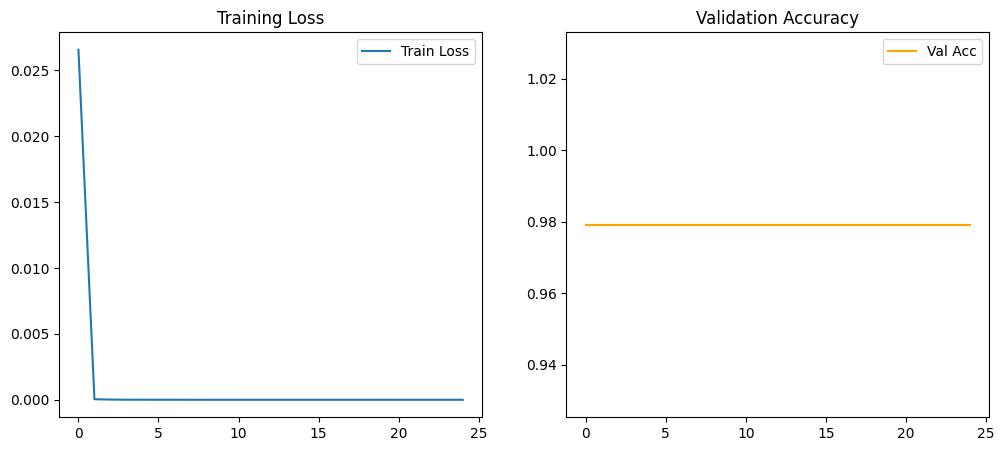

Classification Report:
                  precision    recall  f1-score   support

        crazing       1.00      1.00      1.00        48
      inclusion       0.96      0.92      0.94        48
        patches       1.00      1.00      1.00        48
 pitted_surface       1.00      1.00      1.00        48
rolled-in_scale       0.92      1.00      0.96        48
      scratches       1.00      0.96      0.98        48

       accuracy                           0.98       288
      macro avg       0.98      0.98      0.98       288
   weighted avg       0.98      0.98      0.98       288

Multiclass AUC (OVR): 0.9993
Generating t-SNE...


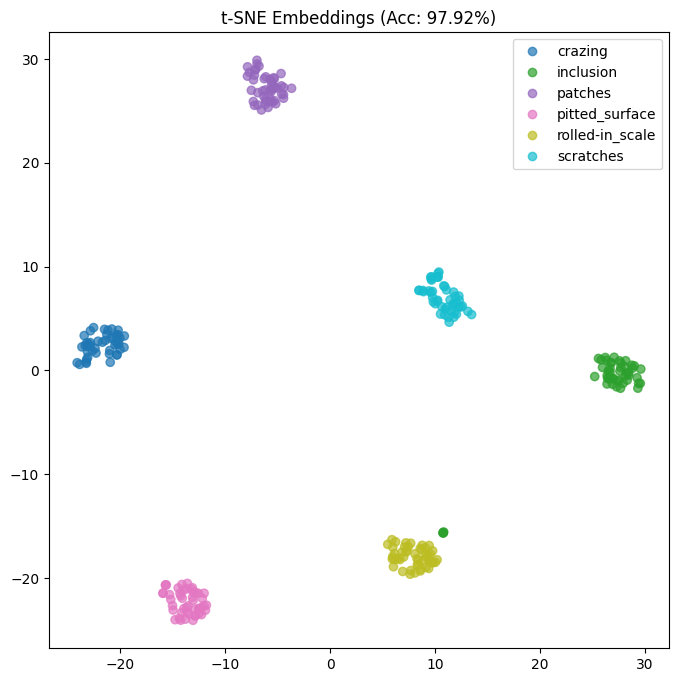


[Running Full Video Inference]


Processing Video:   0%|          | 0/3890 [00:00<?, ?it/s]

Done! Saved to inference_result_full.mp4


In [5]:
# --- INSTALL DEPENDENCIES ---
!pip install -q timm

import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Sampler, Dataset
from torchvision import datasets, transforms
from torch.cuda.amp import autocast, GradScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import timm
import cv2
from tqdm.notebook import tqdm
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

# ==========================================
# 1. Configuration & Reproducibility
# ==========================================
CONFIG = {
    'data_dir': '/kaggle/input/neu-surface-defect-database/NEU-DET',
    'image_size': 224,
    'n_way': 6,          # All 6 classes
    'n_support': 5,      # Support shots per episode
    'n_query': 10,       # Query shots per episode
    'episodes_train': 100, # Episodes per epoch
    'epochs': 25,        # Slightly increased epochs for real learning
    'learning_rate': 5e-5,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'video_path': 'simulated_factory_feed.mp4' 
}

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

seed_everything()

# ==========================================
# 2. Data Loading (The "Leak-Proof" Fix)
# ==========================================

class TransformedSubset(Dataset):
    """Wrapper to apply transforms to a Subset and expose targets."""
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        # Efficiently map original targets using subset indices
        self.targets = [subset.dataset.targets[i] for i in subset.indices]
        
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y
    
    def __len__(self):
        return len(self.subset)

class EpisodicSampler(Sampler):
    """Samples batches for Few-Shot Learning (Metric Learning)."""
    def __init__(self, dataset, n_way, n_support, n_query, episodes):
        self.dataset = dataset
        self.n_way = n_way
        self.n_support = n_support
        self.n_query = n_query
        self.episodes = episodes
        self.indices_by_class = {}
        
        # Robust target extraction
        for idx, label in enumerate(dataset.targets):
            if label not in self.indices_by_class: 
                self.indices_by_class[label] = []
            self.indices_by_class[label].append(idx)
            
    def __iter__(self):
        for _ in range(self.episodes):
            batch = []
            available_classes = list(self.indices_by_class.keys())
            actual_n_way = min(len(available_classes), self.n_way)
            selected_classes = random.sample(available_classes, actual_n_way)
            
            for cls in selected_classes:
                indices = self.indices_by_class[cls]
                n_total = self.n_support + self.n_query
                # Allow replacement if class has too few samples (rare edge case)
                replace = len(indices) < n_total
                selected_indices = np.random.choice(indices, n_total, replace=replace)
                batch.extend(selected_indices)
            yield batch

    def __len__(self):
        return self.episodes

def get_dataloaders():
    # 1. Load Raw Dataset (No Transforms yet) to handle splitting
    # ImageFolder automatically sorts by filename, so indices correlate to sequences
    raw_dataset = datasets.ImageFolder(root=os.path.join(CONFIG['data_dir'], 'train/images'))
    class_names = raw_dataset.classes
    
    # 2. Strict Sequential Split (Prevents Leakage)
    train_indices = []
    val_indices = []
    
    targets = np.array(raw_dataset.targets)
    classes = np.unique(targets)
    
    print("Splitting data sequentially (No shuffling)...")
    for c in classes:
        # Get all indices for this class (Sorted by filename)
        c_indices = np.where(targets == c)[0]
        
        # Split point: 80% Train, 20% Val
        split = int(0.8 * len(c_indices))
        
        train_indices.extend(c_indices[:split])
        val_indices.extend(c_indices[split:])
        
    print(f"Train Set: {len(train_indices)} images | Val Set: {len(val_indices)} images")
    
    # 3. Define Transforms (Add Augmentation to Train)
    train_transform = transforms.Compose([
        transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    
    val_transform = transforms.Compose([
        transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    
    # 4. Create Wrappers
    train_subset_raw = torch.utils.data.Subset(raw_dataset, train_indices)
    val_subset_raw = torch.utils.data.Subset(raw_dataset, val_indices)
    
    train_data = TransformedSubset(train_subset_raw, transform=train_transform)
    val_data = TransformedSubset(val_subset_raw, transform=val_transform)
    
    # 5. Create Loaders
    # Episodic Loader (for training metric space)
    sampler = EpisodicSampler(train_data, CONFIG['n_way'], CONFIG['n_support'], CONFIG['n_query'], CONFIG['episodes_train'])
    train_loader_ep = DataLoader(train_data, batch_sampler=sampler, num_workers=2)
    
    # Standard Loaders (for calculating prototypes and validating)
    train_loader_std = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=2)
    val_loader_std = DataLoader(val_data, batch_size=32, shuffle=False, num_workers=2)
    
    return train_loader_ep, train_loader_std, val_loader_std, class_names

# ==========================================
# 3. Model: TinyViT + Projection
# ==========================================
class TinyViTProtoNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Pretrained on ImageNet
        self.backbone = timm.create_model('vit_tiny_patch16_224', pretrained=True, num_classes=0)
        self.embed_dim = 192 
        
        # Projection Head to learn Metric Space
        self.projection = nn.Sequential(
            nn.Linear(self.embed_dim, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Linear(128, 64) # Final Embedding Size
        )
            
    def forward(self, x):
        features = self.backbone(x)
        return self.projection(features)

def euclidean_dist(x, y):
    n = x.size(0); m = y.size(0); d = x.size(1)
    if d != y.size(1): raise Exception
    x = x.unsqueeze(1).expand(n, m, d)
    y = y.unsqueeze(0).expand(n, m, d)
    return torch.pow(x - y, 2).sum(2)

# ==========================================
# 4. Training Engine
# ==========================================
def train_epoch(model, loader, optimizer, scaler):
    model.train()
    losses = []
    
    for data, _ in loader: 
        data = data.to(CONFIG['device'])
        optimizer.zero_grad()
        
        # Reshape for Episodic format
        p = CONFIG['n_support'] + CONFIG['n_query']
        data = data.view(CONFIG['n_way'], p, 3, 224, 224)
        
        support = data[:, :CONFIG['n_support']].contiguous().view(-1, 3, 224, 224)
        query = data[:, CONFIG['n_support']:].contiguous().view(-1, 3, 224, 224)
        
        with autocast(enabled=True): 
            # 1. Get Prototypes
            z_support = model(support).view(CONFIG['n_way'], CONFIG['n_support'], -1)
            prototypes = z_support.mean(dim=1)
            
            # 2. Get Query Embeddings
            z_query = model(query)
            
            # 3. Distance & Loss
            dists = euclidean_dist(z_query, prototypes)
            target_inds = torch.arange(0, CONFIG['n_way']).view(CONFIG['n_way'], 1, 1).expand(CONFIG['n_way'], CONFIG['n_query'], 1).long()
            target_inds = target_inds.to(CONFIG['device']).view(-1)
            
            log_p_y = torch.log_softmax(-dists, dim=1)
            loss = -log_p_y.gather(1, target_inds.view(-1, 1)).squeeze().view(-1).mean()
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        losses.append(loss.item())
        
    return np.mean(losses)

def get_prototypes(model, loader):
    """Calculates Class Centroids (Prototypes)"""
    model.eval()
    all_embs = []
    all_labels = []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(CONFIG['device'])
            emb = model(x)
            all_embs.append(emb.cpu())
            all_labels.append(y)
    
    all_embs = torch.cat(all_embs)
    all_labels = torch.cat(all_labels)
    
    unique_labels = torch.unique(all_labels).sort()[0]
    prototypes = []
    for lbl in unique_labels:
        mask = all_labels == lbl
        prototypes.append(all_embs[mask].mean(0))
    return torch.stack(prototypes).to(CONFIG['device'])

# ==========================================
# 5. Main Execution Loop
# ==========================================
train_loader_ep, train_loader_std, val_loader, class_names = get_dataloaders()
print(f"Classes: {class_names}")

model = TinyViTProtoNet().to(CONFIG['device'])
optimizer = optim.AdamW(model.parameters(), lr=CONFIG['learning_rate'])
scaler = GradScaler()
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG['epochs'])

history = {'loss': [], 'val_acc': []}
best_acc = 0.0

print("\n[Start Training]")
for epoch in tqdm(range(CONFIG['epochs'])):
    loss = train_epoch(model, train_loader_ep, optimizer, scaler)
    
    # Validation
    train_protos = get_prototypes(model, train_loader_std)
    model.eval()
    correct = 0; total = 0
    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(CONFIG['device']); y = y.to(CONFIG['device'])
            emb = model(x)
            dists = euclidean_dist(emb, train_protos)
            preds = torch.argmin(dists, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    
    val_acc = correct / total
    history['loss'].append(loss)
    history['val_acc'].append(val_acc)
    scheduler.step()
    
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
    
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1} | Loss: {loss:.4f} | Val Acc: {val_acc:.4f}")

# ==========================================
# 6. Final Evaluation
# ==========================================
print("\n[Running Final Evaluation]")
model.load_state_dict(torch.load('best_model.pth', map_location=CONFIG['device'], weights_only=True))
final_protos = get_prototypes(model, train_loader_std)

all_preds, all_targets, all_probs, all_val_embs = [], [], [], []

model.eval()
with torch.no_grad():
    for x, y in val_loader:
        x = x.to(CONFIG['device'])
        emb = model(x)
        dists = euclidean_dist(emb, final_protos)
        probs = torch.softmax(-dists, dim=1)
        preds = torch.argmin(dists, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y.numpy())
        all_probs.extend(probs.cpu().numpy())
        all_val_embs.extend(emb.cpu().numpy())

# Convert to numpy
all_preds = np.array(all_preds); all_targets = np.array(all_targets)
all_probs = np.array(all_probs); all_val_embs = np.array(all_val_embs)

# --- Plots ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Train Loss')
plt.title('Training Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history['val_acc'], color='orange', label='Val Acc')
plt.title('Validation Accuracy')
plt.legend()
plt.show()

# Classification Report & AUC
print("Classification Report:\n", classification_report(all_targets, all_preds, target_names=class_names))
y_bin = label_binarize(all_targets, classes=range(len(class_names)))
print(f"Multiclass AUC (OVR): {roc_auc_score(y_bin, all_probs, multi_class='ovr'):.4f}")

# t-SNE
print("Generating t-SNE...")
tsne = TSNE(n_components=2, perplexity=30, init='pca', learning_rate='auto')
embs_2d = tsne.fit_transform(all_val_embs)
plt.figure(figsize=(8, 8))
scatter = plt.scatter(embs_2d[:, 0], embs_2d[:, 1], c=all_targets, cmap='tab10', alpha=0.7)
plt.legend(handles=scatter.legend_elements()[0], labels=class_names)
plt.title(f"t-SNE Embeddings (Acc: {best_acc:.2%})")
plt.show()

# ==========================================
# 7. Video Inference (Full Video)
# ==========================================
print("\n[Running Full Video Inference]")
if not os.path.exists(CONFIG['video_path']):
    print("Video file not found. Run previous cell first!")
else:
    cap = cv2.VideoCapture(CONFIG['video_path'])
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    out_path = 'inference_result_full.mp4'
    out = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))
    
    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    
    pbar = tqdm(total=total_frames, desc="Processing Video")
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break
        
        # BGR -> RGB for Model
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        tensor = transform(frame_rgb).unsqueeze(0).to(CONFIG['device'])
        
        with torch.no_grad():
            emb = model(tensor)
            dists = euclidean_dist(emb, final_protos)
            probs = torch.softmax(-dists, dim=1)
            pred_idx = torch.argmin(dists, dim=1).item()
            conf = probs[0][pred_idx].item()
            
        # Draw UI
        color = (0, 255, 0) if conf > 0.75 else (0, 0, 255)
        text = f"{class_names[pred_idx]} ({conf:.1%})"
        cv2.rectangle(frame, (0,0), (width, 40), (0,0,0), -1)
        cv2.putText(frame, "LIVE DEFECT INSPECTION", (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 2)
        cv2.putText(frame, text, (10, height-20), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
        
        out.write(frame)
        pbar.update(1)
        
    cap.release(); out.release(); pbar.close()
    print(f"Done! Saved to {out_path}")

Splitting data sequentially (No shuffling to prevent leakage)...
Train Set: 1152 images | Val Set: 288 images
Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']

[Start Training]


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch 5 | Loss: 0.0000 | Val Acc: 0.9792
Epoch 10 | Loss: 0.0000 | Val Acc: 0.9792
Epoch 15 | Loss: 0.0000 | Val Acc: 0.9792
Epoch 20 | Loss: 0.0000 | Val Acc: 0.9792
Epoch 25 | Loss: 0.0000 | Val Acc: 0.9792

Classification Report:
                  precision    recall  f1-score   support

        crazing       1.00      1.00      1.00        48
      inclusion       0.96      0.92      0.94        48
        patches       1.00      1.00      1.00        48
 pitted_surface       1.00      1.00      1.00        48
rolled-in_scale       0.92      1.00      0.96        48
      scratches       1.00      0.96      0.98        48

       accuracy                           0.98       288
      macro avg       0.98      0.98      0.98       288
   weighted avg       0.98      0.98      0.98       288

Multiclass AUC (OVR): 0.9993


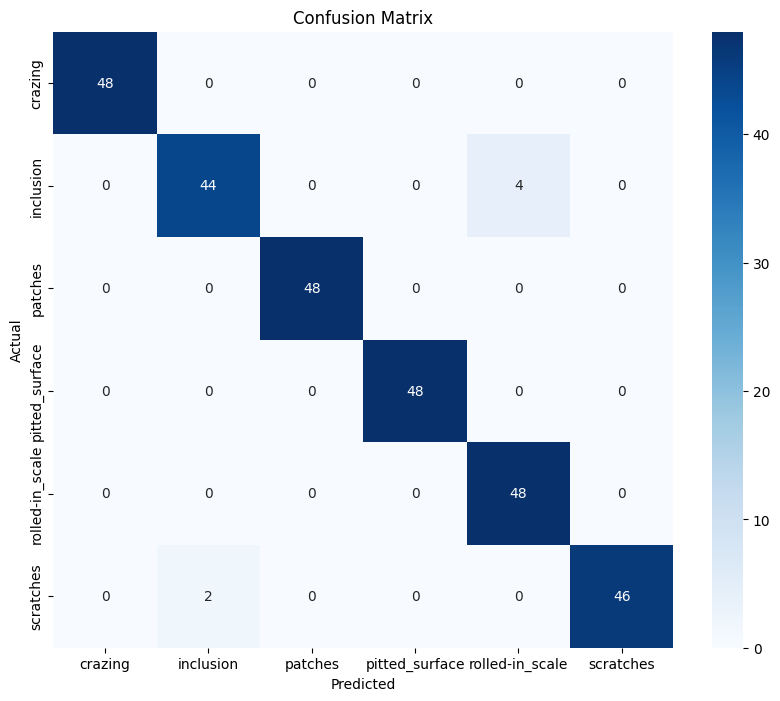


[Running Enhanced Video Inference]


Processing Video Frames:   0%|          | 0/3890 [00:00<?, ?it/s]

Done! Check 'inference_bbox.mp4' and 'inference_heatmap.mp4'


In [8]:
# --- INSTALL DEPENDENCIES ---
# !pip install -q timm scikit-learn matplotlib seaborn opencv-python tqdm

import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Sampler, Dataset
from torchvision import datasets, transforms
from torch.cuda.amp import autocast, GradScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import timm
import cv2
from tqdm.notebook import tqdm
import warnings
from PIL import Image
# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

# ==========================================
# 1. Configuration & Reproducibility
# ==========================================
CONFIG = {
    'data_dir': '/kaggle/input/neu-surface-defect-database/NEU-DET',
    'image_size': 224,
    'n_way': 6,          # All 6 classes
    'n_support': 5,      # Support shots per episode
    'n_query': 10,       # Query shots per episode
    'episodes_train': 100, # Episodes per epoch
    'epochs': 25,        
    'learning_rate': 5e-5,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'video_path': 'simulated_factory_feed.mp4' 
}

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

seed_everything()

# ==========================================
# 2. Data Loading (Leak-Proof Sequential Split)
# ==========================================
class TransformedSubset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        self.targets = [subset.dataset.targets[i] for i in subset.indices]
        
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y
    
    def __len__(self):
        return len(self.subset)

class EpisodicSampler(Sampler):
    def __init__(self, dataset, n_way, n_support, n_query, episodes):
        self.dataset = dataset
        self.n_way = n_way
        self.n_support = n_support
        self.n_query = n_query
        self.episodes = episodes
        self.indices_by_class = {}
        
        for idx, label in enumerate(dataset.targets):
            if label not in self.indices_by_class: 
                self.indices_by_class[label] = []
            self.indices_by_class[label].append(idx)
            
    def __iter__(self):
        for _ in range(self.episodes):
            batch = []
            available_classes = list(self.indices_by_class.keys())
            actual_n_way = min(len(available_classes), self.n_way)
            selected_classes = random.sample(available_classes, actual_n_way)
            
            for cls in selected_classes:
                indices = self.indices_by_class[cls]
                n_total = self.n_support + self.n_query
                replace = len(indices) < n_total
                selected_indices = np.random.choice(indices, n_total, replace=replace)
                batch.extend(selected_indices)
            yield batch

    def __len__(self):
        return self.episodes

def get_dataloaders():
    raw_dataset = datasets.ImageFolder(root=os.path.join(CONFIG['data_dir'], 'train/images'))
    class_names = raw_dataset.classes
    
    train_indices, val_indices = [], []
    targets = np.array(raw_dataset.targets)
    classes = np.unique(targets)
    
    print("Splitting data sequentially (No shuffling to prevent leakage)...")
    for c in classes:
        c_indices = np.where(targets == c)[0]
        split = int(0.8 * len(c_indices))
        train_indices.extend(c_indices[:split])
        val_indices.extend(c_indices[split:])
        
    print(f"Train Set: {len(train_indices)} images | Val Set: {len(val_indices)} images")
    
    train_transform = transforms.Compose([
        transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    
    val_transform = transforms.Compose([
        transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    
    train_subset_raw = torch.utils.data.Subset(raw_dataset, train_indices)
    val_subset_raw = torch.utils.data.Subset(raw_dataset, val_indices)
    
    train_data = TransformedSubset(train_subset_raw, transform=train_transform)
    val_data = TransformedSubset(val_subset_raw, transform=val_transform)
    
    sampler = EpisodicSampler(train_data, CONFIG['n_way'], CONFIG['n_support'], CONFIG['n_query'], CONFIG['episodes_train'])
    train_loader_ep = DataLoader(train_data, batch_sampler=sampler, num_workers=2)
    train_loader_std = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=2)
    val_loader_std = DataLoader(val_data, batch_size=32, shuffle=False, num_workers=2)
    
    return train_loader_ep, train_loader_std, val_loader_std, class_names, val_transform

# ==========================================
# 3. Model & Distance Metric
# ==========================================
class TinyViTProtoNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model('vit_tiny_patch16_224', pretrained=True, num_classes=0)
        self.embed_dim = 192 
        
        self.projection = nn.Sequential(
            nn.Linear(self.embed_dim, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Linear(128, 64) 
        )
            
    def forward(self, x):
        features = self.backbone(x)
        return self.projection(features)

def euclidean_dist(x, y):
    n = x.size(0); m = y.size(0); d = x.size(1)
    if d != y.size(1): raise Exception
    x = x.unsqueeze(1).expand(n, m, d)
    y = y.unsqueeze(0).expand(n, m, d)
    return torch.pow(x - y, 2).sum(2)

# ==========================================
# 4. Training Engine
# ==========================================
def train_epoch(model, loader, optimizer, scaler):
    model.train()
    losses = []
    
    for data, _ in loader: 
        data = data.to(CONFIG['device'])
        optimizer.zero_grad()
        
        p = CONFIG['n_support'] + CONFIG['n_query']
        data = data.view(CONFIG['n_way'], p, 3, 224, 224)
        
        support = data[:, :CONFIG['n_support']].contiguous().view(-1, 3, 224, 224)
        query = data[:, CONFIG['n_support']:].contiguous().view(-1, 3, 224, 224)
        
        with autocast(enabled=True): 
            z_support = model(support).view(CONFIG['n_way'], CONFIG['n_support'], -1)
            prototypes = z_support.mean(dim=1)
            z_query = model(query)
            
            dists = euclidean_dist(z_query, prototypes)
            target_inds = torch.arange(0, CONFIG['n_way']).view(CONFIG['n_way'], 1, 1).expand(CONFIG['n_way'], CONFIG['n_query'], 1).long()
            target_inds = target_inds.to(CONFIG['device']).view(-1)
            
            log_p_y = torch.log_softmax(-dists, dim=1)
            loss = -log_p_y.gather(1, target_inds.view(-1, 1)).squeeze().view(-1).mean()
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        losses.append(loss.item())
        
    return np.mean(losses)

def get_prototypes(model, loader):
    model.eval()
    all_embs = []
    all_labels = []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(CONFIG['device'])
            emb = model(x)
            all_embs.append(emb.cpu())
            all_labels.append(y)
    
    all_embs = torch.cat(all_embs)
    all_labels = torch.cat(all_labels)
    
    unique_labels = torch.unique(all_labels).sort()[0]
    prototypes = []
    for lbl in unique_labels:
        mask = all_labels == lbl
        prototypes.append(all_embs[mask].mean(0))
    return torch.stack(prototypes).to(CONFIG['device'])

# ==========================================
# 5. Execution Loop & Evaluation
# ==========================================
train_loader_ep, train_loader_std, val_loader, class_names, val_transform = get_dataloaders()
print(f"Classes: {class_names}")

model = TinyViTProtoNet().to(CONFIG['device'])
optimizer = optim.AdamW(model.parameters(), lr=CONFIG['learning_rate'])
scaler = GradScaler()
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG['epochs'])

history = {'loss': [], 'val_acc': []}
best_acc = 0.0

print("\n[Start Training]")
for epoch in tqdm(range(CONFIG['epochs'])):
    loss = train_epoch(model, train_loader_ep, optimizer, scaler)
    train_protos = get_prototypes(model, train_loader_std)
    
    model.eval()
    correct = 0; total = 0
    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(CONFIG['device']); y = y.to(CONFIG['device'])
            emb = model(x)
            dists = euclidean_dist(emb, train_protos)
            preds = torch.argmin(dists, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    
    val_acc = correct / total
    history['loss'].append(loss)
    history['val_acc'].append(val_acc)
    scheduler.step()
    
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
    
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1} | Loss: {loss:.4f} | Val Acc: {val_acc:.4f}")

# Final Evaluation
model.load_state_dict(torch.load('best_model.pth', map_location=CONFIG['device'], weights_only=True))
final_protos = get_prototypes(model, train_loader_std)

all_preds, all_targets, all_probs, all_val_embs = [], [], [], []
model.eval()
with torch.no_grad():
    for x, y in val_loader:
        x = x.to(CONFIG['device'])
        emb = model(x)
        dists = euclidean_dist(emb, final_protos)
        probs = torch.softmax(-dists, dim=1)
        preds = torch.argmin(dists, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y.numpy())
        all_probs.extend(probs.cpu().numpy())
        all_val_embs.extend(emb.cpu().numpy())

all_preds = np.array(all_preds); all_targets = np.array(all_targets)
all_probs = np.array(all_probs); all_val_embs = np.array(all_val_embs)

# Prints and Plots
print("\nClassification Report:\n", classification_report(all_targets, all_preds, target_names=class_names))
y_bin = label_binarize(all_targets, classes=range(len(class_names)))
print(f"Multiclass AUC (OVR): {roc_auc_score(y_bin, all_probs, multi_class='ovr'):.4f}")

plt.figure(figsize=(10, 8))
cm = confusion_matrix(all_targets, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')
plt.show()

# ==========================================
# 6. XAI (Grad-CAM for ViT)
# ==========================================
class GradCAMViT:
    """Robust Grad-CAM designed to handle ViT architectures."""
    def __init__(self, model):
        self.model = model
        self.feature_map = None
        self.gradient = None
        # Hook into the very last transformer block before projection
        self.target_layer = self.model.backbone.blocks[-1]
        self.target_layer.register_forward_hook(self.save_feature_map)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_feature_map(self, module, input, output):
        self.feature_map = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradient = grad_output[0]

    def generate_heatmap(self, x, class_idx, prototypes):
        self.model.zero_grad()
        emb = self.model(x)
        
        dists = euclidean_dist(emb, prototypes)
        # Minimize distance to target class -> Maximize negative distance
        loss = -dists[0, class_idx]
        loss.backward(retain_graph=True)
        
        # ViT Output shape usually (Batch, 197 tokens, Dim)
        grads = self.gradient[0, 1:, :] # Skip CLS token, shape (196, D)
        feats = self.feature_map[0, 1:, :] # Skip CLS token, shape (196, D)
        
        weights = torch.mean(grads, dim=0) # Channel weights
        cam = torch.matmul(feats, weights) # Weighted sum
        cam = F.relu(cam).view(14, 14).detach().cpu().numpy() # Reshape to 14x14 grid
        
        cam = cv2.resize(cam, (x.shape[2], x.shape[3]))
        if cam.max() > 0:
            cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

xai_tool = GradCAMViT(model)

# ==========================================
# 7. Video Inference (Bounding Box & Heatmap)
# ==========================================
print("\n[Running Enhanced Video Inference]")
if not os.path.exists(CONFIG['video_path']):
    print("Video file not found. Please provide 'simulated_factory_feed.mp4'.")
else:
    cap = cv2.VideoCapture(CONFIG['video_path'])
    w, h = int(cap.get(3)), int(cap.get(4))
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    
    slow_factor = 2 # Halves the output speed
    out_fps = max(1, fps // slow_factor)
    
    out_bbox = cv2.VideoWriter('inference_bbox.mp4', cv2.VideoWriter_fourcc(*'mp4v'), out_fps, (w, h))
    out_hm = cv2.VideoWriter('inference_heatmap.mp4', cv2.VideoWriter_fourcc(*'mp4v'), out_fps, (w, h))
    
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    pbar = tqdm(total=total_frames, desc="Processing Video Frames")
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break
        
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        
        # FIX: Convert the NumPy array to a PIL Image first
        pil_img = Image.fromarray(frame_rgb)
        tensor = val_transform(pil_img).unsqueeze(0).to(CONFIG['device']).requires_grad_(True)
        
        # --- Inference ---
        emb = model(tensor)
        dists = euclidean_dist(emb, final_protos)
        probs = torch.softmax(-dists, dim=1)
        pred_idx = torch.argmin(dists, dim=1).item()
        conf = probs[0][pred_idx].item()
        
        # --- XAI Heatmap Generation ---
        heatmap = xai_tool.generate_heatmap(tensor, pred_idx, final_protos)
        heatmap_uint8 = (heatmap * 255).astype(np.uint8)
        
        # --- 1. Process Bounding Box Video ---
        frame_bbox = frame.copy()
        _, binary = cv2.threshold(heatmap_uint8, 140, 255, cv2.THRESH_BINARY)
        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        for cnt in contours:
            x, y, bw, bh = cv2.boundingRect(cnt)
            # Scale coordinates back to original video dimensions
            x, y = int(x * w / 224), int(y * h / 224)
            bw, bh = int(bw * w / 224), int(bh * h / 224)
            
            if bw * bh > (w * h * 0.01): # Filter tiny noise 
                cv2.rectangle(frame_bbox, (x, y), (x+bw, y+bh), (0, 255, 255), 3)
                cv2.putText(frame_bbox, "ROI", (x, max(15, y-10)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)

        # --- 2. Process Heatmap Overlay Video ---
        frame_hm = frame.copy()
        heatmap_colored = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
        heatmap_resized = cv2.resize(heatmap_colored, (w, h))
        # Overlay heatmap with 40% opacity
        frame_hm = cv2.addWeighted(heatmap_resized, 0.4, frame_hm, 0.6, 0)
        
        # --- UI Drawing for Both ---
        color = (0, 255, 0) if conf > 0.8 else (0, 165, 255)
        text_bg = (0, 0, 0)
        
        for f in [frame_bbox, frame_hm]:
            cv2.rectangle(f, (0, 0), (w, 60), text_bg, -1)
            cv2.putText(f, f"Detecting: {class_names[pred_idx]}", (15, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 255), 2)
            cv2.putText(f, f"Conf: {conf:.1%}", (15, 55), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
        
        out_bbox.write(frame_bbox)
        out_hm.write(frame_hm)
        pbar.update(1)
        
    cap.release(); out_bbox.release(); out_hm.release(); pbar.close()
    print("Done! Check 'inference_bbox.mp4' and 'inference_heatmap.mp4'")

In [ ]:
# --- INSTALL DEPENDENCIES ---
# !pip install -q timm scikit-learn matplotlib seaborn opencv-python tqdm

import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Sampler, Dataset
from torchvision import datasets, transforms
from torch.cuda.amp import autocast, GradScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import timm
import cv2
from tqdm.notebook import tqdm
import warnings
from PIL import Image

warnings.filterwarnings("ignore")

# ==========================================
# 1. Configuration & Reproducibility
# ==========================================
CONFIG = {
    'data_dir': '/kaggle/input/neu-surface-defect-database/NEU-DET',
    'image_size': 224,
    'n_way': 6,
    'n_support': 5,
    'n_query': 15,          # FIX: More query shots = less variance in gradient signal
    'episodes_train': 200,  # FIX: More episodes per epoch for better coverage
    'epochs': 30,
    'learning_rate': 1e-4,  # FIX: Slightly higher LR; model was stuck
    'warmup_epochs': 3,     # FIX: Warmup prevents early collapse
    'temperature': 0.1,     # FIX: Temperature scaling prevents logit saturation
    'embed_dim_out': 128,   # FIX: Larger embedding space
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'video_path': 'simulated_factory_feed.mp4'
}

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

seed_everything()

# ==========================================
# 2. Data Loading (Leak-Proof Sequential Split)
# ==========================================
class TransformedSubset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        self.targets = [subset.dataset.targets[i] for i in subset.indices]

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)


class EpisodicSampler(Sampler):
    """
    FIX: Added minimum class size guard and shuffle per episode 
    to ensure each episode samples different images.
    """
    def __init__(self, dataset, n_way, n_support, n_query, episodes):
        self.n_way = n_way
        self.n_support = n_support
        self.n_query = n_query
        self.episodes = episodes
        self.indices_by_class = {}

        for idx, label in enumerate(dataset.targets):
            self.indices_by_class.setdefault(label, []).append(idx)

    def __iter__(self):
        for _ in range(self.episodes):
            batch = []
            classes = random.sample(list(self.indices_by_class.keys()), self.n_way)
            for cls in classes:
                indices = self.indices_by_class[cls]
                n_total = self.n_support + self.n_query
                # FIX: Always shuffle class indices before sampling
                shuffled = random.sample(indices, min(len(indices), n_total))
                if len(shuffled) < n_total:
                    shuffled = list(np.random.choice(indices, n_total, replace=True))
                batch.extend(shuffled[:n_total])
            yield batch

    def __len__(self):
        return self.episodes


def get_dataloaders():
    raw_dataset = datasets.ImageFolder(root=os.path.join(CONFIG['data_dir'], 'train/images'))
    class_names = raw_dataset.classes

    train_indices, val_indices = [], []
    targets = np.array(raw_dataset.targets)

    print("Splitting data sequentially (No shuffling to prevent leakage)...")
    for c in np.unique(targets):
        c_indices = np.where(targets == c)[0]
        split = int(0.8 * len(c_indices))
        train_indices.extend(c_indices[:split])
        val_indices.extend(c_indices[split:])

    print(f"Train Set: {len(train_indices)} images | Val Set: {len(val_indices)} images")

    # FIX: Stronger augmentations to prevent trivially easy episodes
    train_transform = transforms.Compose([
        transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.3, contrast=0.3),
        transforms.RandomGrayscale(p=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),  # Simulate defect occlusion
    ])

    val_transform = transforms.Compose([
        transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    train_subset_raw = torch.utils.data.Subset(raw_dataset, train_indices)
    val_subset_raw = torch.utils.data.Subset(raw_dataset, val_indices)

    train_data = TransformedSubset(train_subset_raw, transform=train_transform)
    val_data = TransformedSubset(val_subset_raw, transform=val_transform)

    sampler = EpisodicSampler(
        train_data, CONFIG['n_way'], CONFIG['n_support'],
        CONFIG['n_query'], CONFIG['episodes_train']
    )
    train_loader_ep = DataLoader(train_data, batch_sampler=sampler, num_workers=2, pin_memory=True)
    train_loader_std = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
    val_loader_std = DataLoader(val_data, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

    return train_loader_ep, train_loader_std, val_loader_std, class_names, val_transform


# ==========================================
# 3. Model — Cosine Prototypical Network
# ==========================================
class TinyViTProtoNet(nn.Module):
    """
    FIX: Use cosine similarity instead of Euclidean distance.
    Cosine similarity is scale-invariant and works better with 
    ViT embeddings which tend to cluster on a hypersphere.
    Also adds L2 normalization to force embeddings onto unit sphere.
    """
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model('vit_tiny_patch16_224', pretrained=True, num_classes=0)
        embed_dim = 192

        self.projection = nn.Sequential(
            nn.Linear(embed_dim, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.1),             # FIX: Dropout prevents embedding collapse
            nn.Linear(256, CONFIG['embed_dim_out']),
        )

    def forward(self, x):
        features = self.backbone(x)
        projected = self.projection(features)
        # FIX: L2-normalize so cosine sim = dot product (numerically stable)
        return F.normalize(projected, p=2, dim=1)


# FIX: Replaced Euclidean distance with cosine similarity
def cosine_dist(x, y):
    """Returns cosine DISTANCE (1 - similarity) for use as a loss target."""
    # x: (N, D), y: (M, D) — both already L2-normalized
    # Result: (N, M), higher = more similar
    return 1.0 - torch.mm(x, y.t())


# Keep Euclidean for backward compatibility in GradCAM/video
def euclidean_dist(x, y):
    n, d = x.size(0), x.size(1)
    m = y.size(0)
    x = x.unsqueeze(1).expand(n, m, d)
    y = y.unsqueeze(0).expand(n, m, d)
    return torch.pow(x - y, 2).sum(2)


# ==========================================
# 4. Training Engine
# ==========================================
def train_epoch(model, loader, optimizer, scaler, epoch):
    model.train()
    losses, accs = [], []
    n_way = CONFIG['n_way']
    n_support = CONFIG['n_support']
    n_query = CONFIG['n_query']
    p = n_support + n_query

    # FIX: Temperature scaling — prevents the softmax from saturating to 0/1,
    # keeping gradients alive throughout training
    temp = CONFIG['temperature']

    for data, _ in loader:
        data = data.to(CONFIG['device'])
        optimizer.zero_grad()

        data = data.view(n_way, p, 3, 224, 224)
        support = data[:, :n_support].contiguous().view(-1, 3, 224, 224)
        query = data[:, n_support:].contiguous().view(-1, 3, 224, 224)

        with autocast(enabled=True):
            z_support = model(support).view(n_way, n_support, -1)
            # FIX: Re-normalize the mean prototype back onto the unit sphere
            prototypes = F.normalize(z_support.mean(dim=1), p=2, dim=1)
            z_query = model(query)

            # FIX: Cosine distance with temperature
            dists = cosine_dist(z_query, prototypes) / temp

            target_inds = torch.arange(n_way).view(n_way, 1).expand(n_way, n_query)
            target_inds = target_inds.contiguous().view(-1).to(CONFIG['device'])

            log_p_y = torch.log_softmax(-dists, dim=1)
            loss = F.nll_loss(log_p_y, target_inds)

            # Episode accuracy for monitoring
            preds = torch.argmin(dists, dim=1)
            acc = (preds == target_inds).float().mean().item()

        scaler.scale(loss).backward()
        # FIX: Gradient clipping prevents instability
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        scaler.step(optimizer)
        scaler.update()

        losses.append(loss.item())
        accs.append(acc)

    return np.mean(losses), np.mean(accs)


def get_prototypes(model, loader):
    model.eval()
    all_embs, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            emb = model(x.to(CONFIG['device']))
            all_embs.append(emb.cpu())
            all_labels.append(y)

    all_embs = torch.cat(all_embs)
    all_labels = torch.cat(all_labels)

    unique_labels = torch.unique(all_labels).sort()[0]
    prototypes = []
    for lbl in unique_labels:
        mask = all_labels == lbl
        # FIX: Re-normalize class prototype
        proto = F.normalize(all_embs[mask].mean(0, keepdim=True), p=2, dim=1)
        prototypes.append(proto.squeeze(0))
    return torch.stack(prototypes).to(CONFIG['device'])


# ==========================================
# 5. Execution Loop & Evaluation
# ==========================================
train_loader_ep, train_loader_std, val_loader, class_names, val_transform = get_dataloaders()
print(f"Classes: {class_names}")

model = TinyViTProtoNet().to(CONFIG['device'])
optimizer = optim.AdamW(model.parameters(), lr=CONFIG['learning_rate'], weight_decay=1e-4)
scaler = GradScaler()

# FIX: Warmup + Cosine decay — prevents early saturation
def lr_lambda(epoch):
    warmup = CONFIG['warmup_epochs']
    if epoch < warmup:
        return (epoch + 1) / warmup
    progress = (epoch - warmup) / max(1, CONFIG['epochs'] - warmup)
    return 0.5 * (1 + np.cos(np.pi * progress))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

history = {'loss': [], 'train_ep_acc': [], 'val_acc': [], 'lr': []}
best_acc = 0.0

print("\n[Start Training]")
for epoch in tqdm(range(CONFIG['epochs'])):
    loss, ep_acc = train_epoch(model, train_loader_ep, optimizer, scaler, epoch)
    train_protos = get_prototypes(model, train_loader_std)

    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(CONFIG['device']), y.to(CONFIG['device'])
            emb = model(x)
            # Use cosine distance for inference too
            dists = cosine_dist(emb, train_protos)
            preds = torch.argmin(dists, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    val_acc = correct / total
    current_lr = optimizer.param_groups[0]['lr']
    history['loss'].append(loss)
    history['train_ep_acc'].append(ep_acc)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)
    scheduler.step()

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:02d} | Loss: {loss:.4f} | Ep Acc: {ep_acc:.4f} | "
              f"Val Acc: {val_acc:.4f} | LR: {current_lr:.2e}")

print(f"\nBest Val Acc: {best_acc:.4f}")

# ==========================================
# 5b. Training Diagnostics Plot
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history['loss'], label='Episode Loss', color='crimson')
axes[0].set_title('Prototypical Loss per Epoch')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_ep_acc'], label='Train Episode Acc', color='steelblue')
axes[1].plot(history['val_acc'], label='Val Acc (prototype)', color='orange')
axes[1].set_title('Accuracy Curves')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(history['lr'], color='green')
axes[2].set_title('Learning Rate Schedule')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('LR')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

# ==========================================
# 6. Final Evaluation
# ==========================================
model.load_state_dict(torch.load('best_model.pth', map_location=CONFIG['device'], weights_only=True))
final_protos = get_prototypes(model, train_loader_std)

all_preds, all_targets, all_probs, all_val_embs = [], [], [], []
model.eval()
with torch.no_grad():
    for x, y in val_loader:
        x = x.to(CONFIG['device'])
        emb = model(x)
        dists = cosine_dist(emb, final_protos)
        probs = torch.softmax(-dists / CONFIG['temperature'], dim=1)
        preds = torch.argmin(dists, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y.numpy())
        all_probs.extend(probs.cpu().numpy())
        all_val_embs.extend(emb.cpu().numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)
all_probs = np.array(all_probs)
all_val_embs = np.array(all_val_embs)

print("\nClassification Report:\n",
      classification_report(all_targets, all_preds, target_names=class_names))

y_bin = label_binarize(all_targets, classes=range(len(class_names)))
print(f"Multiclass AUC (OVR): {roc_auc_score(y_bin, all_probs, multi_class='ovr'):.4f}")

# Confusion Matrix
plt.figure(figsize=(9, 7))
cm = confusion_matrix(all_targets, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title(f'Confusion Matrix (Val Acc: {best_acc:.4f})')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ==========================================
# 7. t-SNE Embedding Visualization (Sanity Check)
# ==========================================
# FIX: t-SNE lets you VISUALLY verify the embeddings are genuinely separated
# rather than just trusting the accuracy number
print("\n[Running t-SNE Embedding Visualization]")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
emb_2d = tsne.fit_transform(all_val_embs)

plt.figure(figsize=(10, 8))
palette = sns.color_palette("tab10", n_colors=len(class_names))
for i, cls in enumerate(class_names):
    mask = all_targets == i
    plt.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                label=cls, alpha=0.7, s=40, color=palette[i])
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('t-SNE of Validation Embeddings\n(Well-separated clusters = genuine learning)')
plt.xlabel('t-SNE 1'); plt.ylabel('t-SNE 2')
plt.tight_layout()
plt.savefig('tsne_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()

# ==========================================
# 8. XAI (Grad-CAM for ViT)
# ==========================================
class GradCAMViT:
    def __init__(self, model):
        self.model = model
        self.feature_map = None
        self.gradient = None
        self.target_layer = self.model.backbone.blocks[-1]
        self.target_layer.register_forward_hook(self.save_feature_map)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_feature_map(self, module, input, output):
        self.feature_map = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradient = grad_output[0]

    def generate_heatmap(self, x, class_idx, prototypes):
        self.model.zero_grad()
        emb = self.model(x)
        # FIX: Use cosine distance consistently
        dists = cosine_dist(emb, prototypes)
        loss = -dists[0, class_idx]
        loss.backward(retain_graph=True)

        grads = self.gradient[0, 1:, :]  # (196, D)
        feats = self.feature_map[0, 1:, :]  # (196, D)
        weights = torch.mean(grads, dim=0)
        cam = torch.matmul(feats, weights)
        cam = F.relu(cam).view(14, 14).detach().cpu().numpy()

        cam = cv2.resize(cam, (x.shape[2], x.shape[3]))
        if cam.max() > 0:
            cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam


xai_tool = GradCAMViT(model)

# ==========================================
# 9. Video Inference (Bounding Box & Heatmap)
# ==========================================
print("\n[Running Enhanced Video Inference]")
if not os.path.exists(CONFIG['video_path']):
    print("Video file not found. Please provide 'simulated_factory_feed.mp4'.")
else:
    cap = cv2.VideoCapture(CONFIG['video_path'])
    w, h = int(cap.get(3)), int(cap.get(4))
    fps = int(cap.get(cv2.CAP_PROP_FPS))

    slow_factor = 2
    out_fps = max(1, fps // slow_factor)

    out_bbox = cv2.VideoWriter('inference_bbox.mp4', cv2.VideoWriter_fourcc(*'mp4v'), out_fps, (w, h))
    out_hm = cv2.VideoWriter('inference_heatmap.mp4', cv2.VideoWriter_fourcc(*'mp4v'), out_fps, (w, h))

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    pbar = tqdm(total=total_frames, desc="Processing Video Frames")

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        pil_img = Image.fromarray(frame_rgb)
        tensor = val_transform(pil_img).unsqueeze(0).to(CONFIG['device']).requires_grad_(True)

        emb = model(tensor)
        dists = cosine_dist(emb, final_protos)
        probs = torch.softmax(-dists / CONFIG['temperature'], dim=1)
        pred_idx = torch.argmin(dists, dim=1).item()
        conf = probs[0][pred_idx].item()

        heatmap = xai_tool.generate_heatmap(tensor, pred_idx, final_protos)
        heatmap_uint8 = (heatmap * 255).astype(np.uint8)

        frame_bbox = frame.copy()
        _, binary = cv2.threshold(heatmap_uint8, 140, 255, cv2.THRESH_BINARY)
        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        for cnt in contours:
            x, y, bw, bh = cv2.boundingRect(cnt)
            x, y = int(x * w / 224), int(y * h / 224)
            bw, bh = int(bw * w / 224), int(bh * h / 224)
            if bw * bh > (w * h * 0.01):
                cv2.rectangle(frame_bbox, (x, y), (x + bw, y + bh), (0, 255, 255), 3)
                cv2.putText(frame_bbox, "ROI", (x, max(15, y - 10)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)

        frame_hm = frame.copy()
        heatmap_colored = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
        heatmap_resized = cv2.resize(heatmap_colored, (w, h))
        frame_hm = cv2.addWeighted(heatmap_resized, 0.4, frame_hm, 0.6, 0)

        color = (0, 255, 0) if conf > 0.8 else (0, 165, 255)
        for f in [frame_bbox, frame_hm]:
            cv2.rectangle(f, (0, 0), (w, 60), (0, 0, 0), -1)
            cv2.putText(f, f"Detecting: {class_names[pred_idx]}", (15, 30),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 255), 2)
            cv2.putText(f, f"Conf: {conf:.1%}", (15, 55),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

        out_bbox.write(frame_bbox)
        out_hm.write(frame_hm)
        pbar.update(1)

    cap.release()
    out_bbox.release()
    out_hm.release()
    pbar.close()
    print("Done! Check 'inference_bbox.mp4' and 'inference_heatmap.mp4'")

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

Splitting data sequentially (No shuffling to prevent leakage)...
Train Set: 1152 images | Val Set: 288 images
Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]


[Start Training]


  0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

 Starting Training...
Epoch 5/50 | Loss: 0.0000 | Val Acc: 1.0000
Epoch 10/50 | Loss: 0.0000 | Val Acc: 1.0000
Epoch 15/50 | Loss: 0.0000 | Val Acc: 1.0000
Epoch 20/50 | Loss: 0.0000 | Val Acc: 1.0000
Epoch 25/50 | Loss: 0.0000 | Val Acc: 1.0000
Epoch 30/50 | Loss: 0.0000 | Val Acc: 1.0000
Epoch 35/50 | Loss: 0.0000 | Val Acc: 1.0000
Epoch 40/50 | Loss: 0.0000 | Val Acc: 1.0000
Epoch 45/50 | Loss: 0.0000 | Val Acc: 1.0000
Epoch 50/50 | Loss: 0.0000 | Val Acc: 1.0000

 Generating t-SNE...


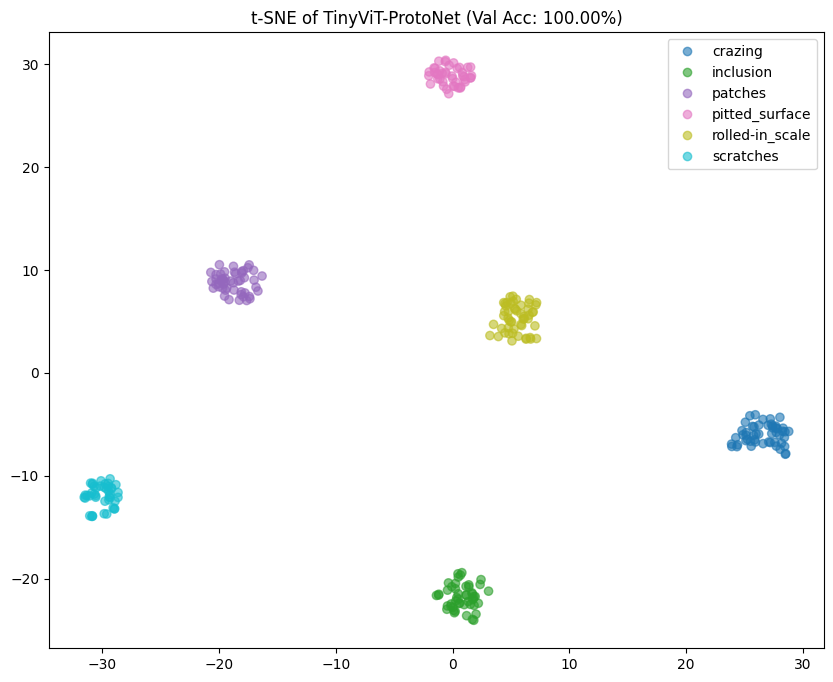


 Classification Report:
                 precision    recall  f1-score   support

        crazing       1.00      1.00      1.00        52
      inclusion       1.00      1.00      1.00        49
        patches       1.00      1.00      1.00        49
 pitted_surface       1.00      1.00      1.00        43
rolled-in_scale       1.00      1.00      1.00        52
      scratches       1.00      1.00      1.00        43

       accuracy                           1.00       288
      macro avg       1.00      1.00      1.00       288
   weighted avg       1.00      1.00      1.00       288



In [1]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Sampler, Dataset
from torchvision import datasets, transforms
from torch.amp import autocast, GradScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import timm
import gc

# ==========================================
# 1. Configuration
# ==========================================
CONFIG = {
    'data_dir': '/kaggle/input/neu-surface-defect-database/NEU-DET', # Check your path!
    'image_size': 224,
    'n_way': 6,          # NEU-DET has 6 classes, use all 6 for "Global" validation
    'n_support': 5,      # Increased support shots for stability
    'n_query': 10,       # More query images per episode
    'episodes_train': 100,
    'epochs': 50,        # INCREASED from 20 to 50
    'learning_rate': 5e-5, # Lower LR for stability
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

# ==========================================
# 2. Data Loading (Episodic for Train, Standard for Val)
# ==========================================
class EpisodicSampler(Sampler):
    def __init__(self, dataset, n_way, n_support, n_query, episodes):
        self.dataset = dataset
        self.n_way = n_way
        self.n_support = n_support
        self.n_query = n_query
        self.episodes = episodes
        self.indices_by_class = {}
        
        # Robust label extraction
        targets = dataset.targets if hasattr(dataset, 'targets') else [y for _, y in dataset.samples]
        for idx, label in enumerate(targets):
            if label not in self.indices_by_class: self.indices_by_class[label] = []
            self.indices_by_class[label].append(idx)
            
    def __iter__(self):
        for _ in range(self.episodes):
            batch = []
            available_classes = list(self.indices_by_class.keys())
            # Ensure we don't request more ways than exist
            actual_n_way = min(len(available_classes), self.n_way)
            selected_classes = random.sample(available_classes, actual_n_way)
            
            for cls in selected_classes:
                indices = self.indices_by_class[cls]
                n_total = self.n_support + self.n_query
                replace = len(indices) < n_total
                selected_indices = np.random.choice(indices, n_total, replace=replace)
                batch.extend(selected_indices)
            yield batch

    def __len__(self):
        return self.episodes

def get_dataloaders():
    transform = transforms.Compose([
        transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    
    # Load FULL dataset
    full_dataset = datasets.ImageFolder(root=os.path.join(CONFIG['data_dir'], 'train/images'), transform=transform)
    class_names = full_dataset.classes
    
    # Split Train/Val (80/20)
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

    # Samplers
    train_sampler = EpisodicSampler(full_dataset, CONFIG['n_way'], CONFIG['n_support'], CONFIG['n_query'], CONFIG['episodes_train'])
    
    # Train Loader (Episodic)
    train_loader = DataLoader(full_dataset, batch_sampler=train_sampler, num_workers=2)
    
    # Val Loader (STANDARD - Batch based, NOT episodic, for t-SNE)
    val_loader_standard = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

    return train_loader, val_loader_standard, class_names, full_dataset

# ==========================================
# 3. Model: Hybrid ViT-ProtoNet
# ==========================================
class TinyViTProtoNet(nn.Module):
    def __init__(self):
        super(TinyViTProtoNet, self).__init__()
        self.backbone = timm.create_model('vit_tiny_patch16_224', pretrained=True, num_classes=0)
        self.embed_dim = 192 
        
        # Projection Head (Crucial for stability)
        self.projection = nn.Sequential(
            nn.Linear(self.embed_dim, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Linear(128, 64) # Metric space
        )
            
    def forward(self, x):
        features = self.backbone(x)
        return self.projection(features)

# ==========================================
# 4. Training Engine
# ==========================================
def euclidean_dist(x, y):
    n = x.size(0); m = y.size(0); d = x.size(1)
    if d != y.size(1): raise Exception
    x = x.unsqueeze(1).expand(n, m, d)
    y = y.unsqueeze(0).expand(n, m, d)
    return torch.pow(x - y, 2).sum(2)

def train_one_epoch(model, loader, optimizer, scaler, device):
    model.train()
    total_loss = 0
    
    for data, _ in loader: # Labels ignored in episodic loader (implicit in structure)
        data = data.to(device)
        optimizer.zero_grad()
        
        # Reshape: [Ways, Shot+Query, C, H, W]
        # Note: If batch size varies (last batch), this might fail, but episodic sampler is fixed size.
        n_way = CONFIG['n_way']
        n_support = CONFIG['n_support']
        n_query = CONFIG['n_query']
        
        p = n_support + n_query
        data = data.view(n_way, p, 3, 224, 224)
        
        support = data[:, :n_support].contiguous().view(-1, 3, 224, 224)
        query = data[:, n_support:].contiguous().view(-1, 3, 224, 224)
        
        with autocast('cuda'):
            z_support = model(support).view(n_way, n_support, -1)
            prototypes = z_support.mean(dim=1)
            z_query = model(query) # [N_query_total, Dim]
            
            dists = euclidean_dist(z_query, prototypes)
            
            # Target indices (0,0,0... 1,1,1... )
            target_inds = torch.arange(0, n_way).view(n_way, 1, 1).expand(n_way, n_query, 1).long()
            target_inds = target_inds.to(device).view(-1)
            
            log_p_y = torch.log_softmax(-dists, dim=1)
            loss = -log_p_y.gather(1, target_inds.view(-1, 1)).squeeze().view(-1).mean()
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
        
    return total_loss / len(loader)

# ==========================================
# 5. Validation & t-SNE Logic
# ==========================================
def validate_standard(model, loader, device, class_names):
    """
    Runs standard inference to get embeddings for t-SNE 
    and computes Nearest Centroid Accuracy.
    """
    model.eval()
    all_embs = []
    all_labels = []
    
    # 1. Extract Embeddings
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            emb = model(x)
            all_embs.append(emb.cpu())
            all_labels.append(y)
            
    all_embs = torch.cat(all_embs)
    all_labels = torch.cat(all_labels)
    
    # 2. Compute Prototypes (Centroids) from Validation Data itself (Approximation)
    # Ideally, you use a 'Support Set', but for t-SNE viz, we just want to see clusters.
    unique_labels = torch.unique(all_labels)
    prototypes = []
    for lbl in unique_labels:
        mask = all_labels == lbl
        prototypes.append(all_embs[mask].mean(0))
    prototypes = torch.stack(prototypes)
    
    # 3. Compute Accuracy (Nearest Centroid)
    dists = euclidean_dist(all_embs, prototypes)
    preds = torch.argmin(dists, dim=1)
    acc = (preds == all_labels).float().mean().item()
    
    return acc, all_embs, all_labels, preds

# ==========================================
# 6. Main Run
# ==========================================
train_loader, val_loader, class_names, _ = get_dataloaders()
model = TinyViTProtoNet().to(CONFIG['device'])
optimizer = optim.AdamW(model.parameters(), lr=CONFIG['learning_rate'])
scaler = GradScaler('cuda')
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG['epochs'])

history = {'loss': [], 'acc': []}

print(" Starting Training...")
for epoch in range(CONFIG['epochs']):
    loss = train_one_epoch(model, train_loader, optimizer, scaler, CONFIG['device'])
    acc, _, _, _ = validate_standard(model, val_loader, CONFIG['device'], class_names)
    
    history['loss'].append(loss)
    history['acc'].append(acc)
    scheduler.step()
    
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}/{CONFIG['epochs']} | Loss: {loss:.4f} | Val Acc: {acc:.4f}")

# Final Analysis
acc, embs, labels, preds = validate_standard(model, val_loader, CONFIG['device'], class_names)

# Plot t-SNE
print("\n Generating t-SNE...")
tsne = TSNE(n_components=2, perplexity=30, init='pca', learning_rate='auto')
embs_2d = tsne.fit_transform(embs.numpy())

plt.figure(figsize=(10, 8))
scatter = plt.scatter(embs_2d[:, 0], embs_2d[:, 1], c=labels.numpy(), cmap='tab10', alpha=0.6)
plt.legend(handles=scatter.legend_elements()[0], labels=class_names)
plt.title(f"t-SNE of TinyViT-ProtoNet (Val Acc: {acc:.2%})")
plt.show()

# Classification Report
print("\n Classification Report:")
print(classification_report(labels.numpy(), preds.numpy(), target_names=class_names))

⚠️ Skipped 1 images due to missing XML annotations.
Starting Training...
Epoch 1/15 | Loss: 0.5379
Epoch 2/15 | Loss: 0.3893
Epoch 3/15 | Loss: 0.3331
Epoch 4/15 | Loss: 0.3004
Epoch 5/15 | Loss: 0.2748
Epoch 6/15 | Loss: 0.2512
Epoch 7/15 | Loss: 0.2322
Epoch 8/15 | Loss: 0.2099
Epoch 9/15 | Loss: 0.1945
Epoch 10/15 | Loss: 0.1815
Epoch 11/15 | Loss: 0.1660
Epoch 12/15 | Loss: 0.1534
Epoch 13/15 | Loss: 0.1433
Epoch 14/15 | Loss: 0.1341
Epoch 15/15 | Loss: 0.1284
Model saved to neu_faster_rcnn.pth


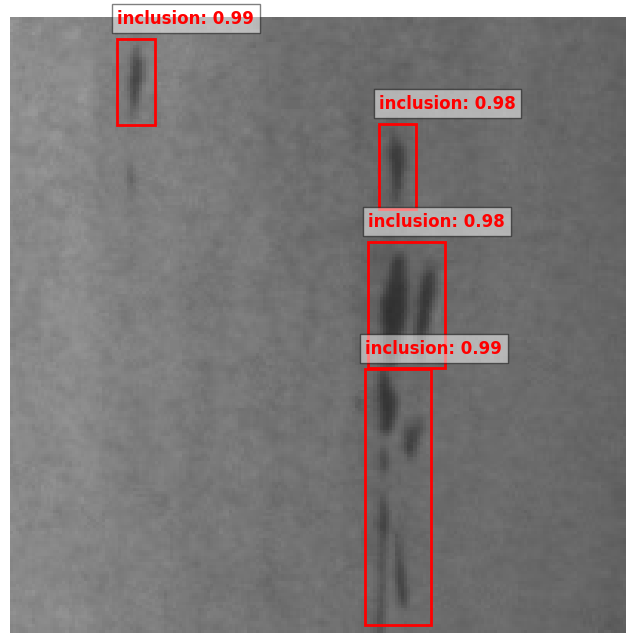

In [4]:
import os
import xml.etree.ElementTree as ET
import torch
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision import tv_tensors
from torchvision.transforms import v2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from pathlib import Path

# ==========================================
# 1. Configuration
# ==========================================
CONFIG = {
    'img_dir': '/kaggle/input/neu-surface-defect-database/NEU-DET/train/images',
    'annot_dir': '/kaggle/input/neu-surface-defect-database/NEU-DET/train/annotations',
    'num_classes': 7, # 6 defect classes + 1 background (CRITICAL for Faster R-CNN)
    'batch_size': 4,
    'epochs': 15,
    'lr': 0.001,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

CLASS_MAP = {
    'crazing': 1, 'inclusion': 2, 'patches': 3, 
    'pitted_surface': 4, 'rolled-in_scale': 5, 'scratches': 6
}
REV_CLASS_MAP = {v: k for k, v in CLASS_MAP.items()}

# ==========================================
# 2. Dataset & Transforms
# ==========================================
class NEUDetectionDataset(torch.utils.data.Dataset):
    def __init__(self, img_dir, annot_dir, transforms=None):
        self.img_dir = Path(img_dir)
        self.annot_dir = Path(annot_dir)
        self.transforms = transforms
        
        # 1. Find all .jpg files
        raw_img_paths = list(self.img_dir.rglob('*.jpg'))
        self.valid_data = []
        
        # 2. Pre-filter: Only keep images that have a corresponding XML file
        missing_count = 0
        for img_path in raw_img_paths:
            # Guess path 1: Same subfolder structure
            rel_path = img_path.relative_to(self.img_dir)
            annot_path = self.annot_dir / rel_path.with_suffix('.xml')
            
            # Guess path 2: Flat structure in the annotations folder
            if not annot_path.exists():
                annot_path = self.annot_dir / img_path.with_suffix('.xml').name
                
            # If we found it, save the pair. If not, skip it.
            if annot_path.exists():
                self.valid_data.append((img_path, annot_path))
            else:
                missing_count += 1
                
        if missing_count > 0:
            print(f"⚠️ Skipped {missing_count} images due to missing XML annotations.")

    def __len__(self):
        return len(self.valid_data)

    def __getitem__(self, idx):
        # Unpack our pre-verified paths
        img_path, annot_path = self.valid_data[idx]
        
        img = Image.open(img_path).convert("RGB")

        # Parse the XML
        tree = ET.parse(annot_path)
        root = tree.getroot()
        
        boxes = []
        labels = []
        
        for obj in root.findall('object'):
            label_name = obj.find('name').text
            labels.append(CLASS_MAP[label_name])
            
            bndbox = obj.find('bndbox')
            xmin = float(bndbox.find('xmin').text)
            ymin = float(bndbox.find('ymin').text)
            xmax = float(bndbox.find('xmax').text)
            ymax = float(bndbox.find('ymax').text)
            boxes.append([xmin, ymin, xmax, ymax])
            
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        
        # Format required by torchvision models
        target = {}
        target["boxes"] = tv_tensors.BoundingBoxes(boxes, format="XYXY", canvas_size=img.size[::-1])
        target["labels"] = labels
        target["image_id"] = torch.tensor([idx])

        img = tv_tensors.Image(img)

        if self.transforms is not None:
            img, target = self.transforms(img, target)

        return img, target

# We must use a custom collate_fn because images have different numbers of boxes
def collate_fn(batch):
    return tuple(zip(*batch))

def get_transform():
    # v2 transforms safely handle bounding box adjustments during image augmentation
    return v2.Compose([
        v2.ToDtype(torch.float32, scale=True),
        v2.SanitizeBoundingBoxes(),
    ])

# ==========================================
# 3. Model Setup
# ==========================================
def get_model(num_classes):
    # Load a pre-trained model
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn_v2(weights="DEFAULT")
    
    # Get the number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    
    # Replace the pre-trained head with a new one tailored to our dataset
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

# ==========================================
# 4. Training Engine
# ==========================================
def train():
    dataset = NEUDetectionDataset(CONFIG['img_dir'], CONFIG['annot_dir'], transforms=get_transform())
    data_loader = torch.utils.data.DataLoader(
        dataset, batch_size=CONFIG['batch_size'], shuffle=True, num_workers=2, collate_fn=collate_fn
    )

    model = get_model(CONFIG['num_classes']).to(CONFIG['device'])
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.SGD(params, lr=CONFIG['lr'], momentum=0.9, weight_decay=0.0005)

    model.train()
    print("Starting Training...")
    for epoch in range(CONFIG['epochs']):
        epoch_loss = 0
        for images, targets in data_loader:
            images = list(image.to(CONFIG['device']) for image in images)
            targets = [{k: v.to(CONFIG['device']) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

            optimizer.zero_grad()
            losses.backward()
            optimizer.step()
            
            epoch_loss += losses.item()
            
        print(f"Epoch {epoch+1}/{CONFIG['epochs']} | Loss: {epoch_loss/len(data_loader):.4f}")
    
    torch.save(model.state_dict(), "neu_faster_rcnn.pth")
    print("Model saved to neu_faster_rcnn.pth")
    return model

# ==========================================
# 5. Visualization / Inference
# ==========================================
def predict_and_show(model, image_path, threshold=0.5):
    model.eval()
    img = Image.open(image_path).convert("RGB")
    img_tensor = v2.functional.to_image(img)
    img_tensor = v2.functional.to_dtype(img_tensor, torch.float32, scale=True).to(CONFIG['device'])
    
    with torch.no_grad():
        prediction = model([img_tensor])[0]
    
    fig, ax = plt.subplots(1, figsize=(8, 8))
    ax.imshow(img)
    
    for i in range(len(prediction['boxes'])):
        score = prediction['scores'][i].item()
        if score > threshold:
            box = prediction['boxes'][i].cpu().numpy()
            label_idx = prediction['labels'][i].item()
            label_name = REV_CLASS_MAP.get(label_idx, "Unknown")
            
            xmin, ymin, xmax, ymax = box
            rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, 
                                     linewidth=2, edgecolor='r', facecolor='none')
            ax.add_patch(rect)
            ax.text(xmin, ymin - 5, f"{label_name}: {score:.2f}", color='red', 
                    fontsize=12, weight='bold', bbox=dict(facecolor='white', alpha=0.5))
            
    plt.axis('off')
    plt.show()

if __name__ == "__main__":
    # 1. Train the model
    trained_model = train()
    
    # 2. Test it on a single image (Safely grab the first actual .jpg file)
    all_img_paths = list(Path(CONFIG['img_dir']).rglob('*.jpg'))
    if len(all_img_paths) > 0:
        test_img = str(all_img_paths[0])
        predict_and_show(trained_model, test_img)
    else:
        print("No images found! Check your Kaggle directory paths.")

In [7]:
import cv2
import torch
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.transforms import v2
from PIL import Image
import numpy as np

# Same map from the training script
CLASS_MAP = {1: 'crazing', 2: 'inclusion', 3: 'patches', 4: 'pitted_surface', 5: 'rolled-in_scale', 6: 'scratches'}

def load_model(weights_path, num_classes=7, device='cuda'):
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn_v2(weights=None)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    model.load_state_dict(torch.load(weights_path, map_location=device))
    model.to(device)
    model.eval()
    return model

def process_video(video_path, output_path, model, device, threshold=0.5):
    cap = cv2.VideoCapture(video_path)
    
    # Get video properties for the writer
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    
    # Define codec and create VideoWriter
    fourcc = cv2.VideoWriter_fourcc(*'mp4v') 
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
    
    transform = v2.Compose([
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True)
    ])

    print("Processing video...")
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
            
        # Convert OpenCV BGR to RGB for PyTorch
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        
        # Prepare tensor
        img_tensor = transform(rgb_frame).to(device)
        
        # Predict
        with torch.no_grad():
            predictions = model([img_tensor])[0]
            
        # Draw boxes on the original BGR frame
        for i in range(len(predictions['boxes'])):
            score = predictions['scores'][i].item()
            if score > threshold:
                box = predictions['boxes'][i].cpu().numpy().astype(int)
                label_idx = predictions['labels'][i].item()
                label_name = CLASS_MAP.get(label_idx, "Unknown")
                
                xmin, ymin, xmax, ymax = box
                
                # Draw Rectangle (Green box)
                cv2.rectangle(frame, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)
                
                # Put Label
                label_text = f"{label_name} {score:.2f}"
                cv2.putText(frame, label_text, (xmin, ymin - 10), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
                
        out.write(frame)

    cap.release()
    out.release()
    print(f"Saved processed video to {output_path}")

if __name__ == "__main__":
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
    
    # Load your trained model
    model = load_model("neu_faster_rcnn.pth", device=DEVICE)
    
    # Run inference (Change paths to your actual video files)
    process_video(
        video_path="/kaggle/working/simulated_factory_feed.mp4", 
        output_path="output_detected.mp4", 
        model=model, 
        device=DEVICE,
        threshold=0.6 # Adjust this to filter out weak predictions
    )

Processing video...


KeyboardInterrupt: 

In [8]:
import cv2
import os
import numpy as np
import glob
from tqdm import tqdm

# --- CONFIGURATION ---
INPUT_ROOT = '/kaggle/input/neu-surface-defect-database/NEU-DET/train/images'
OUTPUT_VIDEO_PATH = 'quick_test_factory_feed.mp4'

# Video Settings
FPS = 30
FRAME_SIZE = (200, 200)
SCROLL_SPEED = 10  # Increased speed so it generates fewer frames for the test

def create_conveyor_video(class_name, limit_images=3): # Set to 3 for a quick test
    image_folder = os.path.join(INPUT_ROOT, class_name)
    image_files = sorted(glob.glob(os.path.join(image_folder, '*.jpg')))

    if not image_files:
        print(f"⚠️ No images found in {image_folder}. Check your path!")
        return []

    # Limit images for testing
    image_files = image_files[:limit_images]
    print(f"Processing {len(image_files)} images for class: {class_name}...")

    loaded_imgs = []
    for img_path in image_files:
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.resize(img, FRAME_SIZE)
            loaded_imgs.append(img)
    
    if len(loaded_imgs) < 2:
        print("Need at least 2 images to stitch a video together!")
        return []

    processed_frames = []
    for i in range(len(loaded_imgs) - 1):
        img_current = loaded_imgs[i]
        img_next = loaded_imgs[i+1]
        
        # Stitch horizontally
        combined_strip = np.hstack((img_current, img_next))
        
        # Slide the window
        for x in range(0, FRAME_SIZE[1], SCROLL_SPEED):
            frame = combined_strip[:, x:x+FRAME_SIZE[1]]
            processed_frames.append(frame)

    return processed_frames

# --- MAIN EXECUTION ---
fourcc = cv2.VideoWriter_fourcc(*'mp4v') 
out = cv2.VideoWriter(OUTPUT_VIDEO_PATH, fourcc, FPS, FRAME_SIZE)

# Just testing ONE class to make sure it works!
test_classes = ['crazing'] 

all_frames = []

for defect in test_classes:
    frames = create_conveyor_video(defect, limit_images=3) # Limit to 3 images
    all_frames.extend(frames)

print(f"Writing {len(all_frames)} frames to test video...")

for frame in tqdm(all_frames):
    out.write(frame)

out.release()
print(f"Done! Quick test video saved to {OUTPUT_VIDEO_PATH}")

Processing 3 images for class: crazing...
Writing 40 frames to test video...


100%|██████████| 40/40 [00:00<00:00, 2847.12it/s]

Done! Quick test video saved to quick_test_factory_feed.mp4


In [11]:
import cv2
import torch
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.transforms import v2
from PIL import Image
import numpy as np

# Same map from the training script
CLASS_MAP = {1: 'crazing', 2: 'inclusion', 3: 'patches', 4: 'pitted_surface', 5: 'rolled-in_scale', 6: 'scratches'}

def load_model(weights_path, num_classes=7, device='cuda'):
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn_v2(weights=None)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    model.load_state_dict(torch.load(weights_path, map_location=device))
    model.to(device)
    model.eval()
    return model

def process_video(video_path, output_path, model, device, threshold=0.5):
    cap = cv2.VideoCapture(video_path)
    
    # Get video properties for the writer
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    
    # Define codec and create VideoWriter
    fourcc = cv2.VideoWriter_fourcc(*'mp4v') 
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
    
    transform = v2.Compose([
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True)
    ])

    print("Processing video...")
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
            
        # Convert OpenCV BGR to RGB for PyTorch
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        
        # Prepare tensor
        img_tensor = transform(rgb_frame).to(device)
        
        # Predict
        with torch.no_grad():
            predictions = model([img_tensor])[0]
            
        # Draw boxes on the original BGR frame
        for i in range(len(predictions['boxes'])):
            score = predictions['scores'][i].item()
            if score > threshold:
                box = predictions['boxes'][i].cpu().numpy().astype(int)
                label_idx = predictions['labels'][i].item()
                label_name = CLASS_MAP.get(label_idx, "Unknown")
                
                xmin, ymin, xmax, ymax = box
                
                # Draw Rectangle (Green box)
                cv2.rectangle(frame, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)
                
                # Put Label
                label_text = f"{label_name} {score:.2f}"
                cv2.putText(frame, label_text, (xmin, ymin - 10), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
                
        out.write(frame)

    cap.release()
    out.release()
    print(f"Saved processed video to {output_path}")

if __name__ == "__main__":
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
    
    # Load your trained model
    model = load_model("neu_faster_rcnn.pth", device=DEVICE)
    
    # Run inference (Change paths to your actual video files)
    process_video(
        video_path="/kaggle/working/inclusion_slow_test.mp4", 
        output_path="output_detected.mp4", 
        model=model, 
        device=DEVICE,
        threshold=0.6 # Adjust this to filter out weak predictions
    )

Processing video...
Saved processed video to output_detected.mp4


In [10]:
import cv2
import os
import numpy as np
import glob
from tqdm import tqdm

# --- CONFIGURATION ---
INPUT_ROOT = '/kaggle/input/neu-surface-defect-database/NEU-DET/train/images'
OUTPUT_VIDEO_PATH = 'inclusion_slow_test.mp4'

# Video Settings
FPS = 30
FRAME_SIZE = (200, 200)
SCROLL_SPEED = 2  # Dropped from 10 to 2 for a much slower, smoother scroll

def create_conveyor_video(class_name, limit_images=3): 
    image_folder = os.path.join(INPUT_ROOT, class_name)
    image_files = sorted(glob.glob(os.path.join(image_folder, '*.jpg')))

    if not image_files:
        print(f"⚠️ No images found in {image_folder}. Check your path!")
        return []

    # Limit images for testing
    image_files = image_files[:limit_images]
    print(f"Processing {len(image_files)} images for class: {class_name}...")

    loaded_imgs = []
    for img_path in image_files:
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.resize(img, FRAME_SIZE)
            loaded_imgs.append(img)
    
    if len(loaded_imgs) < 2:
        print("Need at least 2 images to stitch a video together!")
        return []

    processed_frames = []
    for i in range(len(loaded_imgs) - 1):
        img_current = loaded_imgs[i]
        img_next = loaded_imgs[i+1]
        
        # Stitch horizontally side-by-side
        combined_strip = np.hstack((img_current, img_next))
        
        # Slide the camera window slowly across the stitched images
        for x in range(0, FRAME_SIZE[1], SCROLL_SPEED):
            frame = combined_strip[:, x:x+FRAME_SIZE[1]]
            processed_frames.append(frame)

    return processed_frames

# --- MAIN EXECUTION ---
fourcc = cv2.VideoWriter_fourcc(*'mp4v') 
out = cv2.VideoWriter(OUTPUT_VIDEO_PATH, fourcc, FPS, FRAME_SIZE)

# Testing just the inclusion class
test_classes = ['inclusion'] 

all_frames = []

for defect in test_classes:
    frames = create_conveyor_video(defect, limit_images=3) # Limit to 3 images
    all_frames.extend(frames)

print(f"Writing {len(all_frames)} frames to test video...")

for frame in tqdm(all_frames):
    out.write(frame)

out.release()
print(f"Done! Slow test video saved to {OUTPUT_VIDEO_PATH}")

Processing 3 images for class: inclusion...
Writing 200 frames to test video...


100%|██████████| 200/200 [00:00<00:00, 3536.23it/s]

Done! Slow test video saved to inclusion_slow_test.mp4
